In [4]:
import sys
import pickle
import copy
import os

import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

import networkx as nx
import pandas as pd
import numpy as np
import pypsa
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mplcolors
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
# import seaborn as sns
import matplotlib.lines as mlines
from sklearn.cluster import KMeans

import cartopy.crs as ccrs
import cartopy
import gzip


from tqdm.notebook import tqdm

%load_ext autoreload
%autoreload 2

root_path = '../' # This defaults to './', which should be the repository pathimport os
os.chdir(root_path)
sys.path.append(root_path)
from utils.visualization import get_actual_co2_level
from utils.config import path_to_pypsa_network_sclopf, path_to_cascade_results_sclopf, path_to_vis_results_sclopf, path_to_pre_outage_sclopf, path_to_evaluation_results_sclopf, path_to_figures_sclopf, path_to_sclopf_results
from utils import data_handling, cascade_simulation
from utils.config import path_to_indicator_vectors_sclopf
from utils.clustering_visualisation import truncate_colormap
from utils.alternative_split_indicator_vectors import get_indicator_vector_snapshot_weightings

n_nodes = 600

save_path = path_to_figures_sclopf
os.makedirs(save_path, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# todo:
- replace all hard coded co2 lvls with the actual lvls

# Setup

In [5]:
# Load network graph and node positions
# (it is equal for all CO2 levels)
snet_index = 0
network = data_handling.load_pypsa_network_from_path(path_to_pypsa_network_sclopf +
                        f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L0.1-2920SEG.nc", True)
nx_graph = data_handling.build_networkx_graph(network, snet_index= snet_index)
pos = nx.get_node_attributes(nx_graph, 'pos')
I_m, B_d, num_parallels, line_limits = data_handling.get_matrices_from_nx_graph(nx_graph)
n_lines = nx_graph.number_of_edges()

# Determine number of simulations,
# i.e., total number of initial failures over the simulated period of one year
bridge_idxs = data_handling.nx_edges_to_matrix_indices(nx.bridges(nx_graph),
                                                           nx_graph)
n_2_failures = cascade_simulation.calc_possible_double_line_failures(num_parallels,
                                                                     ignored_idxs=bridge_idxs)
num_failures = len(n_2_failures)
num_failures_weighted = network.snapshot_weightings.objective.sum() * num_failures
n_snapshots = network.snapshots.shape[0]

/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.1-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.1-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [6]:
from utils.visualization import get_co2_levels

co2ls = get_co2_levels(n_nodes)
actual_co2ls = get_actual_co2_level(co2ls, n_nodes)
# actual_co2ls_vals = actual_co2ls_pd.values
# actual_co2ls = 
# selected_co2ls = np.array([0.1, 0.3, 0.6, 0.8])
selected_co2ls = np.array([0.0, 0.2, 0.6])
print(co2ls)

[0.  0.1 0.2 0.3 0.4 0.5 0.6]


In [7]:
networks = {co2l: data_handling.load_pypsa_network(n_nodes=600, co2lvl=co2l, use_sclopf=True) for co2l in co2ls}

/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.1-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.1-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.2-2920SEG.nc


...

INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.4-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.5-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.5-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [8]:
split_properties = pd.read_hdf(path_to_vis_results_sclopf + f"split_properties_all_n{n_nodes}.h5", index_col=0)

# check actual emission levels

In [9]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

import os

os.makedirs('pics', exist_ok=True)

import sys
# root_path = "../"#'/srv/data/jlange/PYPSA3/sclopf-iter' # This defaults to './', which should be the repository path

# sys.path.append(root_path)

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2


relax = 1.0 # Relaxation factor for the CO2 constraint
p_heurist = 0.7 # Heuristic for the maximum line loading
NCLUSTERS = 600
groupsize = 60
TEMP_RESOLUTION = 3 #H
load_shedding = True
n_subnetworks = int(np.ceil(8760 / TEMP_RESOLUTION / groupsize))




# Co2_scenarios = ['0.0','0.05', '0.1','0.2', '0.3', '0.4', '0.5', '0.6'] #, '0.2'


# networks_path = f"{root_path}/workflow/co2_rel_{relax}/s_max_pu_{p_heurist}/postnetworks/"




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.0.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


0.0 CO2 shadow price: -57233.236790417104


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.1.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


0.1 CO2 shadow price: -83.86538540916347


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.2.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


...

0.4 CO2 shadow price: -21.547134115186573


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.5.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


0.5 CO2 shadow price: -13.773908869154507


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.6.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


0.6 CO2 shadow price: -2.207414908126969


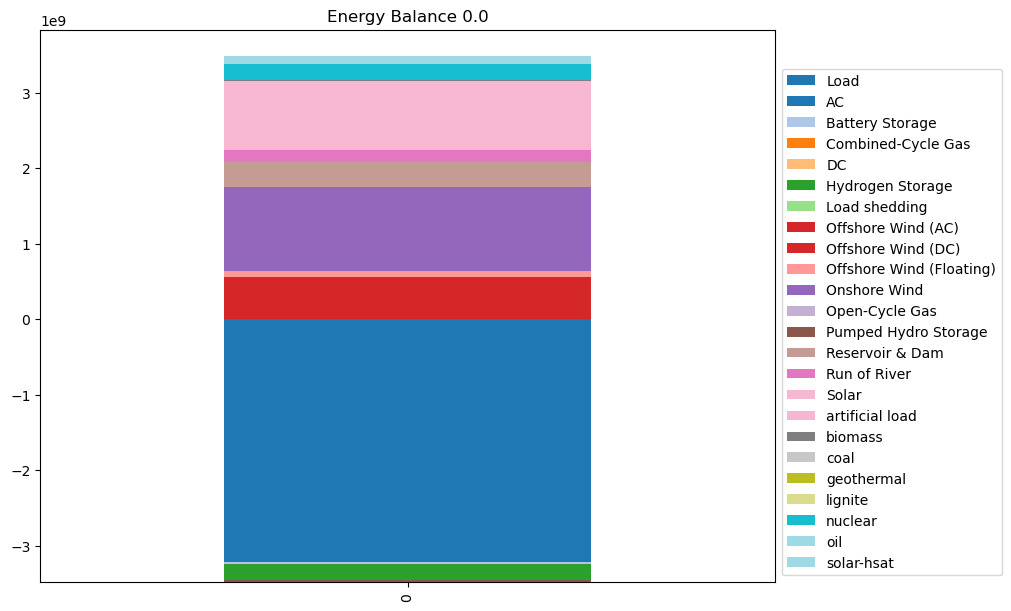

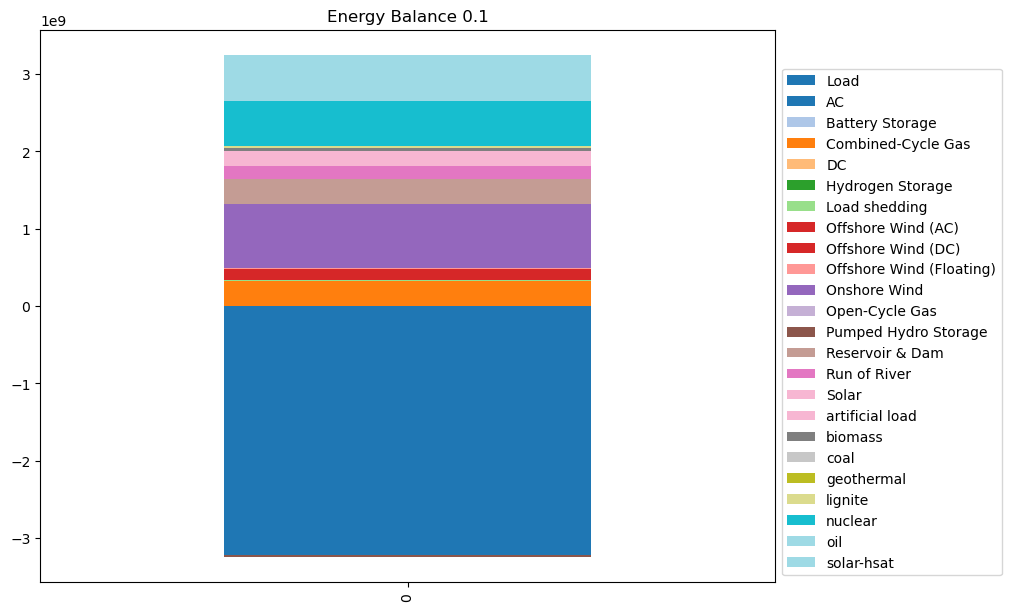

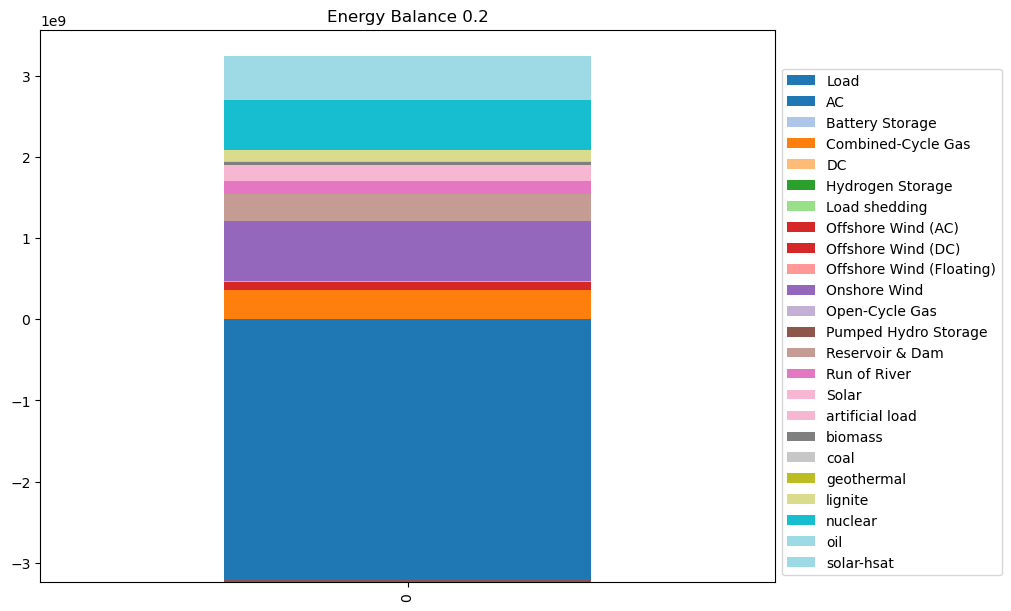

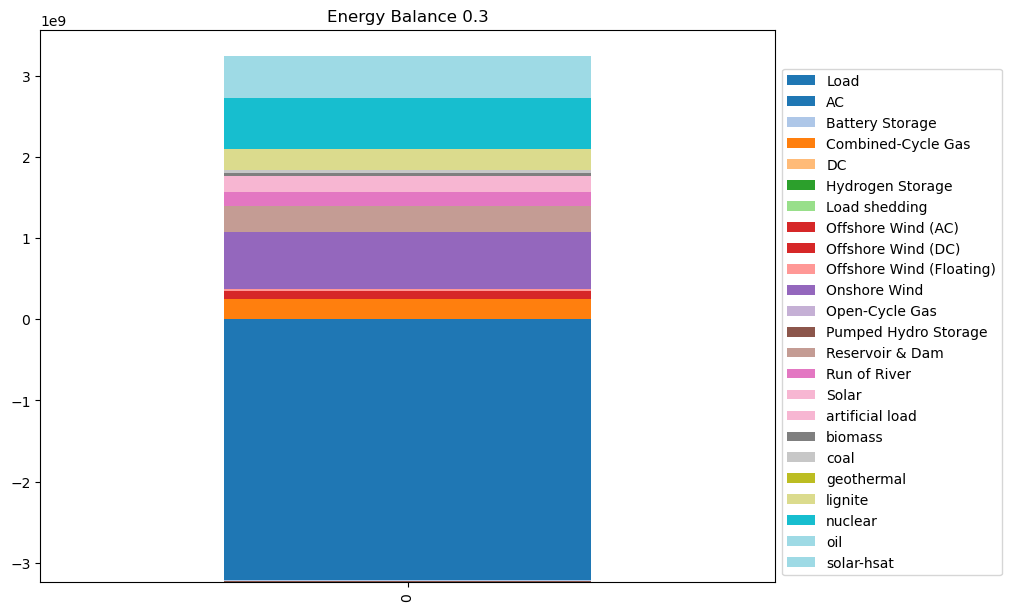

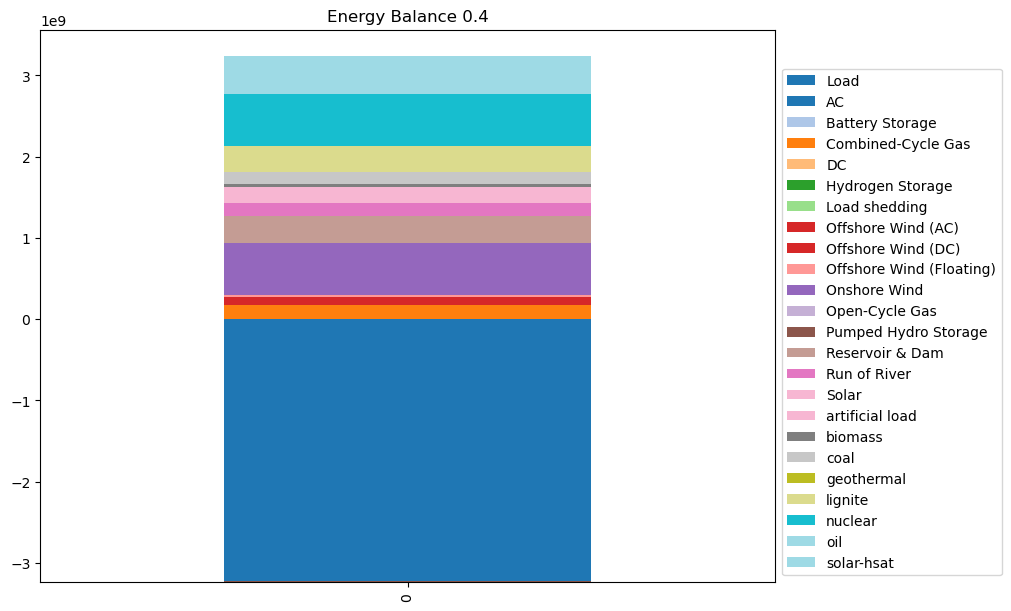

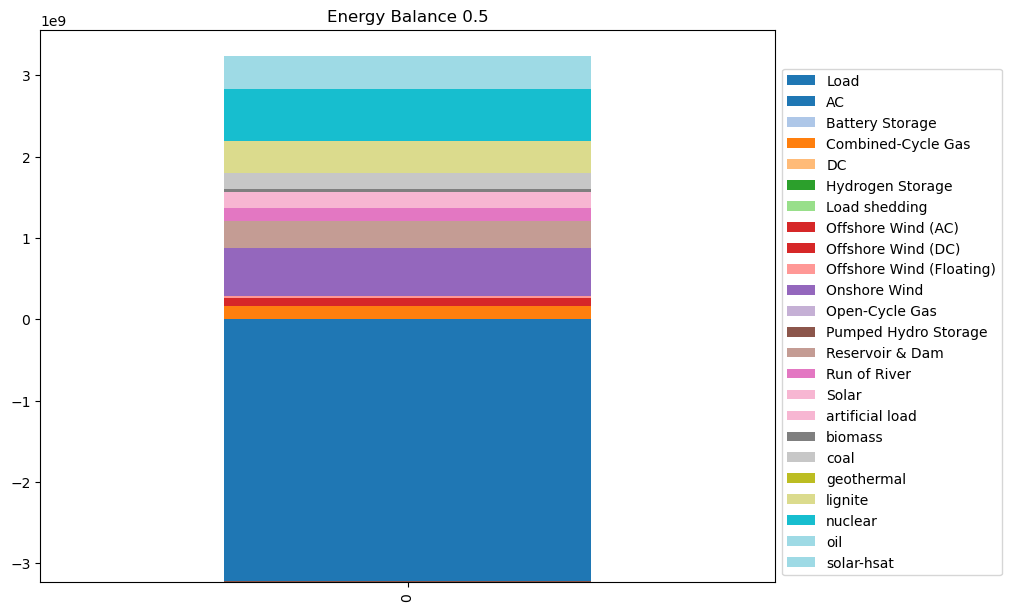

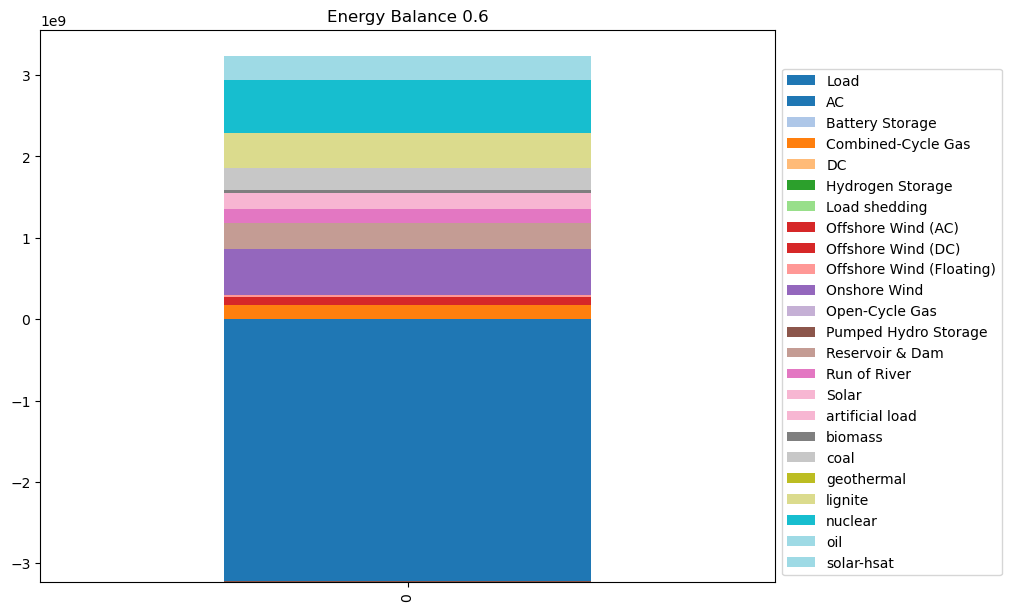

In [ ]:
root_path = '/srv/data/jlange/PYPSA3/sclopf-iter' # This defaults to './', which should be the repository path
networks_path = f"{root_path}/workflow/co2_rel_{relax}/s_max_pu_{p_heurist}/postnetworks/"

def get_emissions(n):

    gen = (
        n.generators_t.p
        .multiply(n.snapshot_weightings.objective,axis=0) # multiply by no. of hours (weight)
        .divide(n.generators.efficiency,axis=1).fillna(0) # efficiency and generation might be different (e.g. in the case of CCGT)
        .multiply(n.generators.carrier.map(n.carriers.co2_emissions)) # multiply by specific emissions
        .fillna(0).sum().sum()
    )

    stog = (
        n.storage_units_t.p
        .multiply(n.snapshot_weightings.objective,axis=0)
        .divide(n.storage_units.efficiency_dispatch,axis=1).fillna(0)
        .multiply(n.storage_units.carrier.map(n.carriers.co2_emissions))
        .fillna(0).sum().sum()
    )

    return gen+stog


# os.makedirs('pics/lopf', exist_ok=True)
Co2_scenarios = co2ls
# Define the carriers
renewable_carriers = ["solar", "solar-hsat", "onwind", "offwind-ac", "offwind-dc", "offwind-float", "hydro"]
conventional_carriers = ["nuclear", "oil", "OCGT", "CCGT", "coal", "lignite", "geothermal", "biomass"]

# Combine them into a single list for the DataFrame columns
all_carriers = renewable_carriers + conventional_carriers#network.gener.index

generation_by_carrier_and_co2l = pd.DataFrame(None,index=all_carriers, columns= Co2_scenarios)

CO2_shadowprices = pd.Series(index = Co2_scenarios)
CO2_values = pd.Series(index = Co2_scenarios)
CO2_global = pd.Series(index = Co2_scenarios)
# emissions = pd.Dataframe(None,index = [0], columns = Co2_scenarios)

for Co2l in Co2_scenarios:

    network = pypsa.Network(f"{networks_path}/sclopf-elec_s_{NCLUSTERS}_ec_lv1.0_Co2L{Co2l}.nc") ## lopf network

    shadow_CO2 = network.global_constraints["mu"]["CO2Limit"]
    CO2_global[Co2l] = network.global_constraints["constant"]["CO2Limit"]

    CO2_shadowprices[Co2l] = shadow_CO2
    CO2_values[Co2l] = get_emissions(network)

    print(f"{Co2l} CO2 shadow price: {shadow_CO2}")


    df = network.generators_t.p.sum(axis=0)
    
    # remove carrier id
    df.index = df.index.str[6:]
    # aggregate same carrier types
    df = df.groupby(df.index).sum()


    for carrier in df.index:
        
        # print(f"{carrier} {df[carrier]}")
        generation_by_carrier_and_co2l.loc[carrier, Co2l] = df[carrier]
        # generation_by_carrier_and_co2l.loc[carrier, "co2_emissions"] = network.carriers.co2_emissions[carrier]#df[carrier]
        
    
    # plot energy balance with inbuilt energy_balance method
    
    # number of different carriers
    num_bars = len(network.statistics.energy_balance().loc[:, :, "AC"].groupby(
        "carrier"
    ).sum())
    
    # colors
    cmap = matplotlib.colormaps.get_cmap('tab20')
    colors = cmap(np.linspace(0, 1, num_bars))
    
    # plot
    fig, ax = plt.subplots(figsize=(10, 6),layout = "constrained")
    # tmp.rename({"-":"Load"},inplace=True)
    # data in plot
    # energy_balance_data = 
    network.statistics.energy_balance().loc[:, :, "AC"].groupby(
        "carrier"
    ).sum().rename({"-":"Load"}).to_frame().T.plot.bar(stacked=True, ax=ax, color=colors, title=f"Energy Balance {Co2l}")
    
    
    ax.legend(bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)
    # fig.savefig(f"pics/lopf/Energymix_lopf_{Co2l}-{NCLUSTERS}.pdf")
    plt.close()



/tmp/ipykernel_1130603/3216935491.py:35: RuntimeWarning: invalid value encountered in scalar divide
  print(f"{Co2l}: Actual CO2lvl: {emission_by_co2l.values[cx]/CO2_global.values[cx]*float(Co2l)*100}")


0.0: Actual CO2lvl: nan
0.1: Actual CO2lvl: 9.999999438201817
0.2: Actual CO2lvl: 19.9999998529227
0.3: Actual CO2lvl: 29.999999871097938
0.4: Actual CO2lvl: 39.99999633641084
0.5: Actual CO2lvl: 49.72078593127439
0.6: Actual CO2lvl: 58.05898746668168


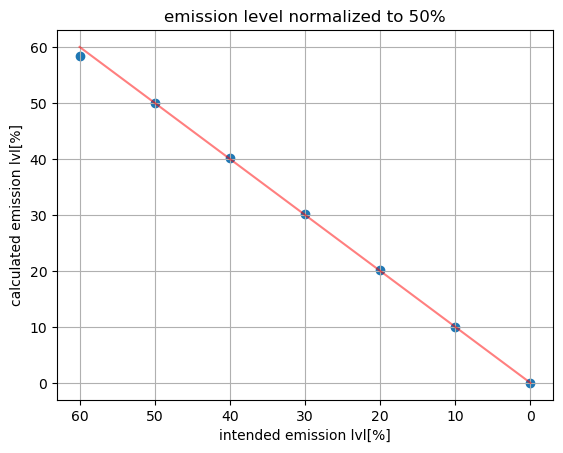

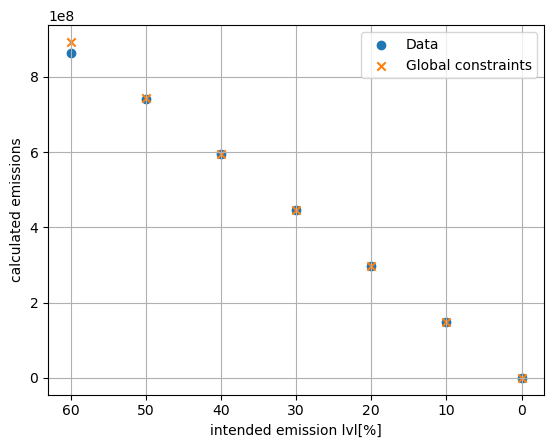

In [ ]:
# generation_fossil = generation_by_carrier_and_co2l.loc[["coal", "lignite", "CCGT", "OCGT"]].sum(axis=0)
# fossil_percentage = generation_fossil.div(generation_by_carrier_and_co2l.sum(axis=0) - generation_fossil)*100

# emission_by_carrier_by_co2l = generation_by_carrier_and_co2l.mul(network.carriers.co2_emissions, axis="index")
# emission_by_carrier_by_co2l.dropna(axis=0, thresh=1, inplace=True)
emission_by_co2l = CO2_values#emission_by_carrier_by_co2l.sum(axis=0)
emission_by_co2l_perc = emission_by_co2l/emission_by_co2l[0.5]*50

x_values = np.array(emission_by_co2l_perc.index, dtype=float)*100

# plot red line
plt.plot([60,0],[60,0], color = "r", alpha = 0.5)

plt.scatter(x_values, emission_by_co2l_perc.values)

plt.gca().invert_xaxis()
plt.grid()
plt.title("emission level normalized to 50%")
plt.xlabel("intended emission lvl[%]")
plt.ylabel("calculated emission lvl[%]")

plt.figure()
plt.scatter(x_values, emission_by_co2l.values,label = "Data")
plt.scatter(x_values, CO2_global.values,label = "Global constraints",marker = "x")

plt.legend()
plt.gca().invert_xaxis()
plt.grid()
plt.xlabel("intended emission lvl[%]")
plt.ylabel("calculated emissions")
# plt.savefig(f"pics/lopf/emissions.pdf")


for cx,Co2l in enumerate(Co2_scenarios):
    print(f"{Co2l}: Actual CO2lvl: {emission_by_co2l.values[cx]/CO2_global.values[cx]*float(Co2l)*100}")
    


In [30]:
actual_co2ls = {Co2l: emission_by_co2l.values[cx]/(CO2_global.values[cx]+10**-10)*float(Co2l) for cx,Co2l in enumerate(Co2_scenarios)}

actual_co2ls = pd.DataFrame.from_dict(actual_co2ls, orient='index', columns=["actual_co2_levels"])
actual_co2ls.sort_index(inplace=True)
actual_co2ls.index.name = "co2_level"
actual_co2ls.to_csv(path_to_sclopf_results + "actual_co2_levels.csv")

# Figure 2: generation map

## SCLOPF

/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/home/mtitz/.conda/envs/system_split/lib/python3.11/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/mtitz/.conda/envs/system_split/lib/python3.11/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


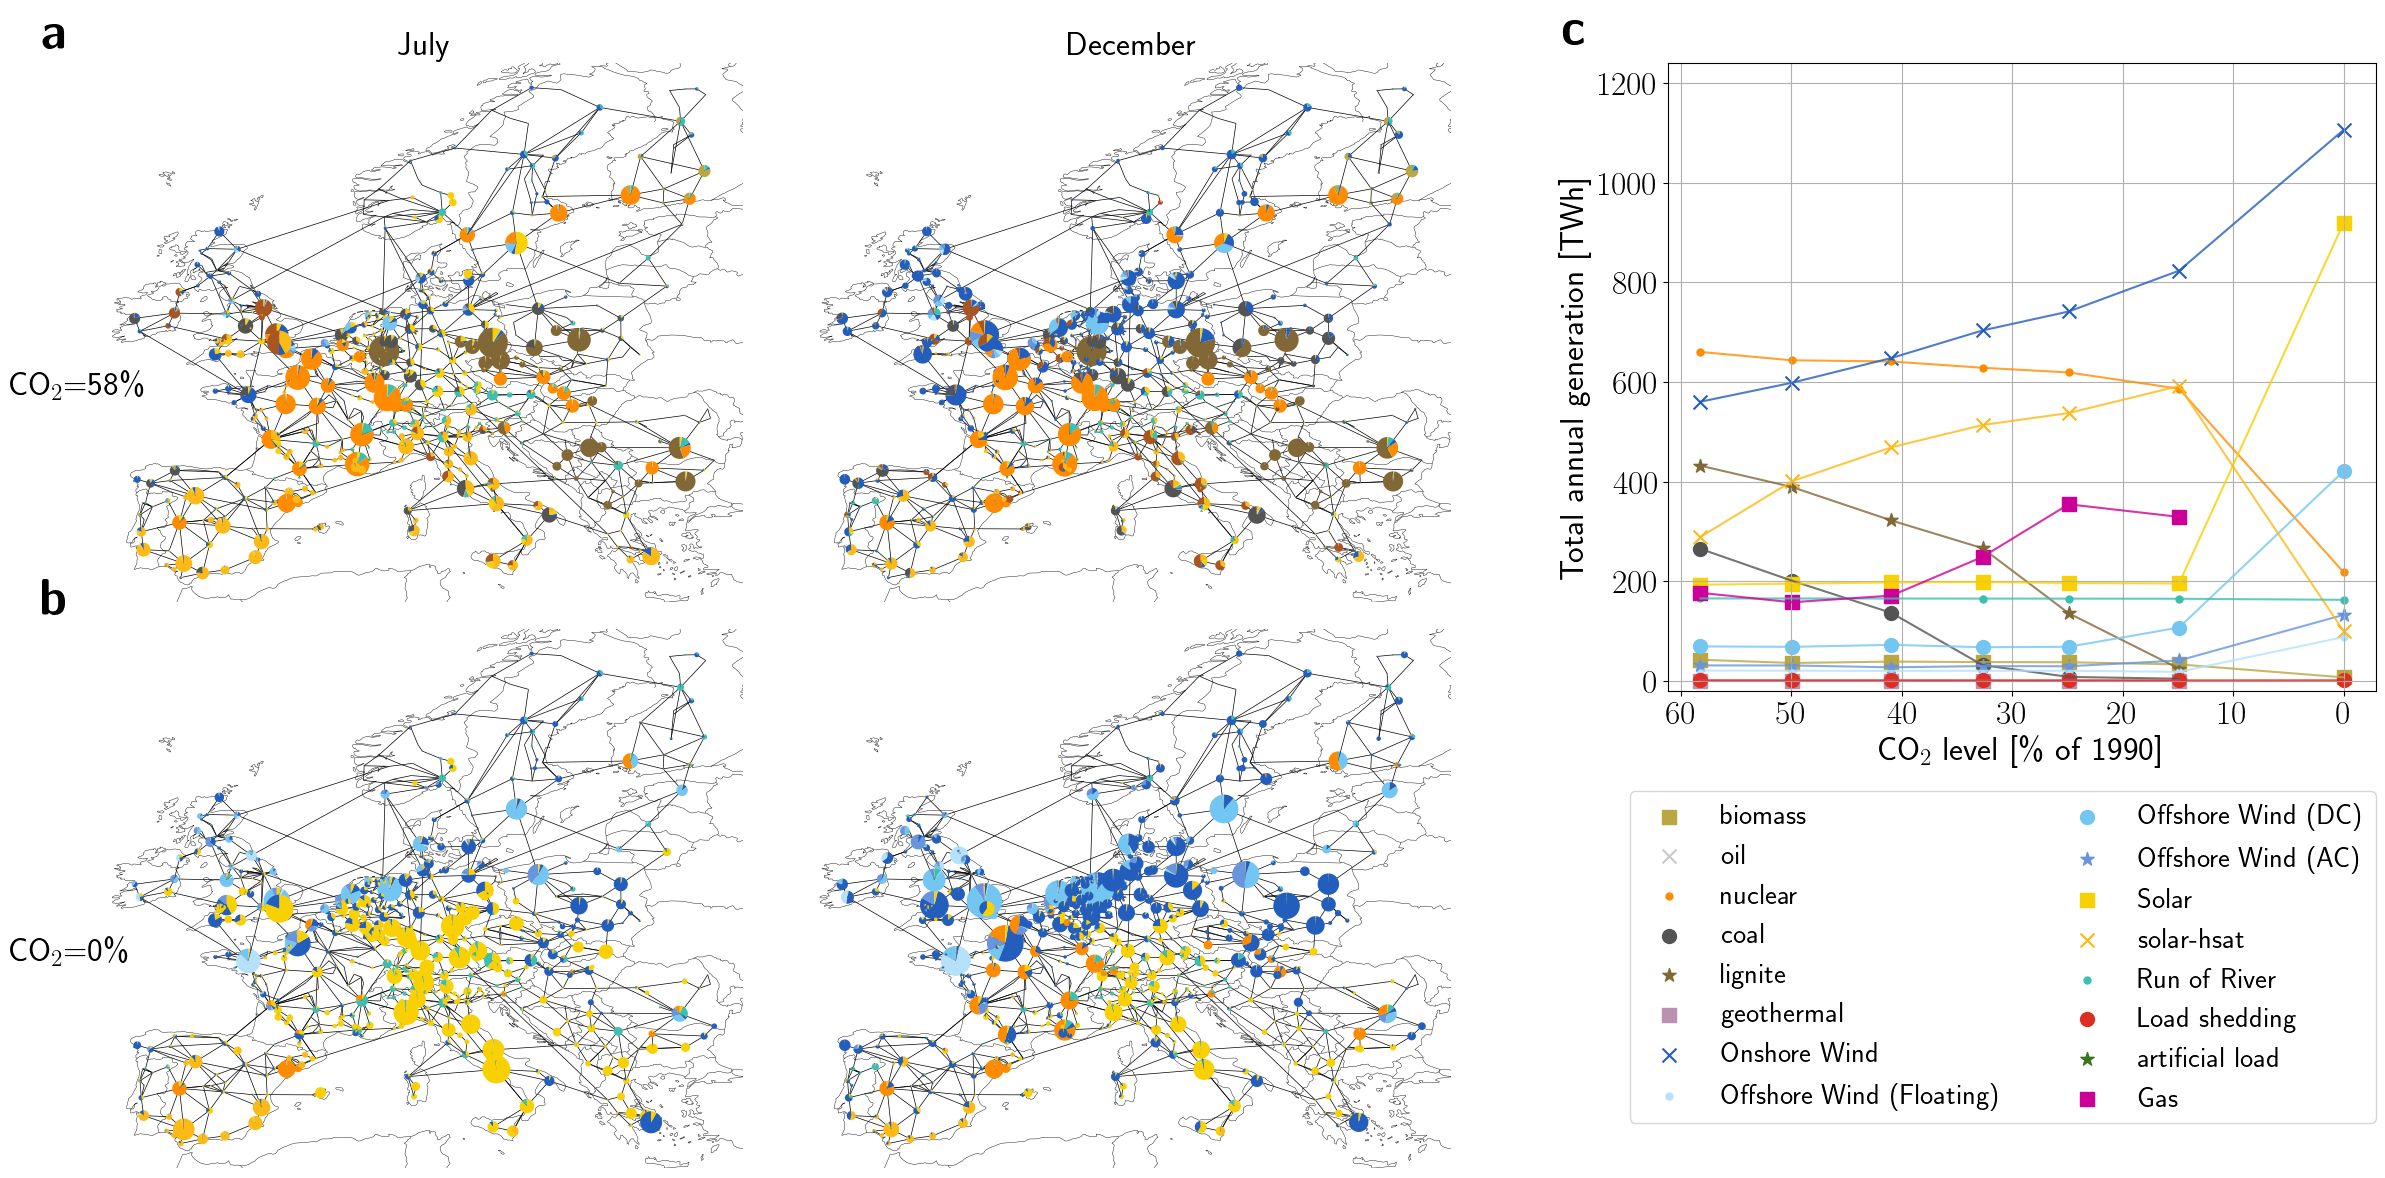

In [ ]:
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

target_levels = [0.6, 0.0]

f = plt.figure(figsize=(24, 12))
# gs = GridSpec(2, 3, figure=f)
# ax1 = [f.add_subplot(gs[0, i], projection=ccrs.PlateCarree())
#        for i in range(2)]
# ax2 = [f.add_subplot(gs[1, i], projection=ccrs.PlateCarree())
#        for i in range(2)]
# axs_clust = [ax1, ax2]
# ax3 = f.add_subplot(gs[0, 2])
outer = GridSpec(1, 2, width_ratios = [2, 1]) 
# gs = GridSpec(2, 3, figure=f)
gs_left = GridSpecFromSubplotSpec(2, 2, subplot_spec = outer[0], wspace=-0.0, hspace=0.05)
gs_right = GridSpecFromSubplotSpec(2, 1, subplot_spec = outer[1], height_ratios=[1, 0.6])

ax1 = [f.add_subplot(gs_left[0, i], projection=ccrs.PlateCarree())
       for i in range(2)]
ax2 = [f.add_subplot(gs_left[1, i], projection=ccrs.PlateCarree())
       for i in range(2)]
axs_primary = [ax1, ax2]
ax3 = f.add_subplot(gs_right[0, 0])
ax3_legend = f.add_subplot(gs_right[1, 0])
# ax4 = f.add_subplot(outer[1, 1])
labels = [[r'\textbf{a}', r'', r'\textbf{c}'],
          [r'\textbf{b}', '', r'\textbf{d}', '', '']]

##### panal a and b #######

vmax = 3.2e2
months = [7, 12]

for i, target_level in enumerate(target_levels):
       # fpath = data_path + "European_networks_lopf/elec_s_800_ec_lv1.0_Co2L0.1-3H.nc"
       # n = data_handling.load_pypsa_network(fpath, False)
       
       # n = data_handling.load_pypsa_network(path_to_pypsa_network_sclopf +
       #                  f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc", True)
       n = networks[target_level]
       for j, month in enumerate(months):

              axs_primary[i][j].set_ylim([0, vmax])
              current_snapshots = n.snapshots[n.snapshots.month == month]
              current_gen = n.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").loc[current_snapshots].sum().mul(network.generators.sign)
              current_gen = current_gen.groupby([n.generators["bus"], n.generators["carrier"]]).sum()
              n.plot(bus_sizes=current_gen/7e6,
                     line_colors='black',
                     link_colors='black',
                     link_widths=0.5,
                     line_widths=0.5,
                     ax=axs_primary[i][j])

              if i == 0:
                     axs_primary[i][j].set_title(current_snapshots.month_name()[0], fontsize=24)

              axs_primary[i][j].text(0 - 0.1, 1+0.05,
                            labels[i][j],
                            fontsize=36,
                            weight='bold',
                            verticalalignment='center',
                            transform=axs_primary[i][j].transAxes)


       axs_primary[i][0].text(0 - 0.15, 0.4,
                     rf'CO$_2$={get_actual_co2_level(target_level, percent=True)}\% ',
                     fontsize=24,
                     verticalalignment='center',
                     transform=axs_primary[i][0].transAxes)
    
    
import itertools
marker = itertools.cycle((',', 'x', '.', 'o', '*')) 

colors_gens = network.carriers.set_index('nice_name').color
colors_gens["Open-Cycle Gas"] = "#cc0099"
colors_gens["Gas"] = "#cc0099"

co2s = generation_by_carrier_and_co2l.columns.astype('float')
index = np.argsort(co2s)
jitter = iter(np.linspace(-1,1,generation_by_carrier_and_co2l.shape[0]))

generation_by_carrier_and_co2l = generation_by_carrier_and_co2l.rename(index=network.carriers.nice_name)
gas_gen = generation_by_carrier_and_co2l.loc["Combined-Cycle Gas"] + generation_by_carrier_and_co2l.loc["Open-Cycle Gas"]
generation_by_carrier_and_co2l_plot = generation_by_carrier_and_co2l.copy()
# generation_by_carrier_and_co2l_plot.index = generation_by_carrier_and_co2l_plot.index.str.apply(lambda x: x.upper())


for col in generation_by_carrier_and_co2l_plot.index:
    if "Gas" in col:
        generation_by_carrier_and_co2l_plot.drop(col, axis=0, inplace=True)
generation_by_carrier_and_co2l_plot = generation_by_carrier_and_co2l_plot.rename(index=network.carriers.nice_name)
# generation_by_carrier_and_co2l_plot.drop("Oil", axis=0, inplace=True)
generation_by_carrier_and_co2l_plot.loc["Gas"] = gas_gen 
for ind,data in generation_by_carrier_and_co2l_plot.iterrows():
    # jit = next(jitter)
    jit = 0
    plot_inds = (data.values)[index]>0
    # print(plot_inds.sum())
    ax3.scatter((get_actual_co2_level(co2s[index])*100 + jit)[plot_inds],
                ((data.values)[index]*1e-6)[plot_inds],
                color=colors_gens.loc[ind],
                label=ind,
                s=100,
                marker= next(marker)
                )

    ax3.plot((get_actual_co2_level(co2s[index])*100 + jit)[plot_inds],
             ((data.values)[index]*1e-6)[plot_inds],
             color=colors_gens.loc[ind],
             alpha=0.8)
# plt.gca().set_yscale("log")
# ax3.scatter([], [], label=r"Oil$\textless 0.6$", marker="")


ax3.invert_xaxis()
ax3.tick_params(axis='both', which='both', labelsize=24)
ax3.set_xlabel(r'$\text{CO}_2$ level [\% of 1990]',  fontsize=24)
ax3.set_ylabel(r'Total annual generation [TWh]', fontsize=24)

ax3.grid(True)
ax3.yaxis.offsetText.set_fontsize(24)
ax3.text(0 - 0.15, 1+0.05,
         labels[0][2],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax3.transAxes)
# ax3.plot([746/1251*100, 746/1251*100],[-2e1,1000], '--', lw=4, c='r', zorder=-1000) # TODO: Insert CO2 limit that corresponds to todays amount
# co2 emissions from https://www.umweltbundesamt.de/daten/klima/treibhausgas-emissionen-in-deutschland#emissionsentwicklung
# ax3.text(50,12e2*0.9, r'\textbf{2022`s emissions}', fontsize=24, color='r')
# ax3.text(746/1251*100,1050, r'\textbf{2022`s emissions}', fontsize=24, color='r', horizontalalignment='left')
ax3.set_ylim([-2e1,12.4e2])
# ax3.set_yscale('log')

# f.subplots_adjust(hspace=0.05, wspace=0.2)
h, l = ax3.get_legend_handles_labels()
ax3_legend.legend(h, l, borderaxespad=0, fontsize=20.5, ncol=2)
ax3_legend.axis("off")
# ax3.legend(fontsize=20.5, bbox_to_anchor=(1.02,0), ncol=2, loc="upper left")
# plt.tight_layout()
# ax3.legend(fontsize=20.5, ncol=2, columnspacing=0.5, handletextpad=0.1, borderpad=0.3)
plt.tight_layout()

plt.savefig(save_path+'generation_mix_versus_co2level.pdf', bbox_inches='tight')

In [ ]:
generation_by_carrier_and_co2l_plot/generation_by_carrier_and_co2l_plot.sum(axis=0)*100

### 200 Nodes

In [ ]:
generation_by_carrier_and_co2l = pd.DataFrame(index=network.carriers.index,
                                              columns=co2ls)
objectives = np.zeros(len(co2ls))
for i, level in enumerate(co2ls):
    network = data_handling.load_pypsa_network(path_to_pypsa_network_sclopf +
                        f"sclopf-elec_s_{200}_ec_lv1.0_Co2L{level}-2920SEG.nc", True)
    generation_by_carrier_and_co2l[level] = network.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").mul(network.generators.sign).T.groupby(
        network.generators["carrier"]).sum().sum(axis=1)
    objectives[i] = network.objective
generation_by_carrier_and_co2l.dropna(axis=0, inplace=True)

In [ ]:
generation_fossil = generation_by_carrier_and_co2l.loc[["coal", "lignite", "CCGT", "OCGT"]].sum(axis=0)
fossil_percentage = generation_fossil.div(generation_by_carrier_and_co2l.sum(axis=0) - generation_fossil)*100
# generation_fossil, fossil_percentage

emission_by_carrier_by_co2l = generation_by_carrier_and_co2l.mul(network.carriers.co2_emissions, axis="index")
emission_by_carrier_by_co2l.dropna(axis=0, thresh=1, inplace=True)
emission_by_co2l = emission_by_carrier_by_co2l.sum(axis=0)
emission_by_co2l_perc = emission_by_co2l/emission_by_co2l[0.6]*60

plt.scatter(emission_by_co2l_perc.index*100, emission_by_co2l_perc.values)
plt.gca().invert_xaxis()
plt.grid()
plt.title("emission level normalized to 60%")
plt.xlabel("intended emission lvl[%]")
plt.ylabel("calculated emission lvl[%]")

plt.figure()
plt.scatter(emission_by_co2l.index*100, emission_by_co2l.values)
plt.gca().invert_xaxis()
plt.grid()
plt.xlabel("intended emission lvl[%]")
plt.ylabel("calculated emissions")

## lopf

In [ ]:
from utils.config import data_path

generation_by_carrier_and_co2l = pd.DataFrame(index=network.carriers.index,
                                              columns=co2ls)
objectives = np.zeros(len(co2ls))
for i, level in enumerate(co2ls):
    fpath = data_path + f"European_networks_lopf/elec_s_800_ec_lv1.0_Co2L{level}-3H.nc"
    network = data_handling.load_pypsa_network(fpath, False)
    # network = data_handling.load_pypsa_network(path_to_pypsa_network_sclopf +
    #                     f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{level}-2920SEG.nc", True)
    generation_by_carrier_and_co2l[level] = network.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").mul(network.generators.sign).T.groupby(
        network.generators["carrier"]).sum().sum(axis=1)
    objectives[i] = network.objective
generation_by_carrier_and_co2l.dropna(axis=0, inplace=True)

In [ ]:
generation_fossil = generation_by_carrier_and_co2l.loc[["coal", "lignite", "CCGT", "OCGT"]].sum(axis=0)
fossil_percentage = generation_fossil.div(generation_by_carrier_and_co2l.sum(axis=0) - generation_fossil)*100
# generation_fossil, fossil_percentage

emission_by_carrier_by_co2l = generation_by_carrier_and_co2l.mul(network.carriers.co2_emissions, axis="index")
emission_by_carrier_by_co2l.dropna(axis=0, thresh=1, inplace=True)
emission_by_co2l = emission_by_carrier_by_co2l.sum(axis=0)
emission_by_co2l_perc = emission_by_co2l/emission_by_co2l[0.6]*60

plt.scatter(emission_by_co2l_perc.index*100, emission_by_co2l_perc.values)
plt.gca().invert_xaxis()
plt.grid()actual_co2ls
plt.title("emission level normalized to 60%")
plt.xlabel("intended emission lvl[%]")
plt.ylabel("calculated emission lvl[%]")

plt.figure()
plt.scatter(emission_by_co2l.index*100, emission_by_co2l.values)
plt.gca().invert_xaxis()
plt.grid()
plt.xlabel("intended emission lvl[%]")
plt.ylabel("calculated emissions")

In [ ]:
generation_fossil = generation_by_carrier_and_co2l.loc[["coal", "lignite", "CCGT", "OCGT"]].sum(axis=0)
fossil_percentage = generation_fossil.div(generation_by_carrier_and_co2l.sum(axis=0) - generation_fossil)*100
generation_fossil, fossil_percentage

In [ ]:
emission_by_carrier_by_co2l = generation_by_carrier_and_co2l.mul(network.carriers.co2_emissions, axis="index")
emission_by_carrier_by_co2l.dropna(axis=0, thresh=1, inplace=True)
emission_by_co2l = emission_by_carrier_by_co2l.sum(axis=0)
emission_by_co2l/emission_by_co2l[0.6]*60

In [ ]:
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

target_levels = [0.6, 0.0]

f = plt.figure(figsize=(24, 12))
# gs = GridSpec(2, 3, figure=f)
# ax1 = [f.add_subplot(gs[0, i], projection=ccrs.PlateCarree())
#        for i in range(2)]
# ax2 = [f.add_subplot(gs[1, i], projection=ccrs.PlateCarree())
#        for i in range(2)]
# axs_clust = [ax1, ax2]
# ax3 = f.add_subplot(gs[0, 2])
outer = GridSpec(1, 2, width_ratios = [2, 1]) 
# gs = GridSpec(2, 3, figure=f)
gs_left = GridSpecFromSubplotSpec(2, 2, subplot_spec = outer[0], wspace=-0.0, hspace=0.05)
gs_right = GridSpecFromSubplotSpec(2, 1, subplot_spec = outer[1], height_ratios=[1, 0.6])

ax1 = [f.add_subplot(gs_left[0, i], projection=ccrs.PlateCarree())
       for i in range(2)]
ax2 = [f.add_subplot(gs_left[1, i], projection=ccrs.PlateCarree())
       for i in range(2)]
axs_primary = [ax1, ax2]
ax3 = f.add_subplot(gs_right[0, 0])
ax3_legend = f.add_subplot(gs_right[1, 0])
# ax4 = f.add_subplot(outer[1, 1])
labels = [[r'\textbf{a}', r'', r'\textbf{c}'],
          [r'\textbf{b}', '', r'\textbf{d}', '', '']]

##### panal a and b #######

vmax = 3.2e2
months = [7, 12]

for i, target_level in enumerate(target_levels):
       fpath = data_path + f"European_networks_lopf/elec_s_800_ec_lv1.0_Co2L{target_level}-3H.nc"
       n = data_handling.load_pypsa_network(fpath, False)
       
       # n = data_handling.load_pypsa_network(path_to_pypsa_network_sclopf +
       #                  f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc", True)
       # n = data_handling.load_pypsa_network(target_level, n_nodes, path_to_pypsa_network_sclopf)
       for j, month in enumerate(months):

              axs_primary[i][j].set_ylim([0, vmax])
              current_snapshots = n.snapshots[n.snapshots.month == month]
              current_gen = n.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").loc[current_snapshots].sum().mul(network.generators.sign)
              current_gen = current_gen.groupby([n.generators["bus"], n.generators["carrier"]]).sum()
              n.plot(bus_sizes=current_gen/7e6,
                     line_colors='black',
                     link_colors='black',
                     link_widths=0.5,
                     line_widths=0.5,
                     ax=axs_primary[i][j])

              if i == 0:
                     axs_primary[i][j].set_title(current_snapshots.month_name()[0], fontsize=24)

              axs_primary[i][j].text(0 - 0.1, 1+0.05,
                            labels[i][j],
                            fontsize=36,
                            weight='bold',
                            verticalalignment='center',
                            transform=axs_primary[i][j].transAxes)


axs_primary[0][0].text(0 - 0.15, 0.4,
               r'CO$_2$=60\% ',
               fontsize=24,
               verticalalignment='center',
               transform=axs_primary[0][0].transAxes)
axs_primary[1][0].text(0 - 0.15, 0.4,
               r'CO$_2$= 0\%',
               fontsize=24,
               verticalalignment='center',
               transform=axs_primary[1][0].transAxes)

###### panel c ######

##### old
# co2s = generation_by_carrier_and_co2l.columns.astype('float')
# index = np.argsort(co2s)
# generation_by_carrier_and_co2l = generation_by_carrier_and_co2l.rename(index=network.carriers.nice_name)
# for ind,data in generation_by_carrier_and_co2l.iterrows():
#     ax3.scatter(co2s[index]*100,
#                 (data.values)[index]*1e-6,
#                 color=n.carriers.set_index('nice_name').color.loc[ind],
#                 label=ind,
#                 s=100)

#     ax3.plot(co2s[index]*100,
#              (data.values)[index]*1e-6,
#              color=n.carriers.set_index('nice_name').color.loc[ind])
    
    
import itertools
marker = itertools.cycle((',', 'x', '.', 'o', '*')) 

colors_gens = network.carriers.set_index('nice_name').color
colors_gens["Open-Cycle Gas"] = "#cc0099"
colors_gens["Gas"] = "#cc0099"

co2s = generation_by_carrier_and_co2l.columns.astype('float')
index = np.argsort(co2s)
jitter = iter(np.linspace(-1,1,generation_by_carrier_and_co2l.shape[0]))

generation_by_carrier_and_co2l = generation_by_carrier_and_co2l.rename(index=network.carriers.nice_name)
gas_gen = generation_by_carrier_and_co2l.loc["Combined-Cycle Gas"] + generation_by_carrier_and_co2l.loc["Open-Cycle Gas"]
generation_by_carrier_and_co2l_plot = generation_by_carrier_and_co2l.copy()

generation_by_carrier_and_co2l_plot.drop("Oil", axis=0, inplace=True)

for col in generation_by_carrier_and_co2l_plot.index:
    if "Gas" in col:
        generation_by_carrier_and_co2l_plot.drop(col, axis=0, inplace=True)
generation_by_carrier_and_co2l_plot = generation_by_carrier_and_co2l_plot.rename(index=network.carriers.nice_name)
generation_by_carrier_and_co2l_plot.loc["Gas"] = gas_gen 
for ind,data in generation_by_carrier_and_co2l_plot.iterrows():
       
       if "shedding" in ind.lower():
              continue

       # jit = next(jitter)
       jit = 0
       plot_inds = (data.values)[index]>0
       # print(plot_inds.sum())
       ax3.scatter((co2s[index]*100 + jit)[plot_inds],
                     ((data.values)[index]*1e-6)[plot_inds],
                     color=colors_gens.loc[ind],
                     label=ind,
                     s=100,
                     marker= next(marker)
                     )

       ax3.plot((co2s[index]*100 + jit)[plot_inds],
              ((data.values)[index]*1e-6)[plot_inds],
              color=colors_gens.loc[ind],
              alpha=0.8)
# plt.gca().set_yscale("log")
ax3.scatter([], [], label=r"Oil$\textless 0.6$", marker="")


ax3.invert_xaxis()
ax3.tick_params(axis='both', which='both', labelsize=24)
ax3.set_xlabel(r'$\text{CO}_2$ level [\% of 1990]',  fontsize=24)
ax3.set_ylabel(r'Total annual generation [TWh]', fontsize=24)

ax3.grid(True)
ax3.yaxis.offsetText.set_fontsize(24)
ax3.text(0 - 0.15, 1+0.05,
         labels[0][2],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax3.transAxes)
# ax3.plot([746/1251*100, 746/1251*100],[-2e1,1000], '--', lw=4, c='r', zorder=-1000) # TODO: Insert CO2 limit that corresponds to todays amount
# co2 emissions from https://www.umweltbundesamt.de/daten/klima/treibhausgas-emissionen-in-deutschland#emissionsentwicklung
# ax3.text(50,12e2*0.9, r'\textbf{2022`s emissions}', fontsize=24, color='r')
# ax3.text(746/1251*100,1050, r'\textbf{2022`s emissions}', fontsize=24, color='r', horizontalalignment='left')
ax3.set_ylim([-2e1,12.4e2])
# ax3.set_yscale('log')

# f.subplots_adjust(hspace=0.05, wspace=0.2)
h, l = ax3.get_legend_handles_labels()
ax3_legend.legend(h, l, borderaxespad=0, fontsize=20.5, ncol=2)
ax3_legend.axis("off")
# ax3.legend(fontsize=20.5, bbox_to_anchor=(1.02,0), ncol=2, loc="upper left")
# plt.tight_layout()
# ax3.legend(fontsize=20.5, ncol=2, columnspacing=0.5, handletextpad=0.1, borderpad=0.3)
plt.tight_layout()

plt.savefig(save_path+'generation_mix_versus_co2level_LOPF.pdf', bbox_inches='tight')

In [ ]:
generation_by_carrier_and_co2l.div(generation_by_carrier_and_co2l.sum(axis=0).to_dict())*100

In [ ]:
generation_by_carrier_and_co2l.div(generation_by_carrier_and_co2l.iloc[:,-1], axis=0)

In [ ]:
generation_by_carrier_and_co2l.sum(axis=0)

In [ ]:
generation_by_carrier_and_co2l_plot.loc["Gas"] = gas_gen

In [ ]:
generation_by_carrier_and_co2l_plot

In [ ]:
generation_by_carrier_and_co2l

In [ ]:
gas_gen = generation_by_carrier_and_co2l.loc["Combined-Cycle Gas"] + generation_by_carrier_and_co2l.loc["Open-Cycle Gas"]
generation_by_carrier_and_co2l_plot = generation_by_carrier_and_co2l.copy()
for col in generation_by_carrier_and_co2l_plot.index:
    if "Gas" in col:
        generation_by_carrier_and_co2l_plot.drop(col, axis=0, inplace=True)

generation_by_carrier_and_co2l_plot.drop("Oil", axis=0, inplace=True)
generation_by_carrier_and_co2l_plot.loc["Gas",:] = gas_gen 
generation_by_carrier_and_co2l_plot

In [ ]:
generation_by_carrier_and_co2l.div(generation_by_carrier_and_co2l.sum(axis=0).to_dict())*100

In [ ]:
network.carriers.set_index('nice_name').color["Open-Cycle Gas"] = "#cc0099"

In [ ]:
import itertools
marker = itertools.cycle((',', '+', '.', 'o', '*')) 

colors_gens = network.carriers.set_index('nice_name').color
colors_gens["Open-Cycle Gas"] = "#cc0099"
colors_gens["Gas"] = "#cc0099"

co2s = generation_by_carrier_and_co2l.columns.astype('float')
index = np.argsort(co2s)
jitter = iter(np.linspace(-1,1,generation_by_carrier_and_co2l.shape[0]))

gas_gen = generation_by_carrier_and_co2l.loc["Combined-Cycle Gas"] + generation_by_carrier_and_co2l.loc["Open-Cycle Gas"]
generation_by_carrier_and_co2l_plot = generation_by_carrier_and_co2l.copy()
for col in generation_by_carrier_and_co2l_plot.index:
    if "Gas" in col:
        generation_by_carrier_and_co2l_plot.drop(col, axis=0, inplace=True)

generation_by_carrier_and_co2l_plot.drop("Oil", axis=0, inplace=True)
generation_by_carrier_and_co2l_plot.loc["Gas",:] = gas_gen 

generation_by_carrier_and_co2l = generation_by_carrier_and_co2l.rename(index=network.carriers.nice_name)
generation_by_carrier_and_co2l_plot = generation_by_carrier_and_co2l_plot.rename(index=network.carriers.nice_name)
for ind,data in generation_by_carrier_and_co2l_plot.iterrows():
    # jit = next(jitter)
    jit = 0
    plot_inds = (data.values)[index]>0
    # print(plot_inds.sum())
    plt.scatter((co2s[index]*100 + jit)[plot_inds],
                ((data.values)[index]*1e-6)[plot_inds],
                color=colors_gens.loc[ind],
                label=ind,
                s=50,
                marker= next(marker)
                )

    plt.plot((co2s[index]*100 + jit)[plot_inds],
             ((data.values)[index]*1e-6)[plot_inds],
             color=colors_gens.loc[ind],
             alpha=0.5)
plt.gca().invert_xaxis()
# plt.gca().set_yscale("log")

# Storage map plots

/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc


...

/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/home/mtitz/.conda/envs/system_split/lib/python3.11/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.5-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.4-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.3-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.2-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.1-2920SEG.nc
sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc


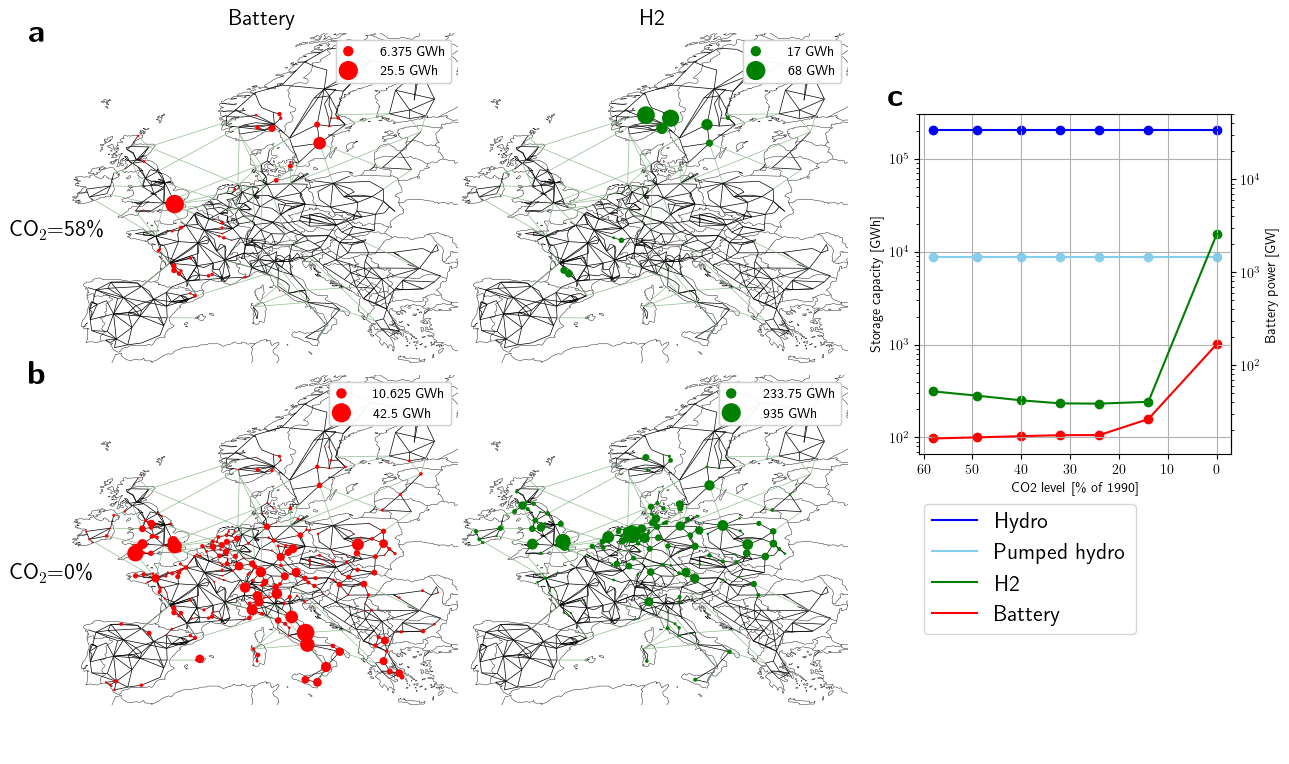

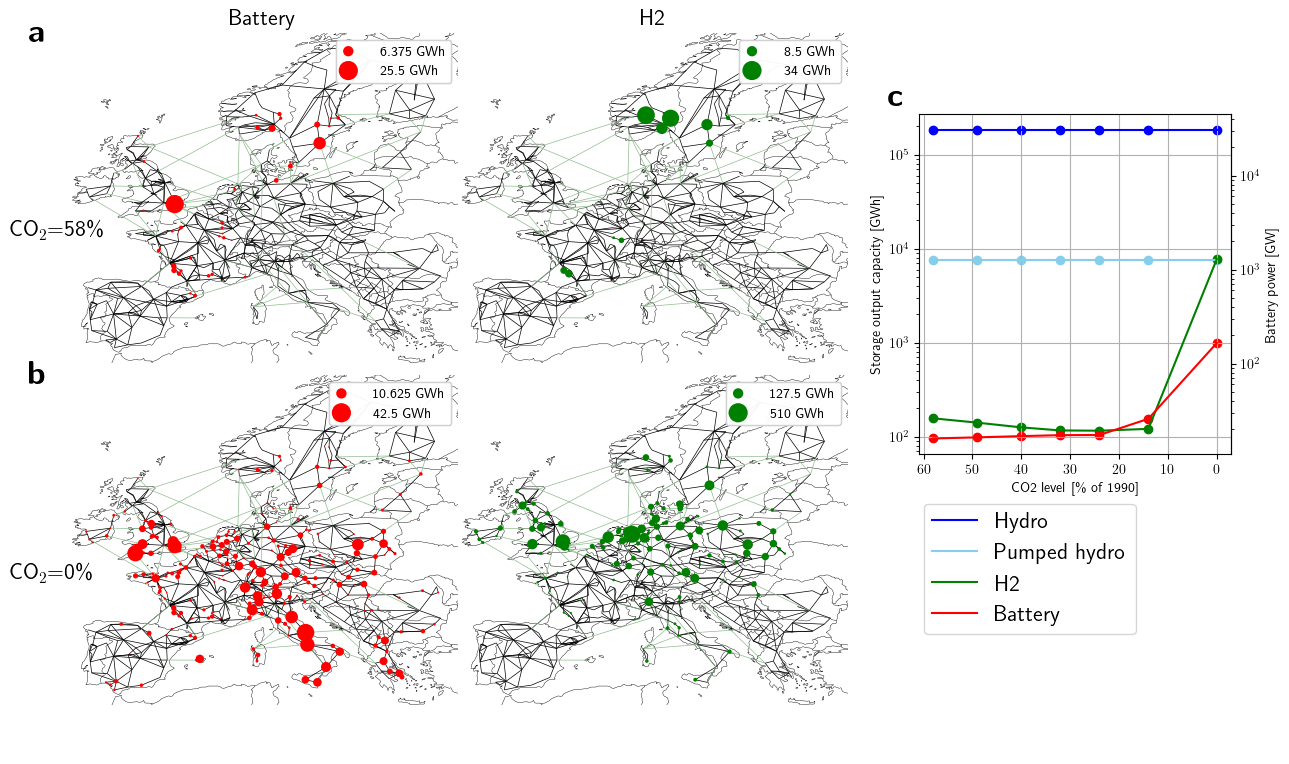

In [50]:
# select whether to plot the storage OUTPUT capacity (capacity * output efficiency) or the storage capacity
for plot_output_capacity in [False, True]:

       mpl.style.use('default')
       plt.rc('text', usetex=True)
       plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

       target_levels = [0.6, 0.0]
       unit = "GWh"
       unit_factor = 1e-3

       f = plt.figure(figsize=(15,10))

       gs = GridSpec(1, 2, width_ratios=[2,0.8], wspace=0.13)
       gs_maps = GridSpecFromSubplotSpec(2, 2, subplot_spec = gs[0], wspace=-0.0, hspace=-0.2)
       gs_lines = GridSpecFromSubplotSpec(3, 1, subplot_spec = gs[1], height_ratios=[0.1,0.4,0.3])

       axs_maps = np.array([[f.add_subplot(gs_maps[j, i], projection=ccrs.PlateCarree())
              for i in range(2)] for j in range(2)])
       ax_line = f.add_subplot(gs_lines[1])

       ##### panal a, b: maps #######

       buses = list(network.buses.index)
       storage_types = network.storage_units["carrier"].unique()
       multi_index = pd.MultiIndex.from_product([buses, storage_types], names=["bus", "carrier"])

       battery_color = "red"
       h2_color = "green"
       for i, target_level in enumerate(target_levels):
              for j, (current_store_type, current_color) in enumerate(zip(["battery", "H2"], [battery_color, h2_color])):
                     n = data_handling.load_pypsa_network_from_path(path_to_pypsa_network_sclopf +
                                   f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc", True)
                     storage_capacities = n.storage_units.max_hours * n.storage_units.p_nom
                     if plot_output_capacity:
                            storage_capacities = n.storage_units.max_hours * n.storage_units.p_nom * n.storage_units.efficiency_dispatch
                     storage_capacities_grouped = storage_capacities.groupby([n.storage_units["bus"], n.storage_units["carrier"]]).sum()
                     max_node_size = 0.85
                     max_capacity = storage_capacities_grouped[:,current_store_type].max()
                     max_capacity_rounded = round(max_capacity, -int(round(np.log10(max_capacity),0))+1)
                     n.plot(bus_sizes=storage_capacities_grouped[:,current_store_type]/max_capacity_rounded*max_node_size,
                            line_colors='black',
                            bus_colors=current_color,
                            link_widths=0.5,
                            line_widths=0.5,
                            ax=axs_maps[i,j])
                     legend_relative_circle_size = np.array([0.25, 1])
                     legend_circle_size = [size*max_node_size for size in legend_relative_circle_size]
                     axs_maps[i,j].legend(loc="upper left")
                     pypsa.plot.add_legend_circles(axs_maps[i,j], sizes=legend_circle_size, labels=[f"{size*max_capacity_rounded*unit_factor:2g} {unit}" for size in legend_circle_size], patch_kw={"color":current_color})
                     

                     # set current_store_type to upper case
                     current_store_type_string = current_store_type[0].upper() + current_store_type[1:]
                     axs_maps[0,j].set_title(current_store_type_string, fontsize=16)
                     
       axs_maps[0,0].text(0 - 0.1, 1,
                     r'\textbf{a}',
                     fontsize=24,
                     weight='bold',
                     verticalalignment='center',
                     transform=axs_maps[0,0].transAxes)
       axs_maps[1,0].text(0 - 0.1, 1,
                     r'\textbf{b}',
                     fontsize=24,
                     weight='bold',
                     verticalalignment='center',
                     transform=axs_maps[1,0].transAxes)


       axs_maps[0,0].text(0 - 0.15, 0.4,
                     fr'CO$_2$={get_actual_co2_level(0.6, percent=True)}\% ',
                     fontsize=16,
                     verticalalignment='center',
                     transform=axs_maps[0,0].transAxes)
       axs_maps[1,0].text(0 - 0.15, 0.4,
                     fr'CO$_2$={get_actual_co2_level( 0, percent=True)}\%',
                     fontsize=16,
                     verticalalignment='center',
                     transform=axs_maps[1,0].transAxes)


       ###### panel c: total capacity line plot #####

       ax_line.text(0 - 0.1, 1+0.05,
                     r'\textbf{c}',
                     fontsize=24,
                     weight='bold',
                     verticalalignment='center',
                     transform=ax_line.transAxes)

       capacity_by_type_by_lvl = pd.DataFrame(index=storage_types, columns=co2ls[::-1])
       for target_level in co2ls:
              n = networks[target_level]
              print(f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc")
              storage_capacities_all_lvl = pd.Series(index=multi_index, data=0)
              storage_capacities_lvl = n.storage_units.max_hours * n.storage_units.p_nom
              if plot_output_capacity:
                     storage_capacities_lvl = storage_capacities_lvl * n.storage_units.efficiency_dispatch
              storage_capacities_grouped_lvl = storage_capacities_lvl.groupby([n.storage_units["carrier"]]).sum()
              capacity_by_type_by_lvl.loc[storage_capacities_grouped_lvl.index,target_level] = storage_capacities_grouped_lvl

              capacity_by_type_by_lvl_plotting = capacity_by_type_by_lvl.T.copy()
       try:
              capacity_by_type_by_lvl_plotting.drop(index=[0.7,0.8], inplace=True)
       except:
              pass

       capacity_by_type_by_lvl_plotting.rename(columns={"battery": "Battery", "hydro": "Hydro", "PHS": "Pumped hydro"},inplace=True)
       colors = ["blue", "skyblue", h2_color, battery_color]
       ax_line.plot(get_actual_co2_level(capacity_by_type_by_lvl.columns,percent=True) ,capacity_by_type_by_lvl_plotting.loc[:,['Hydro', 'Pumped hydro', 'H2','Battery']].values*unit_factor, label=['Hydro', 'Pumped hydro', 'H2','Battery'])
       for feat_count in range(capacity_by_type_by_lvl_plotting.shape[1]):
              plt.scatter(get_actual_co2_level(capacity_by_type_by_lvl.columns,percent=True) ,(capacity_by_type_by_lvl_plotting.loc[:,['Hydro', 'Pumped hydro', 'H2','Battery']].values*unit_factor)[:,feat_count], color=colors[feat_count])
       secax = ax_line.secondary_yaxis('right', functions=(lambda x: x*(1/6), lambda x: x*6))
       secax.set_ylabel('Battery power [GW]')#, weight='normal')
       # secax.tick_params(labelsize=16)
       # secax.tick_params(axis='y', which='both', labelsize=10, width=1)

       for i,j in enumerate(ax_line.lines):
              j.set_color(colors[i])

       ax_line.invert_xaxis()
       ax_line.grid(True)
       plt.yscale('log')
       if plot_output_capacity:
              plt.ylabel(f"Storage output capacity [{unit}]")
       else:
              plt.ylabel(f"Storage capacity [{unit}]")
       plt.xlabel(r"CO2 level [\% of 1990]")
       plt.legend()
       h, l = ax_line.get_legend_handles_labels()
       ax_line.get_legend().remove()
       ax_line_legend = f.add_subplot(gs_lines[2])
       ax_line_legend.legend(h, l, borderaxespad=0.2, fontsize=16, ncol=1, loc="upper left")
       ax_line_legend.axis("off")

       if plot_output_capacity:
              file_name = "storage_output_capacity_vs_co2level"
       else:
              file_name = "storage_capacityvs_co2level"

       plt.savefig(save_path+file_name + '.pdf', bbox_inches='tight')

In [ ]:
n = networks[0.1]
state_of_charge_by_carrier = n.storage_units_t["state_of_charge"].groupby(n.storage_units.carrier, axis=1).sum()
state_of_charge_by_carrier.drop(columns=["battery"]).plot()
plt.yscale('log')

In [ ]:
state_of_charge_by_carrier.groupby(state_of_charge_by_carrier.index.hour).mean().plot()
plt.yscale('log')

In [ ]:
state_of_charge_by_carrier.groupby(state_of_charge_by_carrier.index.dayofyear).mean().plot()
plt.yscale('log')

i tried to use the same node scaling for the different levels but didnt get it to work out...

In [ ]:
# mpl.style.use('default')
# plt.rc('text', usetex=True)
# plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

# target_levels = [0.6, 0.0]

# f = plt.figure(figsize=(15,10))

# gs = GridSpec(1, 2, width_ratios=[2,0.8], wspace=0.13)
# gs_maps = GridSpecFromSubplotSpec(2, 2, subplot_spec = gs[0], wspace=-0.0, hspace=-0.2)
# gs_lines = GridSpecFromSubplotSpec(3, 1, subplot_spec = gs[1], height_ratios=[0.1,0.4,0.3])

# axs_maps = np.array([[f.add_subplot(gs_maps[j, i], projection=ccrs.PlateCarree())
#        for i in range(2)] for j in range(2)])
# ax_line = f.add_subplot(gs_lines[1])

# ##### panal a, b: maps #######

# buses = list(network.buses.index)
# storage_types = network.storage_units["carrier"].unique()
# multi_index = pd.MultiIndex.from_product([buses, storage_types], names=["bus", "carrier"])

# battery_color = "red"
# h2_color = "green"
# for j, (current_store_type, current_color) in enumerate(zip(["battery", "H2"], [battery_color, h2_color])):
#        max_capacity_all_lvls = 0
#        for i, target_level in enumerate(target_levels[::-1]):
#               ax_current = axs_maps[1-i,j]
#               n = data_handling.load_pypsa_network(path_to_pypsa_network_sclopf +
#                             f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc", True)
#               # print(f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc")
#               storage_capacities = n.storage_units.max_hours * n.storage_units.p_nom
#               storage_capacities_grouped = storage_capacities.groupby([n.storage_units["bus"], n.storage_units["carrier"]]).sum()
#               max_node_size = 0.85
#               max_capacity = storage_capacities_grouped[:,current_store_type].max()
#               max_capacity_rounded = round(max_capacity, -int(round(np.log10(max_capacity),0))+1)
#               max_capacity_all_lvls = max(max_capacity_all_lvls, max_capacity_rounded)
#               print(f"max capacity {target_level}, {current_store_type}: {max_capacity}")
#               print(f"max capacity all {target_level}, {current_store_type}: {max_capacity_all_lvls}")
#               n.plot(bus_sizes=storage_capacities_grouped[:,current_store_type]/max_capacity_all_lvls*max_node_size/10e2,
#                      line_colors='black',
#                      bus_colors=current_color,
#                      link_widths=0.5,
#                      line_widths=0.5,
#                      ax=ax_current)
#               legend_relative_circle_size = np.array([0.25, 1])
#               legend_circle_size = [size*max_node_size*max_capacity/max_capacity_all_lvls/10e2 for size in legend_relative_circle_size]
#               ax_current.legend(loc="upper center")
#               pypsa.plot.add_legend_circles(axs_maps[i,j], sizes=legend_circle_size, labels=[f"{size*max_capacity:g} MW" for size in legend_circle_size], patch_kw={"color":current_color})
              
#               # for relative_size_r in [0.25, 1]:
#               #        axs_maps[i,j].plot(
#               #        [],
#               #        [],
#               #        marker="o",
#               #        color=current_color,
#               #        markersize=max_node_size * relative_size_r*10,
#               #        label=f"{int(max_capacity * relative_size_r)} MW",
#               #        lw=0,
#               #        )
#               # axs_maps[i,j].legend(
#               #        labelspacing=1,
#               #        loc="center left",
#               #        bbox_to_anchor=(0.7, 0.975),
#               #        frameon=False,
#               #        fontsize=14,
#               # )

#               # set current_store_type to upper case
#               current_store_type_string = current_store_type[0].upper() + current_store_type[1:]
#               axs_maps[0,j].set_title(current_store_type_string, fontsize=16)
              
# axs_maps[0,0].text(0 - 0.1, 1,
#               r'\textbf{a}',
#               fontsize=24,
#               weight='bold',
#               verticalalignment='center',
#               transform=axs_maps[0,0].transAxes)
# axs_maps[1,0].text(0 - 0.1, 1,
#               r'\textbf{b}',
#               fontsize=24,
#               weight='bold',
#               verticalalignment='center',
#               transform=axs_maps[1,0].transAxes)


# axs_maps[0,0].text(0 - 0.15, 0.4,
#               r'CO$_2$=60\% ',
#               fontsize=16,
#               verticalalignment='center',
#               transform=axs_maps[0,0].transAxes)
# axs_maps[1,0].text(0 - 0.15, 0.4,
#               r'CO$_2$= 0\%',
#               fontsize=16,
#               verticalalignment='center',
#               transform=axs_maps[1,0].transAxes)


# ###### panel c: total capacity line plot #####

# ax_line.text(0 - 0.1, 1+0.05,
#               r'\textbf{c}',
#               fontsize=24,
#               weight='bold',
#               verticalalignment='center',
#               transform=ax_line.transAxes)

# capacity_by_type_by_lvl = pd.DataFrame(index=storage_types, columns=co2ls[::-1])
# for target_level in co2ls:
#     n = data_handling.load_pypsa_network(path_to_pypsa_network_sclopf +
#                             f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc", True)
#     print(f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc")
#     storage_capacities_all_lvl = pd.Series(index=multi_index, data=0)
#     storage_capacities_lvl = n.storage_units.max_hours * n.storage_units.p_nom
#     storage_capacities_grouped_lvl = storage_capacities_lvl.groupby([n.storage_units["carrier"]]).sum()
#     capacity_by_type_by_lvl.loc[storage_capacities_grouped_lvl.index,target_level] = storage_capacities_grouped_lvl

# capacity_by_type_by_lvl_plotting = capacity_by_type_by_lvl.T.copy()
# try:
#        capacity_by_type_by_lvl_plotting.drop(index=[0.7,0.8], inplace=True)
# except:
#        pass
# capacity_by_type_by_lvl_plotting.rename(columns={"battery": "Battery", "hydro": "Hydro", "PHS": "Pumped hydro"},inplace=True)
# ax_line.plot([i*10 for i in range(7)][::-1] ,capacity_by_type_by_lvl_plotting.loc[:,['Hydro', 'Pumped hydro', 'H2','Battery']].values, label=['Hydro', 'Pumped hydro', 'H2','Battery'])
# secax = ax_line.secondary_yaxis('right', functions=(lambda x: x*(1/6), lambda x: x*6))
# secax.set_ylabel('Battery power [MW]')
# colors = ["blue", "skyblue", h2_color, battery_color]

# for i,j in enumerate(ax_line.lines):
#     j.set_color(colors[i])

# ax_line.invert_xaxis()
# ax_line.grid(True)
# plt.yscale('log')
# plt.ylabel("Storage capacity [MWh]")
# plt.xlabel(r"CO2 level [\% of 1990]")
# plt.legend()
# h, l = ax_line.get_legend_handles_labels()
# ax_line.get_legend().remove()
# ax_line_legend = f.add_subplot(gs_lines[2])
# ax_line_legend.legend(h, l, borderaxespad=0.2, fontsize=16, ncol=1, loc="upper left")
# ax_line_legend.axis("off")

# plt.savefig(save_path+'storage_capacity.pdf', bbox_inches='tight')

# node power balance

In [7]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import AxesGrid

def shiftedColorMap(cmap, start=0, midpoint=0.5, stop=1.0, name='shiftedcmap'):
    '''
    Function to offset the "center" of a colormap. Useful for
    data with a negative min and positive max and you want the
    middle of the colormap's dynamic range to be at zero.

    Input
    -----
      cmap : The matplotlib colormap to be altered
      start : Offset from lowest point in the colormap's range.
          Defaults to 0.0 (no lower offset). Should be between
          0.0 and `midpoint`.
      midpoint : The new center of the colormap. Defaults to 
          0.5 (no shift). Should be between 0.0 and 1.0. In
          general, this should be  1 - vmax / (vmax + abs(vmin))
          For example if your data range from -15.0 to +5.0 and
          you want the center of the colormap at 0.0, `midpoint`
          should be set to  1 - 5/(5 + 15)) or 0.75
      stop : Offset from highest point in the colormap's range.
          Defaults to 1.0 (no upper offset). Should be between
          `midpoint` and 1.0.
    '''
    cdict = {
        'red': [],
        'green': [],
        'blue': [],
        'alpha': []
    }

    # regular index to compute the colors
    reg_index = np.linspace(start, stop, 257)

    # shifted index to match the data
    shift_index = np.hstack([
        np.linspace(0.0, midpoint, 128, endpoint=False), 
        np.linspace(midpoint, 1.0, 129, endpoint=True)
    ])

    for ri, si in zip(reg_index, shift_index):
        r, g, b, a = cmap(ri)

        cdict['red'].append((si, r, r))
        cdict['green'].append((si, g, g))
        cdict['blue'].append((si, b, b))
        cdict['alpha'].append((si, a, a))

    newcmap = matplotlib.colors.LinearSegmentedColormap(name, cdict)
    # plt.register_cmap(cmap=newcmap)

    return newcmap


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.05-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.05-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/tmp/ipykernel_1096550/3920462298.py:132: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap("bwr")


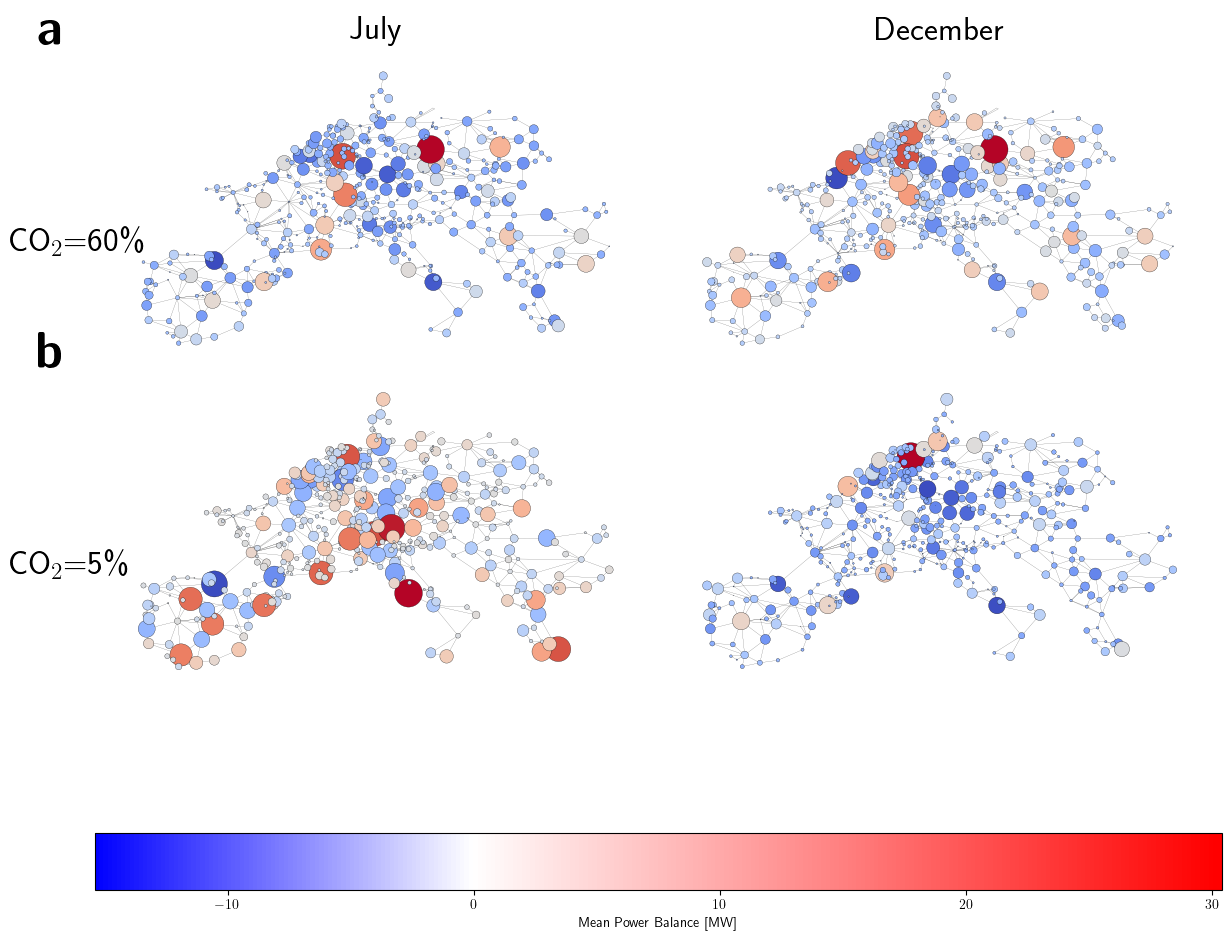

In [ ]:
import matplotlib.cm


mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

target_levels = [0.6, 0.05]

f = plt.figure(figsize=(24, 12))
# gs = GridSpec(2, 3, figure=f)
# ax1 = [f.add_subplot(gs[0, i], projection=ccrs.PlateCarree())
#        for i in range(2)]
# ax2 = [f.add_subplot(gs[1, i], projection=ccrs.PlateCarree())
#        for i in range(2)]
# axs_clust = [ax1, ax2]
# ax3 = f.add_subplot(gs[0, 2])
outer = GridSpec(1, 2, width_ratios = [2, 1]) 
# gs = GridSpec(2, 3, figure=f)
gs_left = GridSpecFromSubplotSpec(2, 2, subplot_spec = outer[0], wspace=-0.0, hspace=0.0)
gs_right = GridSpecFromSubplotSpec(2, 1, subplot_spec = outer[1], height_ratios=[1, 0.6])

# ax1 = [f.add_subplot(gs_left[0, i], projection=ccrs.PlateCarree())
#        for i in range(2)]
# ax2 = [f.add_subplot(gs_left[1, i], projection=ccrs.PlateCarree())
#        for i in range(2)]
ax1 = [f.add_subplot(gs_left[0, i])
       for i in range(2)]
ax2 = [f.add_subplot(gs_left[1, i])
       for i in range(2)]
axs_primary = [ax1, ax2]
# ax3 = f.add_subplot(gs_right[0, 0])
# ax3_legend = f.add_subplot(gs_right[1, 0])
# ax4 = f.add_subplot(outer[1, 1])
labels = [[r'\textbf{a}', r'', r'\textbf{c}'],
          [r'\textbf{b}', '', r'\textbf{d}', '', '']]

##### panal a and b #######

vmax = -np.inf
vmin = np.inf
months = [7, 12]

for i, target_level in enumerate(target_levels):
    n = network = data_handling.load_pypsa_network_from_path(path_to_pypsa_network_sclopf +
                        f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc", True)
    nodal_balance = (
        n.generators_t.p.mul(n.generators.sign)
        .T.groupby(n.generators["bus"])
        .sum()
    )
    nodal_balance = nodal_balance.add(
        n.storage_units_t.p.T.groupby(n.storage_units["bus"]).sum(),
        fill_value=0,
    ).add(-n.loads_t.p.T.groupby(n.loads["bus"]).sum(), fill_value=0)

    ## add hvdc link subtraction/addition
    nodal_balance = nodal_balance.add(
        -n.links_t.p0.T.groupby(n.links["bus0"]).sum(), fill_value=0
    )
    nodal_balance = nodal_balance.add(
        -n.links_t.p1.T.groupby(n.links["bus1"]).sum(), fill_value=0
    )
    nodal_balance = nodal_balance.mul(network.snapshot_weightings.generators, axis="columns")

    # nodal_balance = -nodal_balance
    nodal_balance = nodal_balance.T
    
    for j, month in enumerate(months):

       axs_primary[i][j].axis("off")
       current_snapshots = n.snapshots[n.snapshots.month == month]
    #    current_gen = n.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").loc[current_snapshots].sum().mul(network.generators.sign)
    #    current_gen = current_gen.groupby([n.generators["bus"], n.generators["carrier"]]).sum()
    #    n.plot(bus_sizes=nodal_balance[nodal_balance.index.month==month].abs()/7e6,
    #           color=nodal_balance[nodal_balance.index.month==month],
    #           cmap="coolwarm",
    #           line_colors='black',
    #           link_colors='black',
    #           link_widths=0.5,
    #           line_widths=0.5,
    #           ax=axs_primary[i][j])
       nodal_balance_month = nodal_balance[nodal_balance.index.month==month].mean(axis=0).loc[list(nx_graph.nodes)]/network.snapshot_weightings.generators[current_snapshots].sum()
       vmax = max(vmax,nodal_balance_month.max())
       vmin = min(vmin,nodal_balance_month.min())
       nodes = nx.draw_networkx_nodes(
        nx_graph,
        pos=pos,
        ax=axs_primary[i][j],
        node_size=nodal_balance_month.abs()/nodal_balance_month.abs().max()*400,
        node_color=nodal_balance_month,
        cmap="coolwarm",
        # vmax=np.log10(vmax_node),
        # vmin=np.log10(vmin_node),

        )
       nodes.set_edgecolor("black")
       nodes.set_linewidth(0.2)
       edges = nx.draw_networkx_edges(
            nx_graph,
            pos=pos,
            ax=axs_primary[i][j],
            width=0.1,
            edge_color="black",
       )

       if i == 0:
              axs_primary[i][j].set_title(current_snapshots.month_name()[0], fontsize=24)

       axs_primary[i][j].text(0 - 0.1, 1+0.05,
                     labels[i][j],
                     fontsize=36,
                     weight='bold',
                     verticalalignment='center',
                     transform=axs_primary[i][j].transAxes)


axs_primary[0][0].text(0 - 0.15, 0.4,
               rf'CO$_2$={int(target_levels[0]*100)}\% ',
               fontsize=24,
               verticalalignment='center',
               transform=axs_primary[0][0].transAxes)
axs_primary[1][0].text(0 - 0.15, 0.4,
               rf'CO$_2$={int(target_levels[1]*100)}\% ',
               fontsize=24,
               verticalalignment='center',
               transform=axs_primary[1][0].transAxes)

# sm = plt.cm.ScalarMappable(
#     cmap="coolwarm", norm=mplcolors.Normalize(vmin=vmin, vmax=vmax))
# cb = f.colorbar(sm, ax=np.array(axs_primary), orientation="horizontal")
cmap = matplotlib.cm.get_cmap("bwr")
cmap = shiftedColorMap(cmap, start=0, midpoint=1 - vmax / (vmax + abs(vmin)), stop=1)
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.Normalize(vmin=vmin, vmax=vmax))
    # cmap=cmap, norm=mplcolors.TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax))

    # cmap="coolwarm", norm=mplcolors.CenteredNorm(vcenter=0))
# colorbar_axis = f.add_axes([0.2, 0.0, 0.5, 0.02])
cb = f.colorbar(sm, ax=np.array(axs_primary), orientation="horizontal", location="bottom", label="Mean Power Balance [MW]")
# cb.set_ylim(vmin,vmax)
# add ticks
# cb.set_ticks([vmin, vmax])

# ###### panel c ######

# co2s = generation_by_carrier_and_co2l.columns.astype('float')
# index = np.argsort(co2s)
# generation_by_carrier_and_co2l = generation_by_carrier_and_co2l.rename(index=network.carriers.nice_name)
# for ind,data in generation_by_carrier_and_co2l.iterrows():
#     ax3.scatter(co2s[index]*100,
#                 (d                                                                                         | 0/4 [00:00<?, ?it/s]2025-06-08 11:26:51.424 | INFO     | __main__:<module>:424 - performing optics clustering with min_samples 10ata.values)[index]*1e-6,
#                 color=n.carriers.set_index('nice_name').color.loc[ind],
#                 label=ind,
#                 s=100)

#     ax3.plot(co2s[index]*100,
#              (data.values)[index]*1e-6,
#              color=n.carriers.set_index('nice_name').color.loc[ind])


# ax3.invert_xaxis()
# ax3.tick_params(axis='both', which='both', labelsize=24)
# ax3.set_xlabel(r'$\text{CO}_2$ level [\% of 1990]',  fontsize=24)
# ax3.set_ylabel(r'Total annual generation [TWh]', fontsize=24)

# ax3.grid(True)
# ax3.yaxis.offsetText.set_fontsize(24)
# ax3.text(0 - 0.15, 1+0.05,
#          labels[0][2],
#          fontsize=36,
#          weight='b                                                                                         | 0/4 [00:00<?, ?it/s]2025-06-08 11:26:51.424 | INFO     | __main__:<module>:424 - performing optics clustering with min_samples 10old',
#          verticalalignment='center',
#          transform=ax3.transAxes)
# ax3.plot([746/1251*100, 746/1251*100],[-2e1,1000], '--', lw=4, c='r', zorder=-1000) # TODO: Insert CO2 limit that corresponds to todays amount
# # co2 emissions from https://www.umweltbundesamt.de/daten/klima/treibhausgas-emissionen-in-deutschland#emissionsentwicklung
# # ax3.text(50,12e2*0.9, r'\textbf{2022`s emissions}', fontsize=24, color='r')
# ax3.text(746/1251*100,1050, r'\textbf{2022`s emissions}', fontsize=24, color='r', horizontalalignment='left')
# ax3.set_ylim([-2e1,12.4e2])
# # ax3.set_yscale('log')

# # f.subplots_adjust(hspace=0.05, wspace=0.2)
# h, l = ax3.get_legend_handles_labels()
# ax3_legend.legend(h, l, borderaxespad=0, fontsize=20.5, ncol=2)
# ax3_legend.axis("off")
# ax3.legend(fontsize=20.5, bbox_to_anchor=(1.02,0), ncol=2, loc="upper left")
# plt.tight_layout()
# ax3.legend(fontsize=20.5, ncol=2, columnspacing=0.5, handletextpad=0.1, borderpad=0.3)
# plt.tight_layout()

plt.savefig(save_path+'nodal_balance_versus_co2level.pdf', bbox_inches='tight')

In [14]:
n.loads_t["p_set"]

Load,AL1 0,AT1 0,AT1 1,AT1 10,AT1 11,AT1 2,AT1 3,AT1 4,AT1 5,AT1 6,...,SE2 7,SE2 8,SE2 9,SI1 0,SI1 1,SK1 0,SK1 1,SK1 2,SK1 3,SK1 4
snapshot,,,,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,793.413793,928.924002,1986.986898,198.548665,140.562779,253.997222,312.040873,971.341379,388.406454,337.317985,...,74.160762,1593.160752,259.990149,897.697780,222.635553,1227.062188,702.871674,372.703365,198.555992,170.140114
2013-01-01 03:00:00,697.758621,888.763658,1901.083125,189.964773,134.485802,243.016113,298.550352,929.347197,371.614406,322.734654,...,73.633871,1581.841802,258.142993,875.262013,217.071320,1179.596593,675.682977,358.286339,190.875389,163.558702
2013-01-01 06:00:00,754.103448,986.216036,2109.535699,210.794292,149.232086,269.662677,331.286211,1031.249535,412.361693,358.122307,...,78.212313,1680.198301,274.193929,851.223691,211.109642,1196.439224,685.330579,363.402058,193.600764,165.894042
2013-01-01 09:00:00,847.793103,1111.119789,2376.707307,237.491280,168.132253,303.815316,373.243438,1161.856757,464.587088,403.478312,...,83.379632,1791.205393,292.309333,867.783424,215.216576,1301.169762,745.321124,395.212528,210.547644,180.415609
2013-01-01 12:00:00,817.655172,1090.175407,2331.906859,233.014618,164.962994,298.088460,366.207876,1139.955994,455.829716,395.872828,...,87.563766,1881.091175,306.977920,840.807085,208.526249,1308.366159,749.443281,397.398335,211.712123,181.413436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-31 09:00:00,914.620690,1276.234721,2729.891429,272.783026,193.117089,348.962965,428.708264,1334.511318,533.625788,463.436109,...,88.719138,1905.911487,311.028382,1100.688055,272.978612,1452.294092,831.886427,441.114477,235.001695,201.369975
2013-12-31 12:00:00,901.517241,1193.728091,2553.408107,255.148019,180.632363,326.403041,400.992928,1248.237195,499.127694,433.475671,...,91.091869,1956.883754,319.346618,1063.295109,263.704891,1435.298347,822.151120,435.952252,232.251544,199.013405
2013-12-31 15:00:00,1022.724138,1291.892172,2763.383026,276.129657,195.486340,353.244207,433.967859,1350.883733,540.172561,469.121762,...,95.325937,2047.842246,334.190263,1151.702716,285.630618,1454.437700,833.114304,441.765568,235.348561,201.667200


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/tmp/ipykernel_1096550/538296648.py:136: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap("bwr")


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/tmp/ipykernel_1096550/538296648.py:136: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap("bwr")


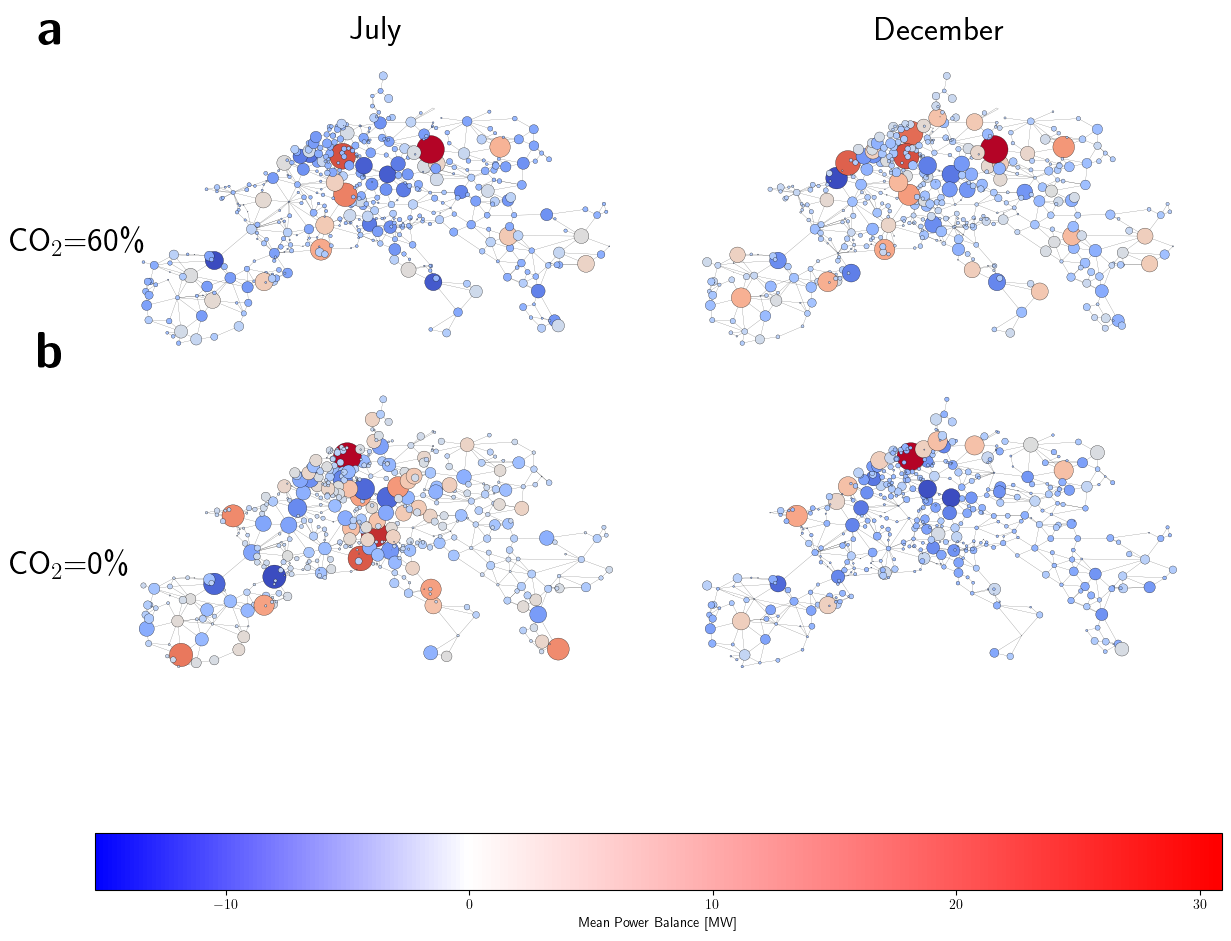

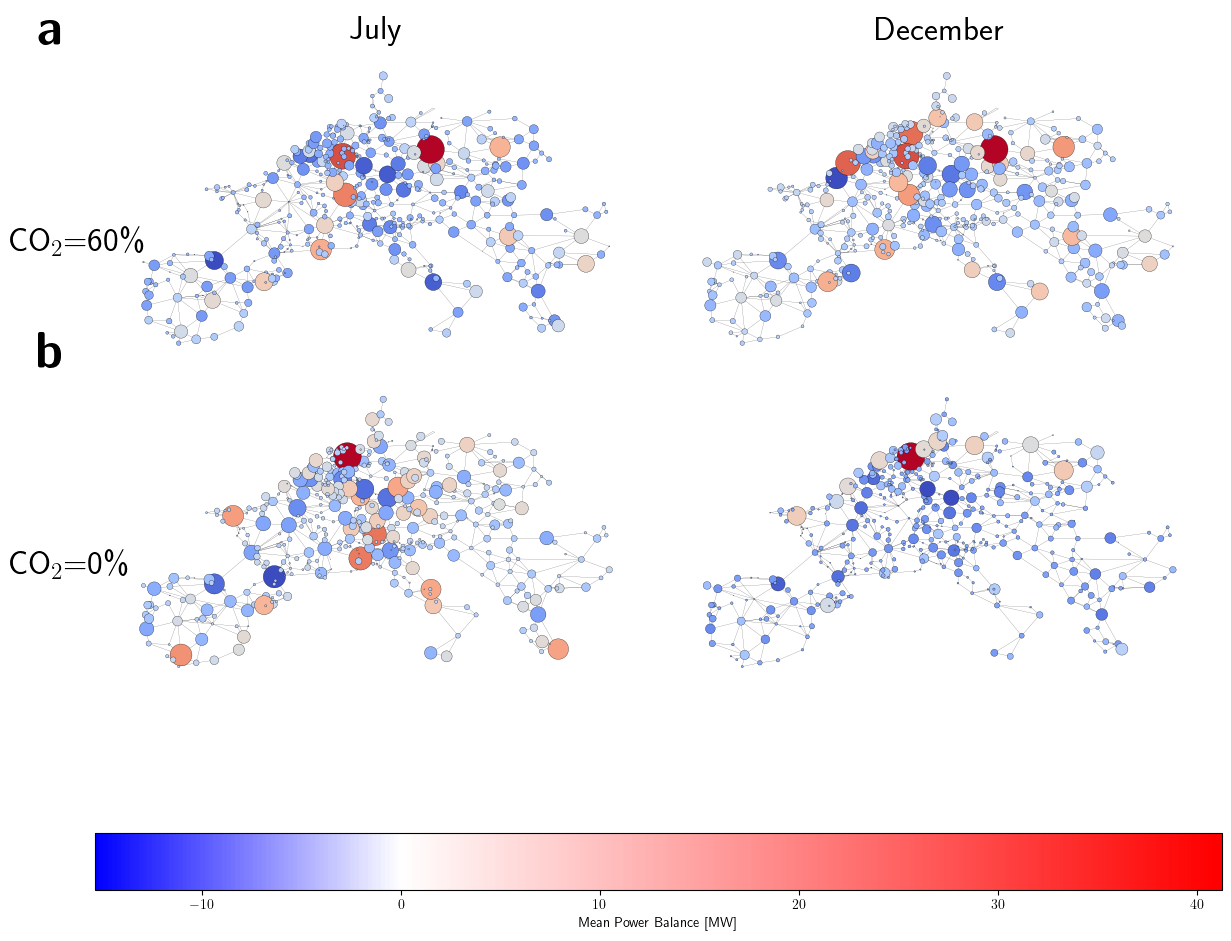

In [21]:
import matplotlib.cm


mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

for ignore_storage in [True, False]:
    
    target_levels = [0.6, 0.0]

    f = plt.figure(figsize=(24, 12))
    # gs = GridSpec(2, 3, figure=f)
    # ax1 = [f.add_subplot(gs[0, i], projection=ccrs.PlateCarree())
    #        for i in range(2)]
    # ax2 = [f.add_subplot(gs[1, i], projection=ccrs.PlateCarree())
    #        for i in range(2)]
    # axs_clust = [ax1, ax2]
    # ax3 = f.add_subplot(gs[0, 2])
    outer = GridSpec(1, 2, width_ratios = [2, 1]) 
    # gs = GridSpec(2, 3, figure=f)
    gs_left = GridSpecFromSubplotSpec(2, 2, subplot_spec = outer[0], wspace=-0.0, hspace=0.0)
    gs_right = GridSpecFromSubplotSpec(2, 1, subplot_spec = outer[1], height_ratios=[1, 0.6])

    # ax1 = [f.add_subplot(gs_left[0, i], projection=ccrs.PlateCarree())
    #        for i in range(2)]
    # ax2 = [f.add_subplot(gs_left[1, i], projection=ccrs.PlateCarree())
    #        for i in range(2)]
    ax1 = [f.add_subplot(gs_left[0, i])
        for i in range(2)]
    ax2 = [f.add_subplot(gs_left[1, i])
        for i in range(2)]
    axs_primary = [ax1, ax2]
    # ax3 = f.add_subplot(gs_right[0, 0])
    # ax3_legend = f.add_subplot(gs_right[1, 0])
    # ax4 = f.add_subplot(outer[1, 1])
    labels = [[r'\textbf{a}', r'', r'\textbf{c}'],
            [r'\textbf{b}', '', r'\textbf{d}', '', '']]

    ##### panal a and b #######

    vmax = -np.inf
    vmin = np.inf
    months = [7, 12]

    for i, target_level in enumerate(target_levels):
        n = network = data_handling.load_pypsa_network_from_path(path_to_pypsa_network_sclopf +
                            f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}-2920SEG.nc", True)
        nodal_balance = (
            n.generators_t.p.mul(n.generators.sign)
            .T.groupby(n.generators["bus"])
            .sum()
        )
        if ignore_storage:
            nodal_balance = nodal_balance.add(
                n.storage_units_t.p.T.groupby(n.storage_units["bus"]).sum(),
                fill_value=0,
            )
        nodal_balance = nodal_balance.add(-n.loads_t.p.T.groupby(n.loads["bus"]).sum(), fill_value=0)

        ## add hvdc link subtraction/addition
        nodal_balance = nodal_balance.add(
            -n.links_t.p0.T.groupby(n.links["bus0"]).sum(), fill_value=0
        )
        nodal_balance = nodal_balance.add(
            -n.links_t.p1.T.groupby(n.links["bus1"]).sum(), fill_value=0
        )
        nodal_balance = nodal_balance.mul(network.snapshot_weightings.generators, axis="columns")

        # nodal_balance = -nodal_balance
        nodal_balance = nodal_balance.T
        
        for j, month in enumerate(months):

            axs_primary[i][j].axis("off")
            current_snapshots = n.snapshots[n.snapshots.month == month]
            #    current_gen = n.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").loc[current_snapshots].sum().mul(network.generators.sign)
            #    current_gen = current_gen.groupby([n.generators["bus"], n.generators["carrier"]]).sum()
            #    n.plot(bus_sizes=nodal_balance[nodal_balance.index.month==month].abs()/7e6,
            #           color=nodal_balance[nodal_balance.index.month==month],
            #           cmap="coolwarm",
            #           line_colors='black',
            #           link_colors='black',
            #           link_widths=0.5,
            #           line_widths=0.5,
            #           ax=axs_primary[i][j])
            nodal_balance_month = nodal_balance[nodal_balance.index.month==month].mean(axis=0).loc[list(nx_graph.nodes)]/network.snapshot_weightings.generators[current_snapshots].sum()
            vmax = max(vmax,nodal_balance_month.max())
            vmin = min(vmin,nodal_balance_month.min())
            nodes = nx.draw_networkx_nodes(
                nx_graph,
                pos=pos,
                ax=axs_primary[i][j],
                node_size=nodal_balance_month.abs()/nodal_balance_month.abs().max()*400,
                node_color=nodal_balance_month,
                cmap="coolwarm",
                # vmax=np.log10(vmax_node),
                # vmin=np.log10(vmin_node),

                )
            nodes.set_edgecolor("black")
            nodes.set_linewidth(0.2)
            edges = nx.draw_networkx_edges(
                    nx_graph,
                    pos=pos,
                    ax=axs_primary[i][j],
                    width=0.1,
                    edge_color="black",
            )

            if i == 0:
                    axs_primary[i][j].set_title(current_snapshots.month_name()[0], fontsize=24)

            axs_primary[i][j].text(0 - 0.1, 1+0.05,
                            labels[i][j],
                            fontsize=36,
                            weight='bold',
                            verticalalignment='center',
                            transform=axs_primary[i][j].transAxes)


    axs_primary[0][0].text(0 - 0.15, 0.4,
                rf'CO$_2$={int(target_levels[0]*100)}\% ',
                fontsize=24,
                verticalalignment='center',
                transform=axs_primary[0][0].transAxes)
    axs_primary[1][0].text(0 - 0.15, 0.4,
                rf'CO$_2$={int(target_levels[1]*100)}\% ',
                fontsize=24,
                verticalalignment='center',
                transform=axs_primary[1][0].transAxes)

    # sm = plt.cm.ScalarMappable(
    #     cmap="coolwarm", norm=mplcolors.Normalize(vmin=vmin, vmax=vmax))
    # cb = f.colorbar(sm, ax=np.array(axs_primary), orientation="horizontal")
    cmap = matplotlib.cm.get_cmap("bwr")
    cmap = shiftedColorMap(cmap, start=0, midpoint=1 - vmax / (vmax + abs(vmin)), stop=1)
    sm = plt.cm.ScalarMappable(
        cmap=cmap, norm=mplcolors.Normalize(vmin=vmin, vmax=vmax))
        # cmap=cmap, norm=mplcolors.TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax))

        # cmap="coolwarm", norm=mplcolors.CenteredNorm(vcenter=0))
    # colorbar_axis = f.add_axes([0.2, 0.0, 0.5, 0.02])
    cb = f.colorbar(sm, ax=np.array(axs_primary), orientation="horizontal", location="bottom", label="Mean Power Balance [MW]")
    # cb.set_ylim(vmin,vmax)
    # add ticks
    # cb.set_ticks([vmin, vmax])

    # ###### panel c ######

    # co2s = generation_by_carrier_and_co2l.columns.astype('float')
    # index = np.argsort(co2s)
    # generation_by_carrier_and_co2l = generation_by_carrier_and_co2l.rename(index=network.carriers.nice_name)
    # for ind,data in generation_by_carrier_and_co2l.iterrows():
    #     ax3.scatter(co2s[index]*100,
    #                 (data.values)[index]*1e-6,
    #                 color=n.carriers.set_index('nice_name').color.loc[ind],
    #                 label=ind,
    #                 s=100)

    #     ax3.plot(co2s[index]*100,
    #              (data.values)[index]*1e-6,
    #              color=n.carriers.set_index('nice_name').color.loc[ind])


    # ax3.invert_xaxis()
    # ax3.tick_params(axis='both', which='both', labelsize=24)
    # ax3.set_xlabel(r'$\text{CO}_2$ level [\% of 1990]',  fontsize=24)
    # ax3.set_ylabel(r'Total annual generation [TWh]', fontsize=24)

    # ax3.grid(True)
    # ax3.yaxis.offsetText.set_fontsize(24)
    # ax3.text(0 - 0.15, 1+0.05,
    #          labels[0][2],
    #          fontsize=36,
    #          weight='bold',
    #          verticalalignment='center',
    #          transform=ax3.transAxes)
    # ax3.plot([746/1251*100, 746/1251*100],[-2e1,1000], '--', lw=4, c='r', zorder=-1000) # TODO: Insert CO2 limit that corresponds to todays amount
    # # co2 emissions from https://www.umweltbundesamt.de/daten/klima/treibhausgas-emissionen-in-deutschland#emissionsentwicklung
    # # ax3.text(50,12e2*0.9, r'\textbf{2022`s emissions}', fontsize=24, color='r')
    # ax3.text(746/1251*100,1050, r'\textbf{2022`s emissions}', fontsize=24, color='r', horizontalalignment='left')
    # ax3.set_ylim([-2e1,12.4e2])
    # # ax3.set_yscale('log')

    # # f.subplots_adjust(hspace=0.05, wspace=0.2)
    # h, l = ax3.get_legend_handles_labels()
    # ax3_legend.legend(h, l, borderaxespad=0, fontsize=20.5, ncol=2)
    # ax3_legend.axis("off")
    # ax3.legend(fontsize=20.5, bbox_to_anchor=(1.02,0), ncol=2, loc="upper left")
    # plt.tight_layout()
    # ax3.legend(fontsize=20.5, ncol=2, columnspacing=0.5, handletextpad=0.1, borderpad=0.3)
    # plt.tight_layout()

    fig_path = save_path+'nodal_balance_versus_co2level'
    if ignore_storage:
        fig_path += "_no_storage"
    fig_path += '.pdf'
    plt.savefig(fig_path, bbox_inches='tight')

In [24]:
nodal_balance.month

AttributeError: 'DataFrame' object has no attribute 'month'

<Axes: xlabel='snapshot'>

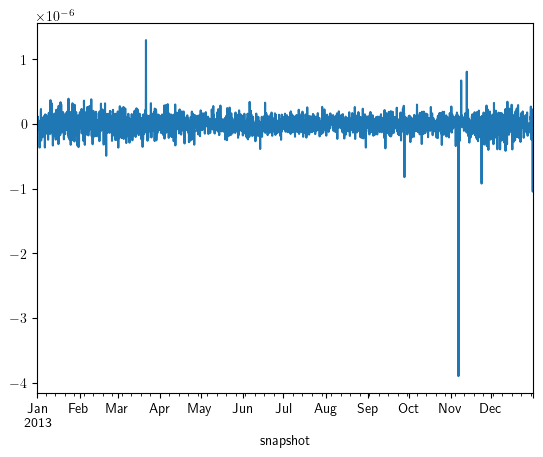

In [16]:
nodal_balance.sum(axis=1).plot()

In [20]:
n.generators_t.p.columns

Index(['AL1 0 art_load', 'AL1 0 load', 'AL1 0 offwind-ac',
       'AL1 0 offwind-float', 'AL1 0 oil', 'AL1 0 onwind', 'AL1 0 ror',
       'AL1 0 solar', 'AL1 0 solar-hsat', 'AT1 0 CCGT',
       ...
       'SK1 3 onwind', 'SK1 3 ror', 'SK1 3 solar', 'SK1 3 solar-hsat',
       'SK1 4 art_load', 'SK1 4 load', 'SK1 4 onwind', 'SK1 4 ror',
       'SK1 4 solar', 'SK1 4 solar-hsat'],
      dtype='object', name='Generator', length=4074)

In [ ]:
state_of_charge_by_carrier = n.storage_units_t["state_of_charge"].groupby(n.storage_units.carrier, axis=1)
state_of_charge_by_carrier.sum().plot()

In [ ]:
fig, ax = plt.subplots()
nodes = nx.draw_networkx_nodes(
nx_graph,
pos=pos,
ax=ax,
node_size=nodal_balance_month.abs()/nodal_balance_month.abs().max()*300,
node_color=nodal_balance_month,
cmap="coolwarm",
# vmax=np.log10(vmax_node),
# vmin=np.log10(vmin_node),

)
nodes.set_edgecolor("black")
nodes.set_linewidth(0.2)
edges = nx.draw_networkx_edges(
    nx_graph,
    pos=pos,
    ax=ax,
    width=0.1,
    edge_color="black",
)

# Figure 4: inertia

In [ ]:
import glob
import shutil

src_pattern = "/srv/data/jlange/power-system-split/no_extensions//results/sclopf/evaluation_results/failed_edges_indicator_vector_Co2L*"
dst_dir = "/srv/data/jlange/power-system-split/no_extensions//results/sclopf/evaluation_results/"

for src_path in glob.glob(src_pattern):
    filename = src_path.split('/')[-1].replace("Co2L", "Co2L")
    dst_path = dst_dir + filename
    shutil.move(src_path, dst_path)

In [ ]:
inertia_time = np.load(path_to_pre_outage_sclopf +
                       f'inertia_time_series_all_co2ls_{n_nodes}.npy')
inertia_generation = np.load(
    path_to_pre_outage_sclopf + f'min_max_nodal_inertia_generation_all_co2ls_{n_nodes}.npy')


In [ ]:
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')
labels = [[r'\textbf{a}', r'\textbf{b}'], [
    r'\textbf{c}', r'\textbf{d}'], [r'\textbf{e}']]
f = plt.figure(figsize=(24, 14), constrained_layout=True)
gs_maps = GridSpec(3, 4, figure=f)
gs_probs = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_maps[2, :], width_ratios=[8, 1])
axs_probs_plot = f.add_subplot(gs_probs[0, 0])
axs_probs_legend = f.add_subplot(gs_probs[0, 1])
ax2 = f.add_subplot(gs_maps[0, :2])
ax3 = f.add_subplot(gs_maps[1, :2])
ax21 = f.add_subplot(gs_maps[0, 2])
ax22 = f.add_subplot(gs_maps[0, 3])
ax31 = f.add_subplot(gs_maps[1, 2])
ax32 = f.add_subplot(gs_maps[1, 3])
axs_primary = [[ax21, ax22], [ax31, ax32]]

target_levels = [0.60, 0.0]

########## panel  e: inertia histograms ############

cmap = plt.get_cmap('cividis_r')
bins = np.linspace(0, 1600, 40)

for count, level in enumerate(selected_co2ls[::-1]):

    ind = np.where(np.round(co2ls, 2) == level)[0][0]

    # ax.hist(np.repeat(inertia_time[ind], network.snapshot_weightings.generators)/1000,
    axs_probs_plot.hist(inertia_time[ind]/1000,
            weights=network.snapshot_weightings.generators,
            bins=bins,
            histtype='step',
            label=r'{} \%'.format(int(level*100)),
            linewidth=3,
            color=cmap(ind/len(co2ls)),
            alpha=0.8)
axs_probs_plot.xaxis.offsetText.set_fontsize(24)

leg = axs_probs_plot.legend(fontsize=24, title=r'CO$_2$ level [\% of 1990]')
h, l = axs_probs_plot.get_legend_handles_labels()
leg = axs_probs_legend.legend(h, l, borderaxespad=0, fontsize=20.5, title=r'CO$_2$ level [\% of 1990]')
# axs_probs_legend.legend(fontsize=24, title=r'CO$_2$ level [\% of 1990]')
axs_probs_legend.axis("off")
# leg=axs_probs_plot.legend(fontsize=24, title=r'CO$_2$ level [\% of 1990]')

plt.setp(leg.get_title(),fontsize=24)
axs_probs_plot.tick_params(axis='both', which='both', labelsize=24)
axs_probs_plot.set_xlabel('Rotational energy [GWs]',  fontsize=30)
axs_probs_plot.set_ylabel('Hours', fontsize=30)
axs_probs_plot.set_yscale('log')
axs_probs_plot.grid()
axs_probs_plot.get_legend().remove()


############# panels a and c: inertia time series ################

axes = [ax2, ax3]

for j, level in enumerate(target_levels):

    ind = np.where(np.round(co2ls, 2) == level)[0][0]

    print(f"co2 level: {level}")
    print(np.amax(inertia_time[ind]/1000))
    print(np.median(inertia_time[ind]/1000))
    print(np.amin(inertia_time[ind]/1000))
    axes[j].plot(network.snapshots,
                 inertia_time[ind]/1000,
                 color=cmap(ind/len(co2ls)),
                 lw=3,
                 alpha=0.8,
                 label=r'$\text{CO}_2\text{ level} =$ '+ '{} \% of 1990'.format(int(level*100)))
    axes[j].legend(fontsize=24)
    axes[j].tick_params(axis='both', which='both', labelsize=24)
    axes[j].set_ylabel('Rotational energy [GWs]', fontsize=30)
    axes[j].set_xlabel('Time', fontsize=30)
    axes[j].set_ylim([0, 1600])
    axes[j].yaxis.offsetText.set_fontsize(24)
    axes[j].grid()


########### panels b and d: maps with nodal inertia ###############

target_levels = [0.60, 0.05]
titles = ['Smallest inertia', 'Largest inertia']

for j, level in enumerate(target_levels):

    ind = np.where(co2ls == level)[0][0]
    
    for i in range(len(titles)):
        nx.draw_networkx_nodes(nx_graph,
                               pos,
                               ax=axs_primary[j][i],
                               node_size=inertia_generation[ind, i]/300,
                               alpha=0.8,
                               node_color='black')
        nx.draw_networkx_edges(nx_graph,
                               pos,
                               ax=axs_primary[j][i],
                               alpha=0.4,
                               width=0.2)
        if j == 0:
            axs_primary[j][i].set_title(titles[i], fontsize=30)
        axs_primary[j][i].axis('off')

# panel labels
ax3.text(0 - 2.25*0.075, 1+0.05,
         labels[1][0],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax3.transAxes)
ax2.text(0 - 2.25*0.075, 1+0.05,
         labels[0][0],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax2.transAxes)
ax31.text(0 - 0.05, 1+0.05,
          labels[1][1],
          fontsize=36,
          weight='bold',
          verticalalignment='center',
          transform=ax31.transAxes)
ax21.text(0 - 0.05, 1+0.05,
          labels[0][1],
          fontsize=36,
          weight='bold',
          verticalalignment='center',
          transform=ax21.transAxes)
axs_probs_plot.text(0 - 0.075, 1+0.05,
        labels[2][0],
        fontsize=36,
        weight='bold',
        verticalalignment='center',
        transform=axs_probs_plot.transAxes)


plt.savefig(save_path+'total_system_inertia.pdf',bbox_inches = 'tight')


# Figure 3: SPI

In [64]:
mean_consumption_vector = np.load(
    path_to_pre_outage_sclopf + f'mean_nodal_consumption_all_co2ls_{n_nodes}.npy')
weighted_mean_consumption_vector = np.load(
    path_to_pre_outage_sclopf + f'weighted_mean_nodal_consumption_all_co2ls_{n_nodes}.npy')
dipole_vector = np.load(path_to_pre_outage_sclopf +
                        f'dipole_vector_time_series_all_co2ls_{n_nodes}.npy')
vec_norm = np.load(path_to_pre_outage_sclopf + f'spi_time_series_all_co2ls_{n_nodes}.npy')

In [65]:
for i, level in enumerate(selected_co2ls):

    ind = np.where(np.round(co2ls, 2) == level)[0][0]
    
    spi = vec_norm[ind]
    
    print(f"co2: {level}, spi: [{spi.min()}, {spi.max()}]")

co2: 0.0, spi: [0.3136524712186487, 37.748664429453356]
co2: 0.2, spi: [0.16293554533785118, 40.87837952528651]
co2: 0.6, spi: [0.374966838493122, 31.931401291786873]


In [73]:
current_level

0.05

In [71]:
co2ls==current_level

array([False, False, False, False, False, False, False])

In [69]:
np.where(co2ls == current_level)[0][0]

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
co2ls.sorted

AttributeError: 'numpy.ndarray' object has no attribute 'sorted'

In [87]:
co2ls

[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

In [84]:
current_level

0.6

In [86]:
co2ls == current_level

False

Figure 3


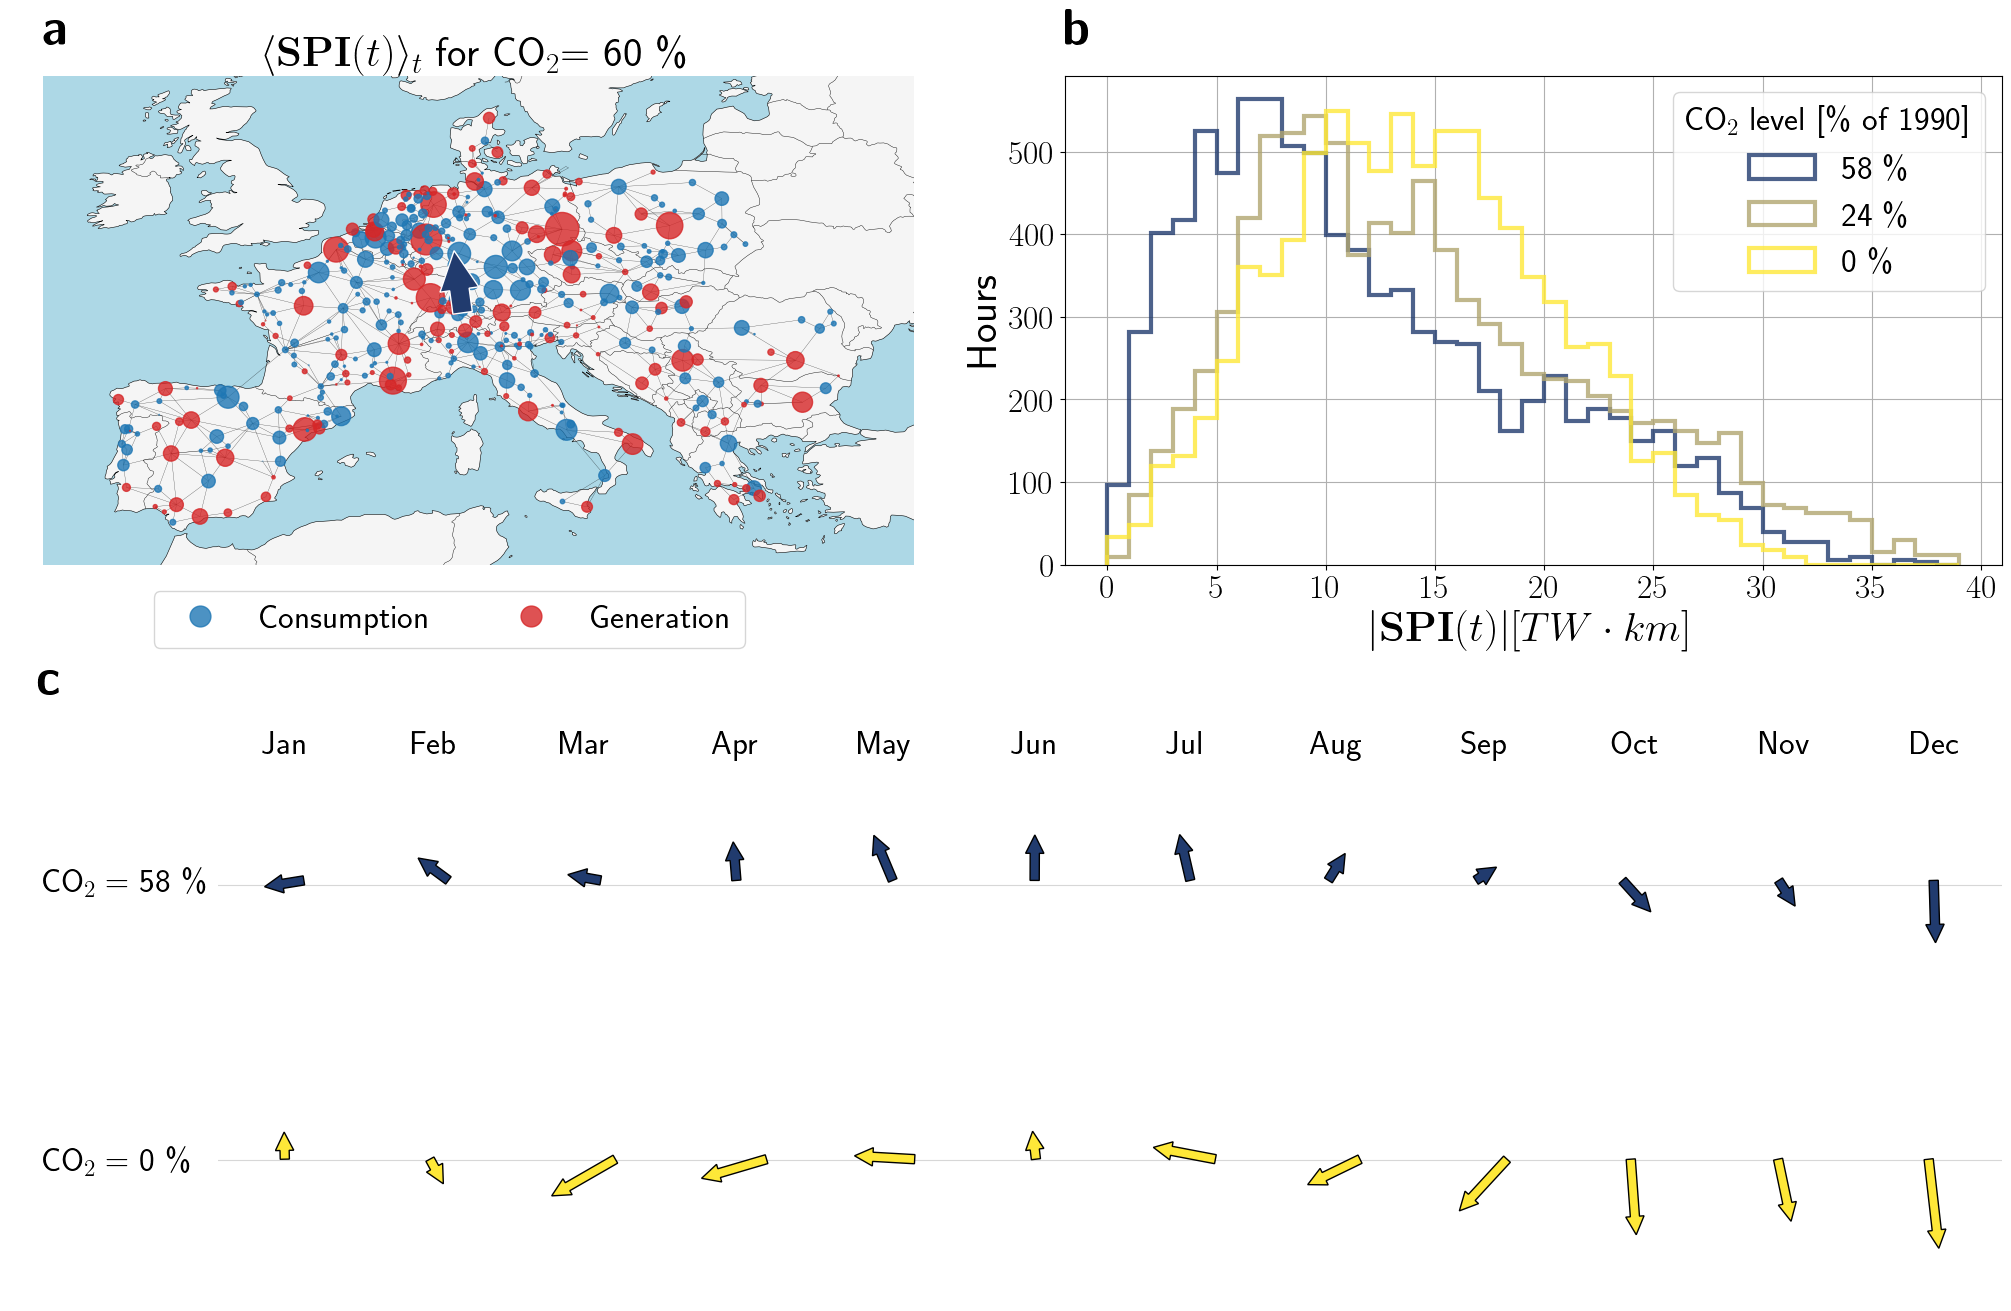

In [91]:
print("Figure 3")

mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
labels = [[r'\textbf{a}', r'\textbf{b}'], [
    r'\textbf{c}', r'\textbf{d}', r'\textbf{e}', r'\textbf{f}']]

f = plt.figure(figsize=(20, 13), constrained_layout=True)
gs0= GridSpec(2,1, figure=f, hspace=0.9) # outer grid
gs1 = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs0[0])
axs_probs = f.add_subplot(gs1[0], projection=ccrs.PlateCarree())
ax2 = f.add_subplot(gs1[1])
gs2 = GridSpecFromSubplotSpec(2, 13, subplot_spec=gs0[1], hspace=0)
# axs_leg = f.add_subplot(gs0[0,0])
# axs_leg.axis('off')
axs_co2_0 = f.add_subplot(gs2[0, 0])
axs_co2_1 = f.add_subplot(gs2[1, 0])
axs_co2_0.axis('off')
axs_co2_1.axis('off')

axs_primary = [f.add_subplot(gs2[0, i+1], projection=ccrs.PlateCarree())
       for i in range(12)]
axs_secondary = [f.add_subplot(gs2[1, i+1], projection=ccrs.PlateCarree())
        for i in range(12)]


##########  panel a : Mean SPI on map for 60% co2 level  ###################

resolution = "50m"
color_geomap = {'ocean': 'lightblue', 'land': 'whitesmoke'}

axs_probs.add_feature(cartopy.feature.LAND.with_scale(resolution),
               facecolor=color_geomap['land'])
axs_probs.add_feature(cartopy.feature.OCEAN.with_scale(resolution),
               facecolor=color_geomap['ocean'])
axs_probs.coastlines(linewidth=0.4, zorder=2, resolution=resolution)
border = cartopy.feature.BORDERS.with_scale(resolution)
axs_probs.add_feature(border, linewidth=0.3)
cmap = plt.get_cmap('cividis_r')
position_vector = np.array([pos[n] for n in nx_graph.nodes()])
mean_pos = [np.mean(position_vector[:, 0]), np.mean(position_vector[:, 1])]


nx.draw_networkx_edges(nx_graph,
                       pos,
                       ax=axs_probs,
                       alpha=0.8,
                       width=0.2)

scale_factor = 2e4

# current_vec = np.mean(dipole_vector, axis=2)
# use average weighted by snapshot weight
current_vec = np.average(dipole_vector, weights=network.snapshot_weightings.generators, axis=2)
vec = weighted_mean_consumption_vector
plot_co2ls = [0.6]

for i, level in enumerate(plot_co2ls):

    ind = np.where(np.round(co2ls, 2) == level)[0][0]

    node_colours = ['tab:red' if vec[ind, i] <
                    0 else 'tab:blue' for i in range(len(nx_graph.nodes()))]

    nx.draw_networkx_nodes(nx_graph,
                           pos,
                           ax=axs_probs,
                           node_size=np.abs(vec[ind])/30,
                           node_color=node_colours,
                           alpha=0.8)

    axs_probs.arrow(mean_pos[0],
             mean_pos[1],
             current_vec[ind, 0]/scale_factor,
             current_vec[ind, 1]/scale_factor,
             head_width=2.0,
             width=1.0,
             head_length=2.0,
            #  alpha  = 1,
             facecolor=cmap(ind/len(co2ls)),
            #  facecolor="cmap(ind/len(co2ls))",
             edgecolor="white",
             zorder=np.inf)
    axs_probs.axis('off')


# add legend

blue_circle = mlines.Line2D([], [], color='tab:blue', marker='o', linestyle='None',
                          markersize=15, label='Consumption', alpha=0.8)
red_circle = mlines.Line2D([], [], color='tab:red', marker='o', linestyle='None',
                          markersize=15, label='Generation', alpha=0.8)
axs_probs.legend(handles=[blue_circle,red_circle], bbox_to_anchor=(0.825,-0.02,0,0), ncol=2, fontsize=24)


########### panel b: Histogrms of SPI norm ##############

bins = np.arange(0, np.quantile(vec_norm, 0.9999), 1)  # np.arange(0,0.08,0.001)#


for i, level in enumerate(selected_co2ls[::-1]):

    # weighted_vec_norm = np.repeat(vec_norm[np.where(co2ls == level)[0][0],:], network.snapshot_weightings.generators.values.astype(int))
    
    ind = np.where(co2ls == level)[0][0]
    ax2.hist(
            # weighted_vec_norm,
            vec_norm[ind],
            weights=network.snapshot_weightings.generators.values.astype(int),
             bins=bins,
             histtype='step',
             label='{} \%'.format(int(get_actual_co2_level(level)*100)),
             linewidth=3,
             color=cmap(ind/len(co2ls)),
             #density=True,
             alpha=0.8)
leg=ax2.legend(fontsize=24, title=r'CO$_2$ level [\% of 1990]')
plt.setp(leg.get_title(),fontsize=24)
ax2.tick_params(axis='both', which='both', labelsize=24)
ax2.set_xlabel(r'$|\mathbf{SPI}(t)| [TW\cdot km]$', fontsize=30)
ax2.set_ylabel('Hours', fontsize=30)
ax2.grid(True)
ax2.yaxis.offsetText.set_fontsize(24)

############   panel c: Seasonal dependency of SPI vectors ##################

old_ind = 0
co2lvls_spi_plot = [0.6, 0.0]
for j in range(12):

    new_ind = old_ind + \
        len(network.snapshots[network.snapshots.month == int(j+1)])

    current_level = co2lvls_spi_plot[0]
    ind = np.where(co2ls == current_level)[0][0]

    current_vec_0 = np.median(np.repeat(dipole_vector[ind, 0, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
    current_vec_1 = np.median(np.repeat(dipole_vector[ind, 1, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
    # for mean use np.average with weights

    axs_primary[j].arrow(mean_pos[0],
                                    mean_pos[1],
                                    current_vec_0/scale_factor,
                                    current_vec_1/scale_factor,
                                    head_width=2.0,
                                    width=1.0,
                                    head_length=2.0,
                                    #alpha  = .8,
                                    facecolor=cmap(ind/len(co2ls)))


    current_vec = np.median(dipole_vector[:, :, old_ind:new_ind], axis=2) # maybe take mean?!
    
    current_level = co2lvls_spi_plot[1]

    ind = np.where(co2ls == current_level)[0][0]

    current_vec_0 = np.median(np.repeat(dipole_vector[ind, 0, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
    current_vec_1 = np.median(np.repeat(dipole_vector[ind, 1, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
    axs_secondary[j].arrow(mean_pos[0],
                                    mean_pos[1],
                                    current_vec_0/scale_factor,
                                    current_vec_1/scale_factor,
                                    head_width=2.0,
                                    width=1.0,
                                    head_length=2.0,
                                    #alpha  = .8,
                                    facecolor=cmap(ind/len(co2ls)))
    
    
    axs_primary[j].axis('off')
    axs_secondary[j].axis('off')
    
    axs_primary[j].set_ylim([31.707498915424157, 60.29928495567561])
    axs_secondary[j].set_ylim([31.707498915424157, 60.29928495567561])

    old_ind = new_ind

# common grid behind spi vectors
axs_grid = f.add_subplot(gs2[:,1:], zorder=-1)
for _, spine in axs_grid.spines.items():
    spine.set_visible(False)
axs_grid.tick_params(labelleft=False, labelbottom=False, bottom=False, left=False, right=False )
axs_grid.set_yticks([0.26, 0.77])
#axs_grid.set_xlim([0,12])
#axs_grid.set_xticks(np.arange(1,12)-0.2)
axs_grid.grid(axis='y', alpha=0.5)



###########  panel labels ###################

ax2.text(0, 1+0.09,
         labels[0][1],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax2.transAxes)

axs_probs.text(0, 1+0.09,
        labels[0][0],
        fontsize=36,
        weight='bold',
        verticalalignment='center',
        transform=axs_probs.transAxes)

axs_co2_0.text(0.2, 1+0.3,
                    labels[1][0],
                    fontsize=36,
                    weight='bold',
                    verticalalignment='center',
                    transform=axs_co2_0.transAxes)

# axs_co2.text(0.5, 0.25, r'\textbf{c}', fontsize=36,
#                     weight='bold',
#                     verticalalignment='center',)#, rotation=90, horizontalalignment='center')
# axs_co2_0.text(0.5, 0.25, r'\textbf{c}', fontsize=24, rotation=90, horizontalalignment='center')
axs_co2_0.text(0.25, 0.5, rf'CO$_2 =$ {int(get_actual_co2_level(co2lvls_spi_plot[0])*100)} \%', fontsize=24, rotation=0, horizontalalignment='left')
axs_co2_1.text(0.25, 0.5, rf'CO$_2 =$ {int(get_actual_co2_level(co2lvls_spi_plot[1])*100)} \%', fontsize=24, rotation=0, horizontalalignment='left')
axs_co2_0.axis('off')

axs_probs.set_title(r'$\langle \mathbf{SPI}(t)\rangle_t$ for CO$_2$= 60 \%', fontsize=30)


for j in range(12):
    axs_primary[j].set_title(network.snapshots[network.snapshots.month == j+1][0].month_name()[:3],
                                       fontsize=24,
                                       pad=0)
plt.savefig(save_path+'inital_grid_situation.pdf',bbox_inches = 'tight')

Figure 3


/home/mtitz/.conda/envs/system_split/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mtitz/.conda/envs/system_split/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


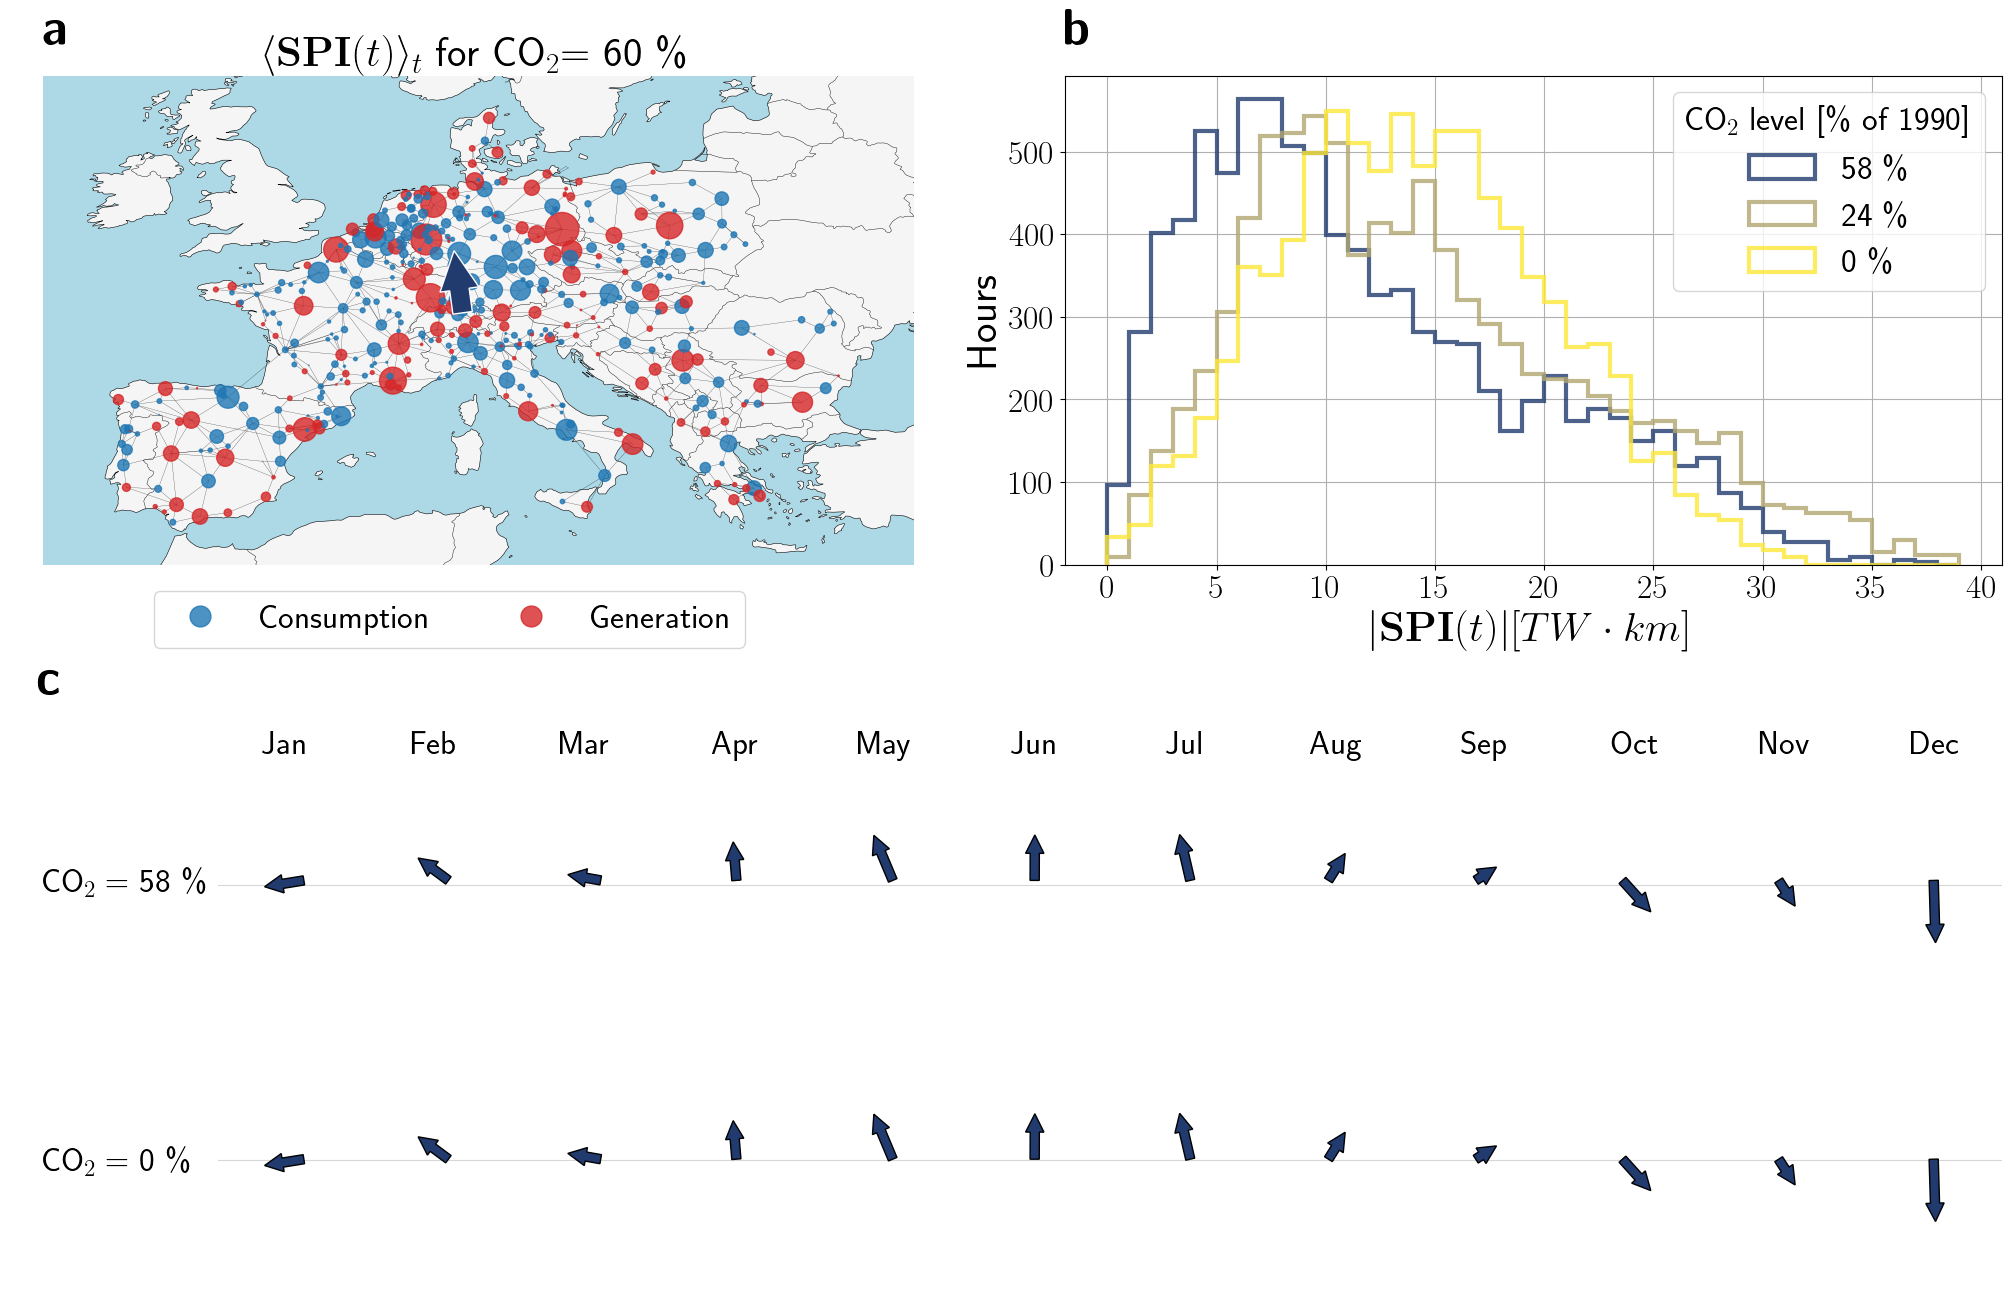

In [ ]:
print("Figure 3")

mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
labels = [[r'\textbf{a}', r'\textbf{b}'], [
    r'\textbf{c}', r'\textbf{d}', r'\textbf{e}', r'\textbf{f}']]

f = plt.figure(figsize=(20, 13), constrained_layout=True)
gs0= GridSpec(2,1, figure=f, hspace=0.9) # outer grid
gs1 = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs0[0])
axs_probs = f.add_subplot(gs1[0], projection=ccrs.PlateCarree())
ax2 = f.add_subplot(gs1[1])
gs2 = GridSpecFromSubplotSpec(3, 13, subplot_spec=gs0[1], hspace=0)
# axs_leg = f.add_subplot(gs0[0,0])
# axs_leg.axis('off')
axs_co2_0 = f.add_subplot(gs2[0, 0])
axs_co2_1 = f.add_subplot(gs2[1, 0])
axs_co2_0.axis('off')
axs_co2_1.axis('off')

axs_primary = [f.add_subplot(gs2[0, i+1], projection=ccrs.PlateCarree())
       for i in range(12)]
axs_secondary = [f.add_subplot(gs2[1, i+1], projection=ccrs.PlateCarree())
        for i in range(12)]
axs_tertiary = [f.add_subplot(gs2[2, i+1], projection=ccrs.PlateCarree())
        for i in range(12)]


##########  panel a : Mean SPI on map for 60% co2 level  ###################

resolution = "50m"
color_geomap = {'ocean': 'lightblue', 'land': 'whitesmoke'}

axs_probs.add_feature(cartopy.feature.LAND.with_scale(resolution),
               facecolor=color_geomap['land'])
axs_probs.add_feature(cartopy.feature.OCEAN.with_scale(resolution),
               facecolor=color_geomap['ocean'])
axs_probs.coastlines(linewidth=0.4, zorder=2, resolution=resolution)
border = cartopy.feature.BORDERS.with_scale(resolution)
axs_probs.add_feature(border, linewidth=0.3)
cmap = plt.get_cmap('cividis_r')
position_vector = np.array([pos[n] for n in nx_graph.nodes()])
mean_pos = [np.mean(position_vector[:, 0]), np.mean(position_vector[:, 1])]


nx.draw_networkx_edges(nx_graph,
                       pos,
                       ax=axs_probs,
                       alpha=0.8,
                       width=0.2)

scale_factor = 2e4

# current_vec = np.mean(dipole_vector, axis=2)
# use average weighted by snapshot weight
current_vec = np.average(dipole_vector, weights=network.snapshot_weightings.generators, axis=2)
vec = weighted_mean_consumption_vector
plot_co2ls = [0.6]

for i, level in enumerate(plot_co2ls):

    ind = np.where(np.round(co2ls, 2) == level)[0][0]

    node_colours = ['tab:red' if vec[ind, i] <
                    0 else 'tab:blue' for i in range(len(nx_graph.nodes()))]

    nx.draw_networkx_nodes(nx_graph,
                           pos,
                           ax=axs_probs,
                           node_size=np.abs(vec[ind])/30,
                           node_color=node_colours,
                           alpha=0.8)

    axs_probs.arrow(mean_pos[0],
             mean_pos[1],
             current_vec[ind, 0]/scale_factor,
             current_vec[ind, 1]/scale_factor,
             head_width=2.0,
             width=1.0,
             head_length=2.0,
            #  alpha  = 1,
             facecolor=cmap(ind/len(co2ls)),
            #  facecolor="cmap(ind/len(co2ls))",
             edgecolor="white",
             zorder=np.inf)
    axs_probs.axis('off')


# add legend

blue_circle = mlines.Line2D([], [], color='tab:blue', marker='o', linestyle='None',
                          markersize=15, label='Consumption', alpha=0.8)
red_circle = mlines.Line2D([], [], color='tab:red', marker='o', linestyle='None',
                          markersize=15, label='Generation', alpha=0.8)
axs_probs.legend(handles=[blue_circle,red_circle], bbox_to_anchor=(0.825,-0.02,0,0), ncol=2, fontsize=24)


########### panel b: Histogrms of SPI norm ##############

bins = np.arange(0, np.quantile(vec_norm, 0.9999), 1)  # np.arange(0,0.08,0.001)#


for i, level in enumerate(selected_co2ls[::-1]):

    # weighted_vec_norm = np.repeat(vec_norm[np.where(co2ls == level)[0][0],:], network.snapshot_weightings.generators.values.astype(int))
    
    ind = np.where(co2ls == level)[0][0]
    ax2.hist(
            # weighted_vec_norm,
            vec_norm[ind],
            weights=network.snapshot_weightings.generators.values.astype(int),
             bins=bins,
             histtype='step',
             label='{} \%'.format(int(get_actual_co2_level(level)*100)),
             linewidth=3,
             color=cmap(ind/len(co2ls)),
             #density=True,
             alpha=0.8)
leg=ax2.legend(fontsize=24, title=r'CO$_2$ level [\% of 1990]')
plt.setp(leg.get_title(),fontsize=24)
ax2.tick_params(axis='both', which='both', labelsize=24)
ax2.set_xlabel(r'$|\mathbf{SPI}(t)| [TW\cdot km]$', fontsize=30)
ax2.set_ylabel('Hours', fontsize=30)
ax2.grid(True)
ax2.yaxis.offsetText.set_fontsize(24)

############   panel c: Seasonal dependency of SPI vectors ##################

old_ind = 0
# co2lvls_spi_plot = [0.6, 0.0]
for current_level in target_levels:
    for j in range(12):

        new_ind = old_ind + \
            len(network.snapshots[network.snapshots.month == int(j+1)])

        ind = np.where(co2ls == current_level)[0][0]

        current_vec_0 = np.median(np.repeat(dipole_vector[ind, 0, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
        current_vec_1 = np.median(np.repeat(dipole_vector[ind, 1, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
        # for mean use np.average with weights

        axs_primary[j].arrow(mean_pos[0],
                                        mean_pos[1],
                                        current_vec_0/scale_factor,
                                        current_vec_1/scale_factor,
                                        head_width=2.0,
                                        width=1.0,
                                        head_length=2.0,
                                        #alpha  = .8,
                                        facecolor=cmap(ind/len(co2ls)))


        
        current_level = co2lvls_spi_plot[1]

        ind = np.where(co2ls == current_level)[0][0]

        current_vec_0 = np.median(np.repeat(dipole_vector[ind, 0, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
        current_vec_1 = np.median(np.repeat(dipole_vector[ind, 1, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
        axs_secondary[j].arrow(mean_pos[0],
                                        mean_pos[1],
                                        current_vec_0/scale_factor,
                                        current_vec_1/scale_factor,
                                        head_width=2.0,
                                        width=1.0,
                                        head_length=2.0,
                                        #alpha  = .8,
                                        facecolor=cmap(ind/len(co2ls)))
        
        
        axs_primary[j].axis('off')
        axs_secondary[j].axis('off')
        
        axs_primary[j].set_ylim([31.707498915424157, 60.29928495567561])
        axs_secondary[j].set_ylim([31.707498915424157, 60.29928495567561])

        old_ind = new_ind

# common grid behind spi vectors
axs_grid = f.add_subplot(gs2[:,1:], zorder=-1)
for _, spine in axs_grid.spines.items():
    spine.set_visible(False)
axs_grid.tick_params(labelleft=False, labelbottom=False, bottom=False, left=False, right=False )
axs_grid.set_yticks([0.26, 0.77])
#axs_grid.set_xlim([0,12])
#axs_grid.set_xticks(np.arange(1,12)-0.2)
axs_grid.grid(axis='y', alpha=0.5)



###########  panel labels ###################

ax2.text(0, 1+0.09,
         labels[0][1],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax2.transAxes)

axs_probs.text(0, 1+0.09,
        labels[0][0],
        fontsize=36,
        weight='bold',
        verticalalignment='center',
        transform=axs_probs.transAxes)

axs_co2_0.text(0.2, 1+0.3,
                    labels[1][0],
                    fontsize=36,
                    weight='bold',
                    verticalalignment='center',
                    transform=axs_co2_0.transAxes)

# axs_co2.text(0.5, 0.25, r'\textbf{c}', fontsize=36,
#                     weight='bold',
#                     verticalalignment='center',)#, rotation=90, horizontalalignment='center')
# axs_co2_0.text(0.5, 0.25, r'\textbf{c}', fontsize=24, rotation=90, horizontalalignment='center')
axs_co2_0.text(0.25, 0.5, rf'CO$_2 =$ {int(get_actual_co2_level(co2lvls_spi_plot[0])*100)} \%', fontsize=24, rotation=0, horizontalalignment='left')
axs_co2_1.text(0.25, 0.5, rf'CO$_2 =$ {int(get_actual_co2_level(co2lvls_spi_plot[1])*100)} \%', fontsize=24, rotation=0, horizontalalignment='left')
axs_co2_0.axis('off')

axs_probs.set_title(r'$\langle \mathbf{SPI}(t)\rangle_t$ for CO$_2$= 60 \%', fontsize=30)


for j in range(12):
    axs_primary[j].set_title(network.snapshots[network.snapshots.month == j+1][0].month_name()[:3],
                                       fontsize=24,
                                       pad=0)
# plt.savefig(save_path+'inital_grid_situation.pdf',bbox_inches = 'tight')

# Figure 7: line failures

## split likelihood

Note: These are the likelihoods for ANY split that occured, i.e., also those with only 1 or 2 nodes being split off. Should we keep it like this?

Important: When setting vmin larger then the minimum probability, then edges with likelihood below vmin appear as gray, which might be confused with a line that never leads to a blackout. So: Check vmin/vmax configuration and maybe explain in figure legend. 

In [ ]:
edge_likelihoods_primary = pickle.load(
    open(path_to_vis_results_sclopf+f'edge_likelihoods_primary_all_co2ls_n{n_nodes}.pickle', 'rb'))
edge_likelihoods_secondary = pickle.load(
    open(path_to_vis_results_sclopf+f'edge_likelihoods_secondary_all_co2ls_n{n_nodes}.pickle', 'rb'))


In [ ]:
##### setup figure #####
f = plt.figure(figsize=(21, 10))
gs = GridSpec(1, 2, figure=f, width_ratios=[3, 0.05], wspace=-0.02)
gs_maps = GridSpecFromSubplotSpec(2, 3, subplot_spec=gs[0], wspace=-0.1, hspace=-0.1)
axs_primary = [f.add_subplot(gs_maps[0, i]) for i in range(3)]
axs_secondary = [f.add_subplot(gs_maps[1, i]) for i in range(3)]
gs_colorbars = GridSpecFromSubplotSpec(5, 1, subplot_spec=gs[1], height_ratios=[0.2, 1, 0.2, 1, 0.2])
axs_colorbars = [f.add_subplot(gs_colorbars[i]) for i in [1, 3]]
# f.subplots_adjust(hspace=-0.1, wspace=0.0)
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

##### setup parameters #####
labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']
vmaxvals = []
vminvals = []

#### Primary failures ######

cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
cmap.set_under('gainsboro', 1.0)

for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    # Load likelihoods as dictionary and transform into array
    c_H_p = [edge_likelihoods_primary[level][(u, v)] for u, v in nx_graph.edges()]
    c_H_p_log = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in c_H_p])

    print('Min val prim: {:e}'.format(np.amin(np.array(c_H_p)[np.array(c_H_p)>1e-12])))
    print('Max val prim: {:e}'.format(np.amax(np.array(c_H_p)[np.array(c_H_p)>1e-12])))
    
    vmax = 1e-3
    # vmax = 10**max(c_H_p_log)
    vmin =  1e-6

    nodes = nx.draw_networkx_nodes(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                node_color='black',
                                node_size=0)

    edges = nx.draw_networkx_edges(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                edge_color=c_H_p_log,
                                width=3.5,
                                edge_cmap=cmap,
                                edge_vmin=np.log10(vmin),
                                edge_vmax=np.log10(vmax))

    axs_primary[count].axis('off')


# cbar_ax = f.add_axes([0.9, 0.57, 0.005, 0.25]) # f.add_axes([0.89, 0.35, 0.005, 0.45])
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.LogNorm(vmin=vmin, vmax=vmax))
cb = f.colorbar(sm, cax=axs_colorbars[0])
cb.ax.tick_params(labelsize=26, width=1.0, which='both')
axs_colorbars[0].set_title(r'$\langle p_{\ell}^{\text{p}}\rangle$',
             fontsize=25,
             weight='bold',
             verticalalignment='center',
             pad=20)

###### Secondary failures #####

cmap = copy.copy(mpl.cm.get_cmap("viridis_r"))
cmap.set_under('gainsboro', 1.0)

for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    # Load likelihoods as dictionary and transform into array
    c_H_s = [edge_likelihoods_secondary[level][(u, v)] for u, v in nx_graph.edges()]
    c_H_s_log = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in c_H_s])
    
    print('Min val sec: {:e}'.format(np.amin(np.array(c_H_s)[np.array(c_H_s)>1e-12])))
    print('Max val sec: {:e}'.format(np.amax(np.array(c_H_s)[np.array(c_H_s)>1e-12])))
    # vmax = 1e-3
    # vmax = 10**max(c_H_s_log)
    vmax = 1e-3
    vmin = 1e-5
    vmaxvals.append(vmax)
    vminvals.append(vmin)

    nodes = nx.draw_networkx_nodes(nx_graph,
                                   pos=pos,
                                   ax=axs_secondary[count],
                                   node_color='black',
                                   node_size=0)

    edges = nx.draw_networkx_edges(nx_graph,
                                   pos=pos,
                                   ax=axs_secondary[count],
                                   edge_color=c_H_s_log,
                                   width=3.5,
                                   edge_cmap=cmap,
                                   edge_vmin=np.log10(vmin),
                                   edge_vmax=np.log10(vmax))

    axs_secondary[count].axis('off')

    axs_primary[count].set_title(r'CO$_2 =$ ' + '{} \%'.format(int(co2l*100)), fontsize=28)
    axs_primary[count].text(0+0.1, 1+0.05,
                    labels[count],
                    fontsize=30,
                    weight='bold',
                    verticalalignment='center',
                    transform=axs_primary[count].transAxes)


# cbar_ax = f.add_axes([0.9, 0.19, 0.005, 0.25]) # f.add_axes([0.89, 0.35, 0.005, 0.45])
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.LogNorm(vmin=vmin, vmax=vmax))
cb = f.colorbar(sm, cax=axs_colorbars[1])
# cb.set_ticks([1e-5,1e-4, 1e-3, vmax], labels= [r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$',r'$1.5\cdot10^{-3}$'])
cb.set_ticks([1e-5,1e-4, 1e-3], labels= [r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$'])
cb.ax.tick_params(labelsize=26, width=1.0, which='major')
axs_colorbars[1].set_title(r'$\langle p_{\ell}^{\textrm{s}}\rangle$',
             fontsize=25,
             weight='bold',
             verticalalignment='center',
             pad=20)
print(np.max(vmaxvals), np.min(vminvals))


plt.savefig(save_path+'line_failure_probs.pdf',bbox_inches = 'tight')

In [ ]:
##### setup figure #####
f = plt.figure(figsize=(21, 10))
gs = GridSpec(1, 2, figure=f, width_ratios=[3, 0.05], wspace=-0.02)
gs_maps = GridSpecFromSubplotSpec(2, 3, subplot_spec=gs[0], wspace=-0.1, hspace=-0.1)
axs_primary = [f.add_subplot(gs_maps[0, i]) for i in range(3)]
axs_secondary = [f.add_subplot(gs_maps[1, i]) for i in range(3)]
gs_colorbars = GridSpecFromSubplotSpec(5, 1, subplot_spec=gs[1], height_ratios=[0.2, 1, 0.2, 1, 0.2])
axs_colorbars = [f.add_subplot(gs_colorbars[i]) for i in [1, 3]]
# f.subplots_adjust(hspace=-0.1, wspace=0.0)
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
level
##### setup parameters #####
labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']
vmaxvals = []
vminvals = []

#### Primary failures ######

cmap = copy.copy(mpl.cm.get_cmap("magma_r"))
cmap.set_under('gainsboro', 1.0)

probs_all = np.concatenate([np.array(list(edge_likelihoods_primary[level].values())) for level in selected_co2ls])
vmin = 0
vmax = probs_all.max()

for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    # Load likelihoods as dictionary and transform into array
    c_H_p = [edge_likelihoods_primary[level][(u, v)] for u, v in nx_graph.edges()]
    c_H_p_log = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in c_H_p])

    print('Min val prim: {:e}'.format(np.amin(np.array(c_H_p)[np.array(c_H_p)>1e-12])))
    print('Max val prim: {:e}'.format(np.amax(np.array(c_H_p)[np.array(c_H_p)>1e-12])))
    
    # vmax = 1e-3
    # # vmax = 10**max(c_H_p_log)
    # vmin =  1e-6

    nodes = nx.draw_networkx_nodes(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                node_color='black',
                                node_size=0)

    edges = nx.draw_networkx_edges(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                edge_color=c_H_p,
                                width=3.5,
                                edge_cmap=cmap,
                                edge_vmin=vmin,
                                edge_vmax=vmax)

    axs_primary[count].axis('off')


# cbar_ax = f.add_axes([0.9, 0.57, 0.005, 0.25]) # f.add_axes([0.89, 0.35, 0.005, 0.45])
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.Normalize(vmin=vmin, vmax=vmax))
cb = f.colorbar(sm, cax=axs_colorbars[0])
cb.ax.tick_params(labelsize=26, width=1.0, which='both')
axs_colorbars[0].set_title(r'$\langle p_{\ell}^{\text{p}}\rangle$',
             fontsize=25,
             weight='bold',
             verticalalignment='center',
             pad=20)

###### Secondary failures #####

cmap = copy.copy(mpl.cm.get_cmap("magma_r"))
cmap.set_under('gainsboro', 1.0)

# vmax = 1e-3
# vmin = 1e-5

probs_all = np.concatenate([np.array(list(edge_likelihoods_secondary[level].values())) for level in selected_co2ls])
vmin = 0
vmax = probs_all.max()


for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    # Load likelihoods as dictionary and transform into array
    c_H_s = [edge_likelihoods_secondary[level][(u, v)] for u, v in nx_graph.edges()]
    c_H_s_log = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in c_H_s])
    
    print('Min val sec: {:e}'.format(np.amin(np.array(c_H_s)[np.array(c_H_s)>1e-12])))
    print('Max val sec: {:e}'.format(np.amax(np.array(c_H_s)[np.array(c_H_s)>1e-12])))
    # vmax = 1e-3
    # vmax = 10**max(c_H_s_log)
    # vmax = 1e-3
    # vmin = 1e-5
    # vmaxvals.append(vmax)
    # vminvals.append(vmin)

    nodes = nx.draw_networkx_nodes(nx_graph,
                                   pos=pos,
                                   ax=axs_secondary[count],
                                   node_color='black',
                                   node_size=0)

    edges = nx.draw_networkx_edges(nx_graph,
                                   pos=pos,
                                   ax=axs_secondary[count],
                                   edge_color=c_H_s,
                                   width=3.5,
                                   edge_cmap=cmap,
                                   edge_vmin=vmin,
                                   edge_vmax=vmax)

    axs_secondary[count].axis('off')

    axs_primary[count].set_title(r'CO$_2 =$ ' + '{} \%'.format(int(co2l*100)), fontsize=28)
    axs_primary[count].text(0+0.1, 1+0.05,
                    labels[count],
                    fontsize=30,
                    weight='bold',
                    verticalalignment='center',
                    transform=axs_primary[count].transAxes)


# cbar_ax = f.add_axes([0.9, 0.19, 0.005, 0.25]) # f.add_axes([0.89, 0.35, 0.005, 0.45])
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.Normalize(vmin=vmin, vmax=vmax))
cb = f.colorbar(sm, cax=axs_colorbars[1])
# cb.set_ticks([1e-5,1e-4, 1e-3, vmax], labels= [r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$',r'$1.5\cdot10^{-3}$'])
# cb.set_ticks([1e-5,1e-4, 1e-3], labels= [r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$'])
cb.ax.tick_params(labelsize=26, width=1.0, which='major')
axs_colorbars[1].set_title(r'$\langle p_{\ell}^{\textrm{s}}\rangle$',
             fontsize=25,
             weight='bold',
             verticalalignment='center',
             pad=20)
# print(np.max(vmaxvals), np.min(vminvals))


plt.savefig(save_path+'line_failure_probs_linear.pdf',bbox_inches = 'tight')

inspect ration between primary and secondary failure probabilities

In [ ]:
level = 0.0
c_H_p = np.array([edge_likelihoods_primary[level][(u, v)] for u, v in nx_graph.edges()])
c_H_s = np.array([edge_likelihoods_secondary[level][(u, v)] for u, v in nx_graph.edges()])
ratio = c_H_s/c_H_p
plt.hist(ratio)#, bins=np.logspace(-3, 3, 50))

In [ ]:
##### setup figure #####
f = plt.figure(figsize=(21, 10))
gs = GridSpec(1, 2, figure=f, width_ratios=[3, 0.05], wspace=-0.02)
gs_maps = GridSpecFromSubplotSpec(2, 3, subplot_spec=gs[0], wspace=-0.1, hspace=-0.1)
axs_primary = [f.add_subplot(gs_maps[0, i]) for i in range(3)]
# axs_secondary = [f.add_subplot(gs_maps[1, i]) for i in range(3)]
gs_colorbars = GridSpecFromSubplotSpec(5, 1, subplot_spec=gs[1], height_ratios=[0.2, 1, 0.2, 1, 0.2])
axs_colorbars = [f.add_subplot(gs_colorbars[i]) for i in [1, 3]]
# f.subplots_adjust(hspace=-0.1, wspace=0.0)
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

##### setup parameters #####
labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']
vmaxvals = []
vminvals = []

#### Primary failures ######

cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
cmap.set_under('gainsboro', 1.0)

for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    # Load likelihoods as dictionary and transform into array
    c_H_p = [edge_likelihoods_primary[level][(u, v)] for u, v in nx_graph.edges()]
    c_H_p_sec = [edge_likelihoods_secondary[level][(u, v)] for u, v in nx_graph.edges()]
    c_H_p = [a/b if b!=0 else 0 for a,b in zip(c_H_p_sec,c_H_p)]
    c_H_p_log = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in c_H_p])

    print('Min val prim: {:e}'.format(np.amin(np.array(c_H_p)[np.array(c_H_p)>1e-12])))
    print('Mac_H_p_secx val prim: {:e}'.format(np.amax(np.array(c_H_p)[np.array(c_H_p)>1e-12])))
    
    # vmax = 1e-3
    # # vmax = 10**max(c_H_p_log)
    # vmin =  1e-6
    vmax = 10**max(c_H_p_log)
    vmin =  vmax * 1e-5

    nodes = nx.draw_networkx_nodes(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                node_color='black',
                                node_size=0)

    edges = nx.draw_networkx_edges(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                edge_color=c_H_p_log,
                                width=3.5,
                                edge_cmap=cmap,
                                edge_vmin=np.log10(vmin),
                                edge_vmax=np.log10(vmax))

    axs_primary[count].axis('off')


# cbar_ax = f.add_axes([0.9, 0.57, 0.005, 0.25]) # f.add_axes([0.89, 0.35, 0.005, 0.45])
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.LogNorm(vmin=vmin, vmax=vmax))
cb = f.colorbar(sm, cax=axs_colorbars[0])
cb.ax.tick_params(labelsize=26, width=1.0, which='both')
axs_colorbars[0].set_title(r'$\langle p_{\ell}^{\text{p}}\rangle$',
             fontsize=25,
             weight='bold',
             verticalalignment='center',
             pad=20)

# ###### Secondary failures #####

# cmap = copy.copy(mpl.cm.get_cmap("viridis_r"))
# cmap.set_under('gainsboro', 1.0)

# for count, co2l in enumerate(selected_co2ls[::-1]):

#     level = np.round(co2l, 2)
    
#     # Load likelihoods as dictionary and transform into array
#     c_H_s = [edge_likelihoods_secondary[level][(u, v)] for u, v in nx_graph.edges()]
#     c_H_s_log = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in c_H_s])
    
#     print('Min val sec: {:e}'.format(np.amin(np.array(c_H_s)[np.array(c_H_s)>1e-12])))
#     print('Max val sec: {:e}'.format(np.amax(np.array(c_H_s)[np.array(c_H_s)>1e-12])))
#     # vmax = 1e-3
#     # vmax = 10**max(c_H_s_log)
#     vmax = 1e-3
#     vmin = 1e-5
#     vmaxvals.append(vmax)
#     vminvals.append(vmin)

#     nodes = nx.draw_networkx_nodes(nx_graph,
#                                    pos=pos,
#                                    ax=axs_secondary[count],
#                                    node_color='black',
#                                    node_size=0)

#     edges = nx.draw_networkx_edges(nx_graph,
#                                    pos=pos,
#                                    ax=axs_secondary[count],
#                                    edge_color=c_H_s_log,
#                                    width=3.5,
#                                    edge_cmap=cmap,
#                                    edge_vmin=np.log10(vmin),
#                                    edge_vmax=np.log10(vmax))

#     axs_secondary[count].axis('off')

#     axs_primary[count].set_title(r'CO$_2 =$ ' + '{} \%'.format(int(co2l*100)), fontsize=28)
#     axs_primary[count].text(0+0.1, 1+0.05,
#                     labels[count],
#                     fontsize=30,
#                     weight='bold',
#                     verticalalignment='center',
#                     transform=axs_primary[count].transAxes)


# # cbar_ax = f.add_axes([0.9, 0.19, 0.005, 0.25]) # f.add_axes([0.89, 0.35, 0.005, 0.45])
# sm = plt.cm.ScalarMappable(
#     cmap=cmap, norm=mplcolors.LogNorm(vmin=vmin, vmax=vmax))
# cb = f.colorbar(sm, cax=axs_colorbars[1])
# # cb.set_ticks([1e-5,1e-4, 1e-3, vmax], labels= [r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$',r'$1.5\cdot10^{-3}$'])
# cb.set_ticks([1e-5,1e-4, 1e-3], labels= [r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$'])
# cb.ax.tick_params(labelsize=26, width=1.0, which='major')
# axs_colorbars[1].set_title(r'$\langle p_{\ell}^{\textrm{s}}\rangle$',
#              fontsize=25,
#              weight='bold',
#              verticalalignment='center',
#              pad=20)
# cb.ax.yaxis.set_ticks([1e-6,1e-4,1e-2,1])

# minortcs = np.arange(1,10,1)
# minortcs = np.array([minortcs*1e-7,minortcs*1e-6,minortcs*1e-5,minortcs*1e-4,minortcs*1e-3]).flatten()
# minortcs = minortcs[(minortcs>vmin) & (minortcs<vmax)]
# cb.ax.yaxis.set_ticks(minortcs, minor=True)

# print(np.max(vmaxvals), np.min(vminvals))


# plt.savefig(save_path+'fig7.pdf',bbox_inches = 'tight')

## loss of load

In [ ]:
try:
    with open(path_to_vis_results_sclopf + f'loss_by_trigger_lvls.pickle', 'rb') as f:
        loss_by_trigger_lvls = pickle.load(f)
except FileNotFoundError:
    loss_by_trigger_lvls = {}
    for co2l in selected_co2ls:
        split_significance = pd.read_csv(path_to_evaluation_results_sclopf + f"split_properties_Co2L{co2l}_n{n_nodes}.csv", index_col=0)
        trigger0 = split_significance.loc[:,["lost_load_share_blackout","init_failure_0"],].groupby("init_failure_0").sum()
        trigger1 = split_significance.loc[:,["lost_load_share_blackout","init_failure_1"],].groupby("init_failure_1").sum()
        trigger1.rename_axis("trigger", inplace=True)
        trigger0.rename_axis("trigger", inplace=True)
        loss_by_trigger = pd.Series(index=list(range(n_lines)), data=0)
        loss_by_trigger.rename_axis("trigger", inplace=True)
        loss_by_trigger = loss_by_trigger.add(trigger0.lost_load_share_blackout, fill_value=0)
        loss_by_trigger = loss_by_trigger.add(trigger1.lost_load_share_blackout, fill_value=0)
        
        loss_by_trigger_lvls[co2l] = loss_by_trigger

    with open(path_to_vis_results_sclopf + f'loss_by_trigger_lvls.pickle', 'wb') as f:
        pickle.dump(loss_by_trigger_lvls, f, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
##### setup figure #####
f = plt.figure(figsize=(21, 7.05))
gs = GridSpec(1, 3, figure=f, width_ratios=[1,1,1], wspace=-0.02)
axs_primary = [f.add_subplot(gs[i]) for i in range(3)]
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

##### setup parameters #####
labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']

cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
cmap.set_under("gainsboro", 1.0)

# alternative to set values have only bridges in grey
# cmap.set_under(cmap(0), 1.0)

for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    loss_per_failure = loss_by_trigger_lvls[co2l].values/n_snapshots/(n_lines-1)
    loss_log_per_failure = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in loss_per_failure])
    
    # alternative to set values have only bridges in grey
    # log_min = np.log10(np.min(loss_per_failure[loss_per_failure!=0]))
    # loss_log_per_failure = np.array([np.log10(x) if x > log_min else -np.inf for x in loss_per_failure])
    
    vmax = 10**max(loss_log_per_failure)
    vmin =  vmax * 1e-3

    nodes = nx.draw_networkx_nodes(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                node_color='black',
                                node_size=0)

    edges = nx.draw_networkx_edges(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                edge_color=loss_log_per_failure,
                                width=3.5,
                                edge_cmap=cmap,
                                edge_vmin=np.log10(vmin),
                                edge_vmax=np.log10(vmax))

    axs_primary[count].axis('off')

    axs_primary[count].set_title(r'CO$_2 =$ ' + '{} \%'.format(int(co2l*100)), fontsize=28, y=0.95)
    axs_primary[count].text(0+0.1, 1,
                    labels[count],
                    fontsize=30,
                    weight='bold',
                    verticalalignment='center',
                    transform=axs_primary[count].transAxes)

sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.LogNorm(vmin=vmin, vmax=vmax))
# add colorbar axis
axs_colorbars = [f.add_axes([0.9, 0.3, 0.01, 0.4])]
cb = f.colorbar(sm, cax=axs_colorbars[0])
cb.ax.tick_params(labelsize=26, width=1.0, which='both')
axs_colorbars[0].set_title(
                        #    r'$\langle L_{\ell}\rangle$',
                           r'$\langle R_{\ell}^{\text{p}}\rangle$',
             fontsize=25,
             weight='bold',
             verticalalignment='center',
             pad=20)
# plt.tight_layout()
plt.savefig(save_path+'loss_by_trigger_map.pdf',bbox_inches = 'tight')

In [ ]:
##### setup figure #####
f = plt.figure(figsize=(21, 7.05))
gs = GridSpec(1, 3, figure=f, width_ratios=[1,1,1], wspace=-0.02)
axs_primary = [f.add_subplot(gs[i]) for i in range(3)]
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

##### setup parameters #####
labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']

cmap = copy.copy(mpl.cm.get_cmap("magma_r"))
cmap.set_under("gainsboro", 1.0)

# alternative to set values have only bridges in grey
# cmap.set_under(cmap(0), 1.0)

probs_all = np.concatenate([np.array(loss_by_trigger_lvls[co2l].values/n_snapshots/(n_lines-1)) for level in selected_co2ls])
vmin = 0
vmax = probs_all.max()

for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    loss_per_failure = loss_by_trigger_lvls[co2l].values/n_snapshots/(n_lines-1)
    # loss_log_per_failure = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in loss_per_failure])
    
    # alternative to set values have only bridges in grey
    # log_min = np.log10(np.min(loss_per_failure[loss_per_failure!=0]))
    # loss_log_per_failure = np.array([np.log10(x) if x > log_min else -np.inf for x in loss_per_failure])
    
    # vmax = 10**max(loss_log_per_failure)
    # vmin =  vmax * 1e-3

    nodes = nx.draw_networkx_nodes(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                node_color='black',
                                node_size=0)

    edges = nx.draw_networkx_edges(nx_graph,
                                pos=pos,
                                ax=axs_primary[count],
                                edge_color=loss_per_failure,
                                width=3.5,
                                edge_cmap=cmap,
                                edge_vmin=vmin,
                                edge_vmax=vmax)

    axs_primary[count].axis('off')

    axs_primary[count].set_title(r'CO$_2 =$ ' + '{} \%'.format(int(co2l*100)), fontsize=28, y=0.95)
    axs_primary[count].text(0+0.1, 1,
                    labels[count],
                    fontsize=30,
                    weight='bold',
                    verticalalignment='center',
                    transform=axs_primary[count].transAxes)

sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.Normalize(vmin=vmin, vmax=vmax))
# add colorbar axis
axs_colorbars = [f.add_axes([0.9, 0.3, 0.01, 0.4])]
cb = f.colorbar(sm, cax=axs_colorbars[0])
cb.ax.tick_params(labelsize=26, width=1.0, which='both')
axs_colorbars[0].set_title(
                           r'$\langle R_{\ell}^{\text{p}}\rangle$',
             fontsize=25,
             weight='bold',
             verticalalignment='center',
             pad=20)
# plt.tight_layout()
plt.savefig(save_path+'loss_by_trigger_map_linear.pdf',bbox_inches = 'tight')

# Nodal Blackout Prob

In [25]:
path_to_evaluation_results_sclopf + f"blackout_prob_dict_n{n_nodes}.pickle"

'/srv/data/jlange/power-system-split/no_extensions//results/sclopf/evaluation_results/blackout_prob_dict_n600.pickle'

In [33]:
try:
    with open(path_to_evaluation_results_sclopf + f"blackout_prob_dict_n{n_nodes}.pickle", "rb") as out:
        blackout_prob_dict = pickle.load(out)
    with open(path_to_evaluation_results_sclopf + f"edge_failure_prob_dict_n{n_nodes}.pickle", "rb") as out:
        edge_failure_prob_dict = pickle.load(out)
        
except FileNotFoundError:
    blackout_prob_dict = {}
    edge_failure_prob_dict = {}
    vmin_node = 1
    vmax_node = 0
    for target_level in selected_co2ls:
        print(target_level)
        
        path = (
                path_to_evaluation_results_sclopf
                + f"/indicator_vector_rocof_Co2L{target_level}_n{n_nodes}.pklz"
        )
        with gzip.open(path, "rb") as out:
            rocof_indicator_vectors = pickle.load(out)[-1]
        path = (
                path_to_evaluation_results_sclopf
                + f"/failed_edges_indicator_vector_Co2L{target_level}_n{n_nodes}.pklz"
        )
        with gzip.open(path, "rb") as out:
            failed_edges_indicator_vectors = pickle.load(out)[-1]

        weights = split_properties[split_properties.co2l==target_level].snapshot_weighting.values
        print(weights.shape, rocof_indicator_vectors.shape, failed_edges_indicator_vectors.shape)
        blackout_prob_dict[target_level] = (weights.reshape(1,-1) @  (rocof_indicator_vectors<-1)).squeeze()/num_failures_weighted
        
        edge_failure_prob_dict[target_level] = (weights.reshape(1,-1) @  failed_edges_indicator_vectors).squeeze()/num_failures_weighted
        
    with open(path_to_evaluation_results_sclopf + f"blackout_prob_dict_n{n_nodes}.pickle", "wb") as out:
        pickle.dump(blackout_prob_dict, out)
    with open(path_to_evaluation_results_sclopf + f"edge_failure_prob_dict_n{n_nodes}.pickle", "wb") as out:
        pickle.dump(edge_failure_prob_dict, out)


0.0
(4709980,) (4709980, 456) (4709980, 815)
0.2
(2801626,) (2801626, 456) (2801626, 815)
0.6
(1799795,) (1799795, 456) (1799795, 815)


In [1]:
path = (
        path_to_indicator_vectors_sclopf
        + f"/indicator_vector_rocof_Co2L{0.0}_n{400}.pklz"
)
with gzip.open(path, "rb") as out:
    rocof_indicator_vectors = pickle.load(out)[-1]

NameError: name 'path_to_indicator_vectors_sclopf' is not defined

level: 0.6
0.00021792993068726625
4.5446175699881095e-07
level: 0.2
0.00021852405630129408
2.2774076242189183e-05
level: 0.0
0.0004344432708246682
0.00021695339213137385


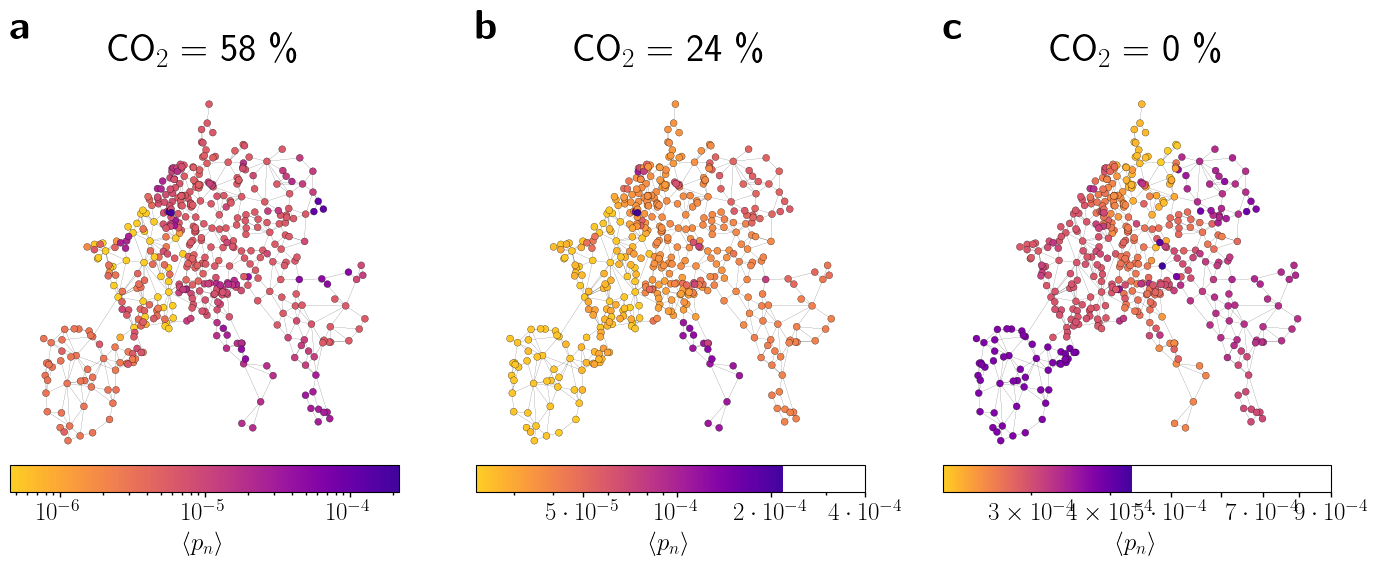

In [ ]:
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

f = plt.figure(figsize=(15.5*1.1, 5*1.1))

gs_maps = GridSpec(1, len(selected_co2ls), figure=f)
gs_lvls = []
for i, target_level in enumerate(selected_co2ls):
    gs_lvl = GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_maps[0, i], height_ratios=[15, 1], hspace=-0.05)
    gs_lvls.append(gs_lvl)

labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']

node_cmap = plt.get_cmap('plasma_r')
node_cmap = truncate_colormap(node_cmap, 0.1, 0.9, 1000)
node_cmap.set_under('gainsboro', 1.0)
node_cbar_label="blackout prob"

# vmax_node = -np.inf
# vmin_node = np.inf
# vmaxes = []

# for i,(gs_lvl,target_level) in enumerate(zip(gs_lvls,selected_co2ls[::-1])):
    
#     ax = f.add_subplot(gs_lvl[0])
#     ax_cbar = f.add_subplot(gs_lvl[1])

#     blackout_prob = blackout_prob_dict[target_level]
#     edge_failure_prob = edge_failure_prob_dict[target_level]
    
#     blackout_prob_log = np.array(
#         [np.log10(x) if x > 1e-12 else -np.inf for x in blackout_prob]
#     )
#     # vmax_node = blackout_prob.max()
#     # vmin_node = blackout_prob.min()
#     vmax_node = max(10**blackout_prob_log.max(), vmax_node)
#     vmin_node = min(10**blackout_prob_log.min(), vmin_node)
    
#     vmaxes.append(vmax_node)
#     # vmin_node = 10**blackout_prob_log.min()

# vmin_node = vmaxes[0]*1e-3

# vmin_node = 1e-4

for i,(gs_lvl,target_level) in enumerate(zip(gs_lvls,selected_co2ls[::-1])):
    
    ax = f.add_subplot(gs_lvl[0])
    ax_cbar = f.add_subplot(gs_lvl[1])

    blackout_prob = blackout_prob_dict[target_level]
    edge_failure_prob = edge_failure_prob_dict[target_level]
    
    blackout_prob_log = np.array(
        [np.log10(x) if x > 1e-12 else -np.inf for x in blackout_prob]
    )
    # vmax_node = blackout_prob.max()
    # vmin_node = blackout_prob.min()
    vmax_node = 10**blackout_prob_log.max()
    vmin_node = 10**blackout_prob_log.min()

    # vmin_node = vmax * 10e-1
    print(f"level: {target_level}")
    print(vmax_node)
    print(vmin_node)
    # vmax_node = 10e-1
    # vmin_node = 10e-8

    nodes = nx.draw_networkx_nodes(
        nx_graph,
        pos=pos,
        ax=ax,
        node_size=25,
        node_color=blackout_prob_log,
        cmap=node_cmap,
        vmax=np.log10(vmax_node),
        vmin=np.log10(vmin_node),

    )
    nodes.set_edgecolor("black")
    nodes.set_linewidth(0.2)

    edges = nx.draw_networkx_edges(
        nx_graph,
        pos=pos,
        ax=ax,
        width=0.1,
        edge_color="black",
    )
    
    ax.set_title(r'CO$_2 =$ ' + '{} \%'.format(int(get_actual_co2_level(target_level)*100)), fontsize=28)
    ax.text(0, 1+0.1,
                    labels[i],
                    fontsize=30,
                    weight='bold',
                    verticalalignment='center',
                    transform=ax.transAxes)
    
    # ax.set_title(f"CO2={int(target_level*100)}%", fontsize=24)
    ax.axis("off")

    sm = plt.cm.ScalarMappable(
        cmap=node_cmap, norm=mplcolors.LogNorm(vmin=vmin_node, vmax=vmax_node))
    cb = f.colorbar(sm, cax=ax_cbar, orientation="horizontal")
    if target_level==0.0:
        # ticks = ax_cbar.get_xticks()
        # ax_cbar.set_xticks(ticks, labels=["" for i in range(len(ticks))])
        # ax_cbar.set_xticks([i*1e-4 for i in range(5,10)], labels=["$5\cdot 10^{-4}$", "$6\cdot10^{-4}$","$7\cdot 10^{-4}$","$8\cdot 10^{-4}$", "$9\cdot 10^{-4}$"])
        ax_cbar.set_xticks([i*1e-4 for i in range(5,10)], labels=["$5\cdot 10^{-4}$", "","$7\cdot 10^{-4}$","", "$9\cdot 10^{-4}$"])
    elif target_level==0.2:
        ax_cbar.set_xticks([5e-5,1e-4,2e-4,4e-4], labels=["$5\cdot 10^{-5}$", "$10^{-4}$","$2\cdot 10^{-4}$","$4\cdot 10^{-4}$"])
    ax_cbar.set_xlabel(r'$\langle p_{n}\rangle$', fontsize=18, labelpad=5)
    ax_cbar.tick_params(labelsize=18, width=1.0, which='both')


f.savefig(save_path+'nodal_blackout_prob.pdf',bbox_inches = 'tight')

# Figure 5: split statistics

In [36]:
# co2ls = np.arange(0.1,0.81,0.1).round(1)
# selected_co2ls = np.array([0.1, 0.3, 0.6, 0.8])

# Load split component properties
component_props = pd.read_hdf(path_to_vis_results_sclopf + f'component_properties_all_n{n_nodes}.h5')
component_props.time_stamp = pd.to_datetime(component_props.time_stamp)
# indicator_vectors = np.load(path_to_vis_results + f'indicator_vectors_all_n400.npy').astype(bool)
split_props = split_properties
# split_vectors = np.load(path_to_vis_results + f'split_vectors_all_n400.npy')

split_props.lost_load_share_blackout = split_props.lost_load_share_blackout.astype(float)

0.0 99.93633489927221
0.1 99.88885253833715
0.2 99.5654873179431
0.3 99.5380692198787
0.4 99.50347896391402
0.5 98.90431495709187
0.6 96.64771291987574


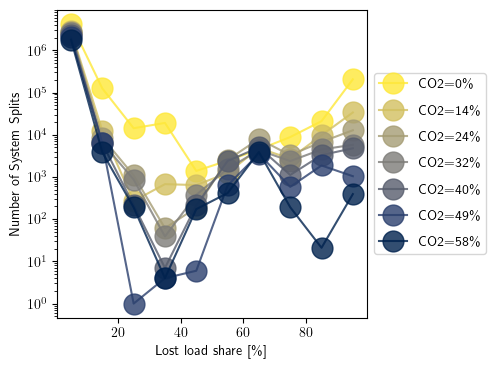

In [51]:
fig = plt.figure(figsize=(4,4))
cmap = plt.get_cmap("cividis")

bins = np.linspace(0, 100, 11)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
for co2l in co2ls[::-1]:
    vals = split_props[split_props.co2l==co2l].lost_load_share_blackout.values*100
    actual_lvl = get_actual_co2_level(co2l)
    color = cmap(np.where(actual_co2ls == actual_lvl)[0][0] / (len(actual_co2ls) - 1))
    print(co2l, vals.max())
    counts, _ = np.histogram(vals, bins=bins)
    plt.plot(bin_centers, counts, label=rf'CO2={int(actual_lvl*100)}\%', alpha=0.8, color=color, marker=".", markersize=30)
plt.xlabel(r'Lost load share [\%]')
plt.ylabel('Number of System Splits')
plt.yscale("log")
# plt.title('Lost load share distribution for different CO2 levels')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),labelspacing=1)
plt.savefig(save_path + 'lost_load_share_hist.pdf', bbox_inches='tight')

In [ ]:
cutoff = 1e4
bins=np.logspace(np.log10(1e-3),np.log10(cutoff), 20)
for co2l in selected_co2ls:
    component_props_rocof = component_props.rocof[component_props.co2l == co2l]
    component_props_rocof = component_props_rocof[component_props_rocof < 0]
    snapshot_weighting = component_props.snapshot_weighting[component_props_rocof.index]
    # component_props_rocof.loc[component_props_rocof>cutoff] = cutoff
    component_props_rocof.loc[component_props_rocof<-cutoff] = -cutoff
    plt.hist(-component_props_rocof.values, bins=bins, label=f'CO2L={co2l}', alpha=0.5, histtype='step',
    weights=snapshot_weighting,
    linewidth = 2,
    )
plt.gca().set_xscale("log")
plt.gca().set_yscale("log")
plt.legend()


In [ ]:
split_props.lost_load_share_blackout = split_props.lost_load_share_blackout.astype(float)
split_props["category"] = ""
split_props.loc[split_props.lost_load_share_blackout > 0.5, "category"] = "global_blackout"
split_props.loc[(split_props.lost_load_share_blackout < 0.5) & (split_props.lost_load_share_blackout > 0.01), "category"] = "local_blackout"
split_props.loc[(split_props.lost_load_share_blackout < 0.01) & (split_props.lost_load_share_blackout > 0.0), "category"] = "negligible"
split_props.loc[split_props.lost_load_share_blackout == 0.0, "category"] = "no_blackout"
# if ((split.rocof > -1) & (split.load_share > 0.99)).any():
#     split_props.loc[name, "category"] = "negligible"
# else:
#     split_props.loc[name, "category"] = "no_blackout"

In [ ]:
split_props.rename(columns={"neglidgeable_blackout": "negligible"}, inplace=True)

In [ ]:
split_props.columns

In [ ]:
#TODO: remove this when all splits were evaluated!!!
# Restricting analysis to minimum of available time steps

# n_steps_to_consider = component_props.groupby('co2l').apply(lambda x:x.time_stamp.unique().shape[0]).min()
# number_of_simulations = n_steps_to_consider*len(n_2_failures)
# component_props = component_props[pd.to_datetime(component_props.time_stamp)<network.snapshots[n_steps_to_consider]]
component_props["snapshot_weighting"] = network.snapshot_weightings.generators[component_props.time_stamp].values
# indicator_vectors = indicator_vectors[:component_props.shape[0]]

# split_props = split_props[pd.to_datetime(split_props.index.get_level_values('time_stamp'))<network.snapshots[n_steps_to_consider]]
# split_vectors = split_vectors[:split_props.shape[0]]

# n_steps_to_consider


split_props["snapshot_weighting"] = network.snapshot_weightings.generators[split_props.index.get_level_values(1)].values
weighted_split_props_dict = dict({co2l:{category: split_props.loc[(split_props.category==category) & (split_props.index.get_level_values(0)==co2l), "snapshot_weighting"].sum() for category in split_props.category.unique()} for co2l in co2ls})
# for index,row in split_props.iterrows():
#         weighted_split_props_dict[index[0]][row.category] += row.snapshot_weighting

* **negligible**: there is a component with with >99% load that survives
* **relevant split without blackout/ Non-severe**: Not negligible and not blackout.
* **locally severe/ local blackout**: blackout of <99% of CE load
* **globally severe/ global blackout**: Blackout of >99% of CE load.




In [ ]:
component_props[component_props.load_share>1/200]

In [ ]:
(component_props.load_share>1/200).mean()

In [ ]:
from cycler import cycler
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

fig = plt.figure(figsize=(9, 3.3))
gs = GridSpec(2, 1, figure=fig, hspace=0.6, height_ratios=[1,0.1])


# Panel c: split number and categories
n_cols = 3
gsTop = GridSpecFromSubplotSpec(1, n_cols, subplot_spec=gs[0,:], hspace=0, wspace=0.4)
gs_bottom = GridSpecFromSubplotSpec(1, n_cols, subplot_spec=gs[1,:])
ax1 = fig.add_subplot(gsTop[2])
ax1_legend = fig.add_subplot(gs_bottom[1:])

data0 = pd.DataFrame(weighted_split_props_dict).transpose()

data0 = data0.rename(columns={'global_blackout':'Global blackout','local_blackout':'Local blackout',
                            'no_blackout':'No blackout','negligible':'Negligible'})
# data0 = data0.rename(columns={'global_blackout':'Globally severe','local_blackout':'Locally severe',
#                             'no_blackout':'Non-severe','negligible':'Negligible'})

# data0 = data0.rename(str.upper().replace("_", " "))
data0 = data0.iloc[:, ::-1]

N = data0.shape[1]
# cc = plt.cycler("color", plt.cm.copper_r(np.linspace(0,1,N)))
cc = ["g", "blue", "brown", "black"]
color_dict = {"No blackout":"g", "Negligible":"blue", "Local blackout":"brown", "Global blackout":"black"}
style_dict = {"No blackout":":", "Negligible":"--", "Local blackout":"-.", "Global blackout":"-"}

linestyle_cycler = [':','--','-','-.']

for d, style, col in zip(cc, linestyle_cycler, data0.columns):
    data_series = data0[col]
    data_series[data_series==0.0] = np.nan
    data_series = data0[col].dropna()
    color = color_dict[col]
    ax1.plot(data_series.index*100, data_series.values, color=color, label=col, linestyle=style)
    # ax1.plot(data_series.index*100, data_series.values, color=d["color"], label=col)

ax1.set_yscale('log')
ax1.set_xlabel(r'CO$_2$ level [\% of 1990]')
ax1.set_ylabel('Number of split events')
ax1.invert_xaxis()

# Legend
# fig.tight_layout()
h, l = ax1.get_legend_handles_labels()
# ax1.get_legend().remove()
ax1_legend.legend(h[::-1], l[::-1], title='Split category', loc='center', ncols=4, columnspacing=0.5)
ax1_legend.axis("off")
# ax1.get_legend().remove()

# filter out very small components
# component_props_filtered = component_props[component_props.load_share>1/200]
component_props_filtered = component_props

# Panel b: Inertia histograms
cmap = plt.get_cmap('cividis_r')

ax2 = fig.add_subplot(gsTop[1])
ax2_legend = fig.add_subplot(gs_bottom[0])
rot_energy = component_props_filtered.rot_energy/1000
bins = np.linspace(rot_energy.min(),rot_energy.max(),15)
intertia_hist_vals = []
for co2l in selected_co2ls:
    vals = ax2.hist(rot_energy[component_props_filtered.co2l==co2l],
            weights=component_props_filtered.snapshot_weighting[component_props_filtered.co2l==co2l],
            bins=bins,
            histtype='step',
            label=r'{} \%'.format(int(100*co2l)),
            linewidth=3,
            color=cmap(np.where(co2ls == co2l)[0][0]/len(co2ls)),
            alpha=0.8,
            density=False)
    intertia_hist_vals.append(vals[0])
ax2.set_yscale('log')
ax2.set_xlabel('Rotational energy [GWs]')
ax2.set_ylabel('Number of split components')

# Panel a: power imbalance histograms

ax3 = fig.add_subplot(gsTop[0])
power_imbalance = component_props_filtered.power_imbalance/1000
bins = np.linspace(power_imbalance.min(),power_imbalance.max(),15)
chandles = []
for co2l in selected_co2ls:
    h= ax3.hist(power_imbalance[component_props_filtered.co2l==co2l],
            weights=component_props_filtered.snapshot_weighting[component_props_filtered.co2l==co2l],
            bins=bins,
            histtype='step',
            linewidth=3,
            label=r'{} \%'.format(int(100*co2l)),
            color=cmap(np.where(co2ls == co2l)[0][0]/len(co2ls)),
            alpha=0.8,
            density=False)
ax3.set_yscale('log')
ax3.set_ylabel('Number of split components')
ax3.set_xlabel('Power imbalance [GW]')
ax3.set_xticks(np.arange(-50,51,step=25))

# Pamel d: rocof histograms

# ax4 = fig.add_subplot(gsTop[3])
# rocof = component_props.rocof
# bins = np.linspace(rocof.min(),rocof.max(),15)
# chandles = []
# for co2l in selected_co2ls:
#     h= ax4.hist(rocof[component_props.co2l==co2lPower B],
#             weights=component_props.snapshot_weighting[component_props.co2l==co2l],
#             bins=bins,
#             histtype='step',
#             linewidth=3,
#             label=r'{} \%'.format(int(100*co2l)),
#             color=cmap(np.where(co2ls == co2l)[0][0]/len(co2ls)),
#             alpha=0.8,
#             density=False)
# ax4.set_yscale('log')
# ax4.set_ylabel('Number of split components')
# ax4.set_xlabel('RoCoF [Hz/s]')

# ax4 = fig.add_subplot(gsTop[3])
# data_hist = component_props[(component_props.co2l<0.7) & (component_props.rocof<-1)]
# cmap = plt.get_cmap('plasma_r')
# hist = ax4.hist2d(data_hist.co2l, data_hist.load_share,cmap=cmap, alpha=1, norm=mpl.colors.LogNorm(), bins=(7,20))#, cmin=1e3)
# cbar = plt.colorbar(hist[3])
# cbar.set_label('Count')
# left, right = ax4.get_xlim()
# width = right - left
# bar_width = width / len(data_hist.co2l.unique())
# ax4.set_xticks([bar_width/2 + bar_width*i for i in range(len(data_hist.co2l.unique()))], labels=[f"{int(100*co2)}" for co2 in co2ls])
# ax4.set_yticklabels((ax4.get_yticks()*100).astype(int))
# ax4.set_ylabel(r'Load share [\%]')
# ax4.set_xlabel(r'CO$_2$ level [\% of 1990]')
# ax4.set_xticklabels((100*co2ls).astype(int))
# ax4.invert_xaxis()
# # ax4.set_title(r'Split components with $|$RoCoF$|$ $<$ -1 Hz/s')
# ax4.set_title(r'RoCoF $<$ -1 Hz/s')
# # h, l = ax4.get_legend_handles_labels()
# # ax4_legend = fig.add_subplot(gs_bottom[3])
# # ax4_legend.legend(title=r'Split components with $|$RoCoF$|$ $<$ -1 Hz/s')
# # ax4_legend.axis("off")

# ax4.remove()

# h, l = ax4.get_legend_handles_labels()
h, l = ax2.get_legend_handles_labels()
# ax1.get_legend().remove()
ax2_legend.legend(h[::-1], l[::-1], title=r'CO$_2$ level [\% of 1990]', loc='center', ncols=3, columnspacing=0.5)
ax2_legend.axis("off")
# ax2.legend(bbox_to_anchor=(1,-0.35), ncols=4, title=r'CO$_2$ level [\% of 1990]')

# add title to subplots
# for ax,label in zip([ax1, ax2, ax3, ax4], ['a', 'b', 'c','d']):
for ax,label in zip([ax1, ax2, ax3], ['a', 'b', 'c']):
    # ax.set_title('')
    ax.text(0 -0.25, 1+0.1,
                    label,
                    fontsize=30,
                    weight='bold',
                    verticalalignment='center',
                    transform=ax.transAxes)

# plt.tight_layout()
# plt.savefig(save_path+'split_statistics_noHist.pdf',bbox_inches = 'tight')

# Line loading

## max load hist

In [9]:
# calculate line flows
cmap = plt.get_cmap('cividis_r')


# bins = np.arange(0, 2.0, 0.02)
bin_width = 0.02
bins = np.arange(0, 1.02, bin_width)


hist_vals = np.zeros((len(selected_co2ls), len(bins)-1))


for count, co2l in enumerate(selected_co2ls):

    network = data_handling.load_pypsa_network_from_path(path_to_pypsa_network_sclopf +
                        f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{co2l}-2920SEG.nc", True)

    indices = nx.get_edge_attributes(nx_graph, 'line_index')
    line_limits_dict = nx.get_edge_attributes(nx_graph, 's_nom')

    # line[0] because line is saved as list of length 1
    loadings = np.array([np.abs(network.lines_t.p0.T.loc[line[0]].values/line_limits_dict[nodes]) for nodes, line in indices.items()])
    print(f"Max loading for {co2l}: {loadings.max()}")
        # loadings = np.abs(
        #     n.lines_t.p0.T.loc[index_list[0]]/line_limits_dict[e])
    current_hist = np.histogram(loadings, bins)[0]
    hist_vals[count] += current_hist
    # for e, index_list in indices.items()}


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


Max loading for 0.0: 0.9999999999999035
/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.2-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.2-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


Max loading for 0.2: 0.9999999999999035
/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


Max loading for 0.6: 0.9999999999999035


todo: in the histogram, dont plot lines were number of actually 0
why the fuck are there values above 0.7 anyway?

In [10]:
rel_line_limit = 0.7
lines_over_lim = np.sum(hist_vals[:,bins[1:] > rel_line_limit], axis=1)
ratio_lines_over_lim = lines_over_lim/hist_vals.sum(axis=1)
ratio_lines_over_lim

array([0.03408942, 0.02327969, 0.01451971])

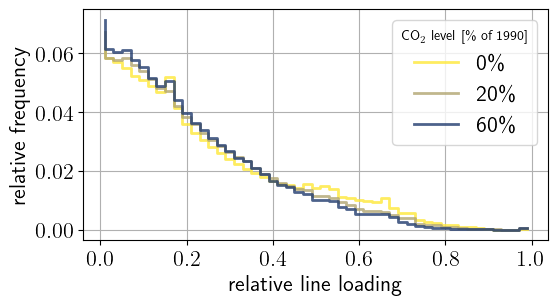

In [11]:
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

xpoints = (bins + bin_width/2)[:-1]

# co2lss = np.arange(0.0, 1.0, 0.05)

f, axs_probs = plt.subplots(figsize=(6, 3))

for count, co2l in enumerate(selected_co2ls):

    ind = np.where(np.round(co2ls, 2) == co2l)[0][0]

    axs_probs.step(xpoints,
            hist_vals[count]/np.sum(hist_vals[count]),
            label=r'{}\%'.format(int(100*co2l)),
            linewidth=2,
            color=cmap(ind/len(co2ls)),
            alpha=0.8)
axs_probs.legend(fontsize=16, title='CO$_2$ level [\% of 1990]')
#width = (bins[1]-bins[0])/2,
# label = 'data')
# axs_probs.set_xlim([0, 0.8])
axs_probs.tick_params(axis='both', which='both', labelsize=16)
axs_probs.set_xlabel(r'relative line loading', fontsize=16)
axs_probs.set_ylabel(r'relative frequency', fontsize=16)
axs_probs.grid(True)
# ax.set_yscale('log')
# ax.set_ylim([4e-3,1e-1])
# plt.savefig(save_path+'line_loadings_versus_CO2.pdf',bbox_inches = 'tight')

plt.show()


## total flow

In [24]:
# calculate line flows
cmap = plt.get_cmap('cividis_r')

unit_factor = 1e6

# bins = np.arange(0, 1.0, 0.02)


hist_vals = np.zeros((len(selected_co2ls), len(bins)-1))



flows_lvls = []
for count, co2l in enumerate(selected_co2ls):

   
    n = networks[co2l]

    indices = nx.get_edge_attributes(nx_graph, 'line_index')

    # flows = n.lines_t.p0.abs().sum(axis=1)
    # distances = n.lines.length
    flow_distance = n.lines_t.p0.abs().mul(network.lines.length)
    # flows.hist(ax=axs_probs, bins=10, alpha=0.5, color=cmap(ind/len(co2ls), 0.8), label=r'{}\%'.format(int(100*co2l)))
    flows_lvls.append(flow_distance.sum(axis=1))

bins=np.histogram(np.hstack(flows_lvls)/unit_factor, bins=40)[1]

total power flow distance

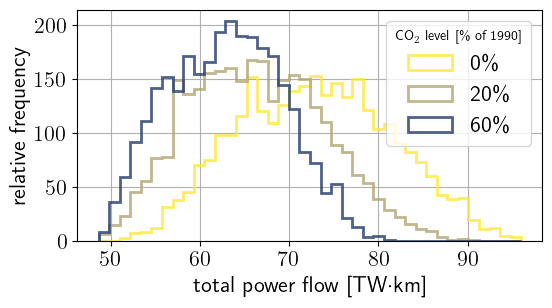

In [25]:

mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

f, axs_probs = plt.subplots(figsize=(6, 3))

for count, co2l in enumerate(selected_co2ls):

    ind = np.where(np.round(co2ls, 2) == co2l)[0][0]

    axs_probs.hist(flows_lvls[count]/unit_factor, bins=bins,
            histtype='step',
            label=r'{}\%'.format(int(100*co2l)),
            linewidth=2,
            color=cmap(ind/len(co2ls)),
            alpha=0.8)
    
axs_probs.legend(fontsize=16, title='CO$_2$ level [\% of 1990]')
axs_probs.tick_params(axis='both', which='both', labelsize=16)
axs_probs.set_xlabel(r'total power flow [TW$\cdot$km]', fontsize=16)
axs_probs.set_ylabel(r'relative frequency', fontsize=16)
axs_probs.grid(True)
plt.savefig(save_path+'total_flow_versus_CO2.pdf',bbox_inches = 'tight')

plt.show()

## max vs total load

In [14]:
nodes, line = list(indices.items())[0]
np.abs(network.lines_t.p0.T.loc[line[0]].values/line_limits_dict[nodes]).shape

(2920,)

In [15]:
# calculate line flows
cmap = plt.get_cmap('cividis_r')


# bins = np.arange(0, 2.0, 0.02)
bin_width = 0.02
bins = np.arange(0, 1.02, bin_width)

d = {}
hist_vals = np.zeros((len(selected_co2ls), len(bins)-1))


for count, co2l in enumerate(selected_co2ls):

    network = data_handling.load_pypsa_network_from_path(path_to_pypsa_network_sclopf +
                        f"sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{co2l}-2920SEG.nc", True)

    indices = nx.get_edge_attributes(nx_graph, 'line_index')
    line_limits_dict = nx.get_edge_attributes(nx_graph, 's_nom')

    # line[0] because line is saved as list of length 1
    loadings = np.array([np.abs(network.lines_t.p0.T.loc[line[0]].values/line_limits_dict[nodes]) for nodes, line in indices.items()])
    max_load = loadings.max(axis=0)
    total_load = loadings.sum(axis=0)
    d[co2l] = pd.DataFrame({"max_loadings":max_load, "total_load":total_load})

/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.2-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.2-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


/srv/data/jlange/power-system-split/no_extensions//data/European_networks_sclopf/sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc


INFO:pypsa.io:Imported network sclopf-elec_s_600_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


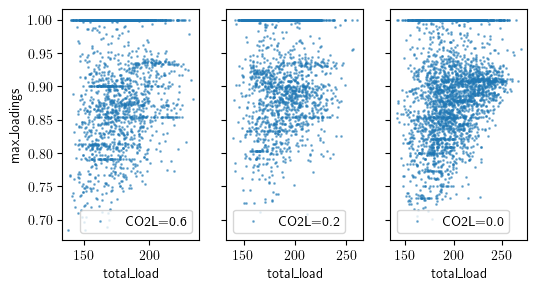

In [16]:
f, axs = plt.subplots(figsize=(6, 3), nrows=1, ncols=len(selected_co2ls), sharey=True)
for co2l, ax in zip(sorted(selected_co2ls, reverse=True), axs):
    d[co2l].plot(kind="scatter", y='max_loadings', x='total_load', ax=ax, s=1,
            # color=cmap(np.where(co2ls == co2l)[0][0]/len(co2ls)),
            label=f'CO2L={co2l}', alpha=0.5)

/tmp/ipykernel_1122490/3895027944.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("magma_r"))
/tmp/ipykernel_1122490/3895027944.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


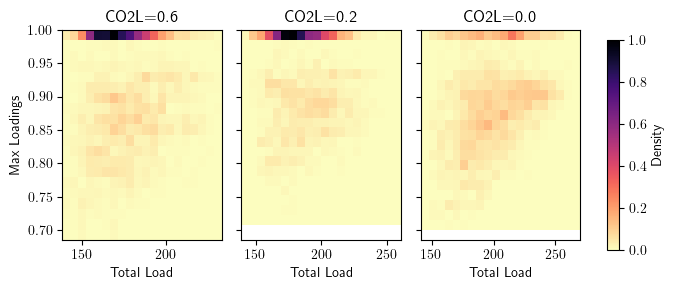

In [17]:
f, axs = plt.subplots(figsize=(6, 3), nrows=1, ncols=len(selected_co2ls), sharey=True)
norm = plt.Normalize(vmin=0, vmax=1)  # Normalize color scale
cmap = copy.copy(mpl.cm.get_cmap("magma_r"))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cmap.set_under("gainsboro", 0)

for co2l, ax in zip(selected_co2ls, axs[::-1]):
    h = ax.hist2d(x=d[co2l].total_load, y=d[co2l].max_loadings, bins=20, cmap=cmap, norm=norm, density=True)
    ax.set_title(f'CO2L={co2l}')
    ax.set_xlabel('Total Load')
    if ax == axs[0]:
        ax.set_ylabel('Max Loadings')

# Add shared colorbar to the right of the figure
cax = f.add_axes([1.02, 0.15, 0.02, 0.7])  # Adjust position and size
cbar = f.colorbar(sm, ax=axs, orientation='vertical', shrink=0.8, pad=0.02, cax=cax)
cbar.set_label('Density')

plt.tight_layout()


# storage time

In [18]:
types = ["discharging", "start_of_streak", "streak_id"]
n = networks[0.0]
multi_index = pd.MultiIndex.from_product([n.storage_units_t.p.columns,types], names=('units', "storage_state"))
df = pd.DataFrame(index=n.snapshots, columns=multi_index)

idx = pd.IndexSlice
df.loc[idx[:, idx[:,"discharging"]]]= (n.storage_units_t.p<0).values
df.loc[idx[:, idx[:,"start_of_streak"]]] = df.loc[idx[:, idx[:,"discharging"]]].ne(df.loc[idx[:, idx[:,"discharging"]]].shift()).values
df.loc[idx[:, idx[:,"streak_id"]]] = df.loc[idx[:, idx[:,"start_of_streak"]]].cumsum().values

In [19]:
df_streak_id = df.loc[idx[:, idx[:,"streak_id"]]].copy()
df_streak_id.columns = df_streak_id.columns.droplevel(level=1)
id_counts = df_streak_id.apply(lambda x: x.value_counts())
storage_type_list = [col.split(" ")[-1] for col in df_streak_id.columns]
streak_lenghts = id_counts.groupby(storage_type_list, axis=1).sum()

In [20]:
for target_level in selected_co2ls:
    n = networks[target_level].copy()
    discharging_ratios.columns = discharging_ratios.columns.droplevel(level=1)
    state_counts = discharging_ratios.apply(lambda x: x.value_counts())
    storage_type_list = [col.split(" ")[-1] for col in discharging_ratios.columns]
    discharging_ratios_types = discharging_ratios.groupby(storage_type_list, axis=1).mean().mean(axis=0)
    print(f"co2 lvl: {target_level}")
    print(discharging_ratios_types)

NameError: name 'discharging_ratios' is not defined

array([[<Axes: title={'center': 'H2'}>, <Axes: title={'center': 'PHS'}>],
       [<Axes: title={'center': 'battery'}>,
        <Axes: title={'center': 'hydro'}>]], dtype=object)

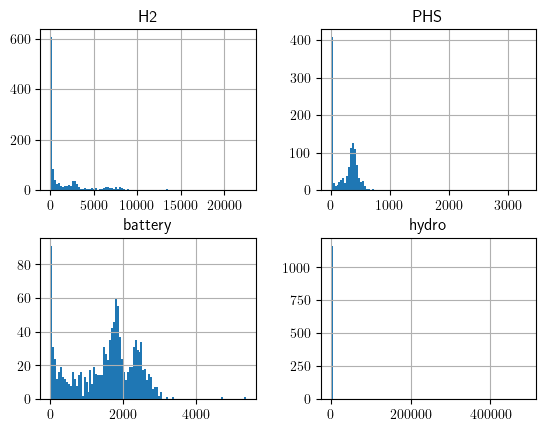

In [21]:
streak_lenghts.hist(bins=100)

In [22]:
# calculate line flows
cmap = plt.get_cmap('cividis_r')


bins = np.arange(0, 1.0, 0.02)


hist_vals = np.zeros((len(selected_co2ls), len(bins)-1))


storga_times_lvl = []
for count, co2l in enumerate(selected_co2ls):

   
    n = networks[co2l]

    indices = nx.get_edge_attributes(nx_graph, 'line_index')
    line_limits_dict = nx.get_edge_attributes(nx_graph, 's_nom')

    flows = n.lines_t.p0.abs().sum(axis=1)
    # flows.hist(ax=axs_probs, bins=10, alpha=0.5, color=cmap(ind/len(co2ls), 0.8), label=r'{}\%'.format(int(100*co2l)))
    storga_times_lvl.append(flows)

bins=np.histogram(np.hstack(storga_times_lvl), bins=40)[1]

# Figure 8 - Mitigation Inertia

In [6]:
from utils.plot_mitigation_strategies import plot_map_inertia_placement_final, calc_inertia_placement_ref_loss, color1, color2

# n_nodes = 400
# resolve_strategy = "random"
# delta_rot = 5000
# # for co2_lvl in [0.0 0.1, 0.2, 0.3, 0.4, 0.5]:
# for co2_lvl in [0.1]:
#     print(f"Running for co2_lvl: {co2_lvl}")
#     plot_map_inertia_placement_final(
#         co2_lvl,
#         nn=400,
#         max_iter=10000,
#         max_node_size=800,
#         edge_width=0.2,
#         delta_Erot=delta_rot,
#         resolve_strategy=resolve_strategy,
#         save_fig=True,
#     )

In [9]:
total_loss_share_rocof_lvl - np.cumsum(inertia_placed_res_arr[:, 3])

NameError: name 'total_loss_share_rocof_lvl' is not defined

In [7]:
co2_lvl_ref = 0.6
inertia_needed_by_lvl = {}
ref_loss_factors = (1,2)
for ref_loss_factor in ref_loss_factors:
    inertia_at_ref_loss_by_lvl = calc_inertia_placement_ref_loss(n_nodes=600,     delta_Erot=1000, co2_lvl_ref=co2_lvl_ref, ref_loss_factor=ref_loss_factor, co2_lvls=co2ls)
    inertia_needed_by_lvl[ref_loss_factor] = inertia_at_ref_loss_by_lvl

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
# f.tight_layout()
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

colors = color1, color2
labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']

co2_lvl_map = 0.1

f = plt.figure(figsize=(12, 7.5))
gs = GridSpec(2, 1, figure=f, height_ratios=[1, 1.5])
gs_lines = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0], wspace=0.4)
gs_maps = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1], wspace=0.1)
ax_loss_reduction = f.add_subplot(gs_lines[0])
ax_inertia_needed = f.add_subplot(gs_lines[1])
axs_maps = [f.add_subplot(gs_maps[i]) for i in range(2)]

unit = "GWs"
if unit == "GWs":
    unit_factor = 1e-3
elif unit == "MWs":
    unit_factor = 1
else:
    raise ValueError(f"Unit '{unit}' not known!")

# inertia needed by lvl
for i,ref_loss_factor in enumerate(ref_loss_factors):
    inertia_at_ref_loss_by_lvl = inertia_needed_by_lvl[ref_loss_factor] 
    label = "$R_{\\textrm{mit}}=ref_loss_factor R_{\\textrm{co2refString}}$"
    # label = label.replace("co2string", str(int(100 * co2_lvl_map)) + "\%")
    label = label.replace("co2refString", str(int(100 * co2_lvl_ref)) + "\%")
    if ref_loss_factor != 1:
        label = label.replace("ref_loss_factor", str(ref_loss_factor)+"\cdot")
    else:
        label = label.replace("ref_loss_factor", "")
    # label = label.replace("ref_loss_factor", str(ref_loss_factor))
    ax_inertia_needed.plot(np.array(list(inertia_at_ref_loss_by_lvl.keys()))*100, np.array(list(inertia_at_ref_loss_by_lvl.values()))*unit_factor, label=label, color=colors[i])
    
# ax_inertia_needed.plot(np.array(co2ls) * 100, np.array(inertia_at_ref_loss_by_lvl) *unit_factor)
# invert x axis
ax_inertia_needed.legend(title="Reference loss factor")
# plt.legend(title="$\\Delta E_0 [MWhs]$")
ax_inertia_needed.set_ylabel(f"Inertia placed [{unit}]")
ax_inertia_needed.set_xlabel("CO2 level [\% of 1990]")
ticks = np.array(list(inertia_at_ref_loss_by_lvl.keys()))*100
ax_inertia_needed.set_xticks(ticks, labels=[str(int(i)) for i in ticks])
if ticks[0]<ticks[-1]:
    ax_inertia_needed.invert_xaxis()
ax_inertia_needed.grid(True)
for i, ref_loss_factor in enumerate(ref_loss_factors):
    plot_curve = i==0
    plot_map_inertia_placement_final(
        axes=(axs_maps[1-i], ax_loss_reduction),
        co2_lvl = co2_lvl_map,
        nn=400,
        max_iter=10000,
        max_node_size=None,
        edge_width=0.2,
        delta_Erot=5000,
        rocof_thres=-1,
        l_share=0.0,
        resolve_strategy="random",
        show_step_number = False,
        plot_split_number = False,
        save_fig=False,
        co2_lvl_ref = co2_lvl_ref,
        ref_loss_factor=ref_loss_factors[i],
        unit = unit,
        color=colors[i],
        plot_curve=plot_curve
        )
    
ax_loss_reduction.set_xlim(0, inertia_needed_by_lvl[1][co2_lvl_map]*unit_factor*1.2)

f.tight_layout()
for ax, label in zip([ax_loss_reduction, ax_inertia_needed], labels):
    ax.text(0 - 0.2, 1+0.2,
            label,
            fontsize=36,
            weight='bold',
            verticalalignment='center',
            transform=ax.transAxes)
axs_maps[0].text(0 - 0.13, 1,
            labels[2],
            fontsize=36,
            weight='bold',
            verticalalignment='center',
            transform=axs_maps[0].transAxes)
axs_maps[1].text(0 - 0.05, 1,
            labels[3],
            fontsize=36,
            weight='bold',
            verticalalignment='center',
            transform=axs_maps[1].transAxes)

# for i,ax in enumerate(axs_maps):
#     ax.title("Synthetic inertia placement")

# axs_maps[0].text(0.2, 1+0.06,
#         r'\textbf{a}',
#         fontsize=36,
#         weight='bold',
#         verticalalignment='center',
#         transform=axs_maps[0].transAxes)
# axs_maps[0].text(1 , 1+0.06,
#         r'\textbf{b}',
#         fontsize=36,
#         weight='bold',
#         verticalalignment='center',
#         transform=axs_maps[0].transAxes
#         )
# ax_map.text(1 , 0.5,
#         r'\textbf{c}',
#         fontsize=36,
#         weight='bold',
#         verticalalignment='center',
#         transform=ax_map.transAxes
#         )
    

f.savefig(save_path+f'syn_inertia_mitigation_{co2_lvl_map}.pdf',bbox_inches = 'tight')

# line extension mitigation

## inspecting induced loss by trigger line

In [28]:
co2_mitigation = 0.1
split_properties.lost_load_share_blackout = split_properties.lost_load_share_blackout.astype(float)
split_properties["co2l"] = split_properties.index.get_level_values("co2l")
split_properties_mitigation = split_properties[split_properties.co2l == co2_mitigation].copy()

trigger0 = split_properties_mitigation.loc[:,["lost_load_share_blackout","init_failure_0"],].groupby("init_failure_0").sum()
trigger1 = split_properties_mitigation.loc[:,["lost_load_share_blackout","init_failure_1"],].groupby("init_failure_1").sum()
trigger1.rename_axis("trigger", inplace=True)
trigger0.rename_axis("trigger", inplace=True)
loss_by_trigger = pd.Series(index=list(range(n_lines)), data=0)
loss_by_trigger.rename_axis("trigger", inplace=True)


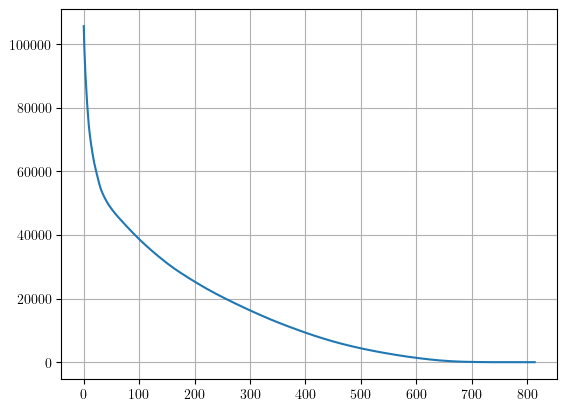

In [29]:
loss_by_trigger = loss_by_trigger.add(trigger0.lost_load_share_blackout, fill_value=0)
loss_by_trigger = loss_by_trigger.add(trigger1.lost_load_share_blackout, fill_value=0)

loss_by_trigger_sorted = loss_by_trigger.sort_values()
loss_curve = loss_by_trigger_sorted.cumsum()
plt.plot(np.arange(len(loss_curve)),loss_curve.values[::-1])
plt.grid()

## mitigation

In [30]:
mitigated_loss_selected[reinforced_lines_selected] = mitigated_loss[:num_lines_to_reach_ref_loss]/lost_load_reference_lvl


NameError: name 'mitigated_loss' is not defined

/tmp/ipykernel_1122490/679201450.py:111: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
/tmp/ipykernel_1122490/679201450.py:111: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))


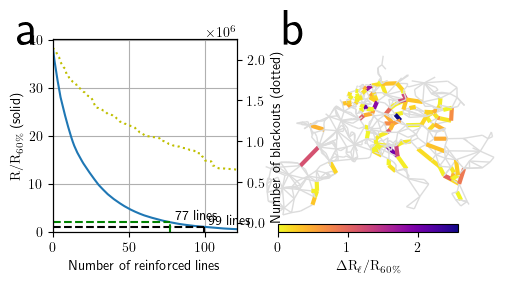

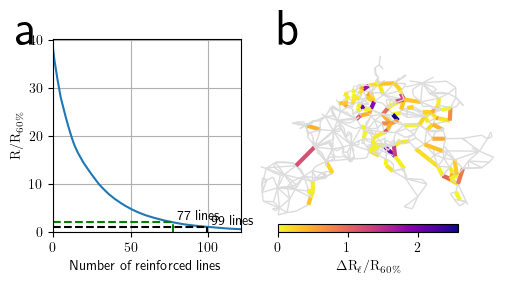

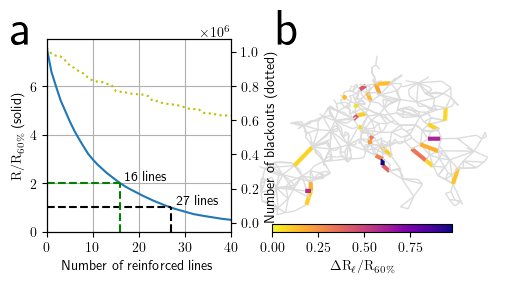

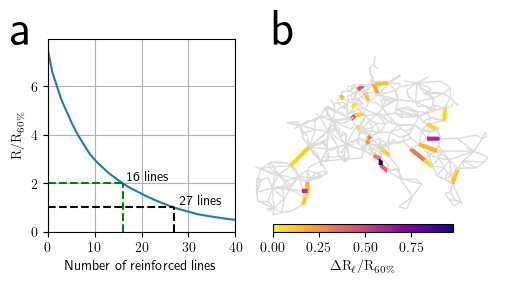

In [31]:
from utils.config import path_to_line_extension_mitigation_sclopf

co2l_ref=0.6

split_properties_reference = split_properties[split_properties.co2l == co2l_ref].copy()

lost_load_reference_lvl = split_properties_reference.lost_load_share_blackout.sum()

for co2l in [0.0, 0.1]:
    try:
        reinforced_lines, loss_with_mitigation, num_blackouts = pickle.load(open(path_to_line_extension_mitigation_sclopf + f"heuristic_loss_mitigation_Co2L{co2l}_n{n_nodes}.pkl", "rb"))
    except FileNotFoundError:
        split_significance = pd.read_csv(path_to_vis_results_sclopf + f"split_properties_Co2L{co2l}_n{n_nodes}.csv", index_col=0)
        remaining_splits = split_significance[split_significance.lost_load_share_blackout>0]
        remaining_splits = remaining_splits.loc[:, ["lost_load_share_blackout","init_failure_0", "init_failure_1"]]

        loss_with_mitigation = [split_significance.lost_load_share_blackout.sum()]
        reinforced_lines = []
        num_blackouts = [remaining_splits.shape[0]]

        while remaining_splits.shape[0]>0:
            trigger0 = remaining_splits.loc[:,["lost_load_share_blackout","init_failure_0"],].groupby("init_failure_0").sum()
            trigger1 = remaining_splits.loc[:,["lost_load_share_blackout","init_failure_1"],].groupby("init_failure_1").sum()
            trigger1.rename_axis("trigger", inplace=True)
            trigger0.rename_axis("trigger", inplace=True)
            loss_by_trigger = pd.Series(index=list(range(n_lines)), data=0)
            loss_by_trigger.rename_axis("trigger", inplace=True)
            loss_by_trigger = loss_by_trigger.add(trigger0.lost_load_share_blackout, fill_value=0)
            loss_by_trigger = loss_by_trigger.add(trigger1.lost_load_share_blackout, fill_value=0)

            trigger = loss_by_trigger.idxmax()
            remaining_splits = remaining_splits[(remaining_splits.init_failure_1!=trigger) & (remaining_splits.init_failure_0!=trigger)]
            loss_with_mitigation.append(remaining_splits.lost_load_share_blackout.sum())
            reinforced_lines.append(trigger)
            num_blackouts.append(remaining_splits.shape[0])

        with open(path_to_line_extension_mitigation_sclopf + f"heuristic_loss_mitigation_Co2L{co2l}_n{n_nodes}.pkl", "wb") as f:
            pickle.dump((reinforced_lines, loss_with_mitigation, num_blackouts), f)
            

    # use latex
    mpl.style.use('default')
    plt.rc('text', usetex=True)
    plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

    for plot_blackout_number in [True, False]:

        num_lines_to_reach_ref_loss = np.where(loss_with_mitigation < lost_load_reference_lvl)[0][0]
        num_lines_to_reach_double_ref_loss = np.where(loss_with_mitigation < 2*lost_load_reference_lvl)[0][0]

        # fig, (ax, ax_map) = plt.subplots(1,2, figsize=(12,5))
        fig = plt.figure(figsize=(6,2.5))
        
        # gs = GridSpec(1, 2, figure=f)
        if plot_blackout_number:
            wspace=0.02
        else:
            wspace=-0.02
        gs = GridSpec(1, 2, figure=f, width_ratios=[1.2,1.8], wspace=wspace)
        ax = fig.add_subplot(gs[0])
        ax_map = fig.add_subplot(gs[1])

        ax.plot(np.arange(len(loss_with_mitigation)),np.array(loss_with_mitigation)/lost_load_reference_lvl)

        if plot_blackout_number:
            # add second y axis
            ax2 = ax.twinx()
            ax2.plot(np.arange(len(num_blackouts)),num_blackouts, color='y', linestyle='dotted')
            ax2.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
            ax2.set_ylabel('Number of blackouts (dotted)')

        right_xlim = np.where(loss_with_mitigation/lost_load_reference_lvl < 0.5)[0][0]
        ax.plot([0, num_lines_to_reach_ref_loss], [1,1], '--', c='k')
        ax.plot([num_lines_to_reach_ref_loss, num_lines_to_reach_ref_loss], [0,1], '--', c='k')
        ax.text(num_lines_to_reach_ref_loss + right_xlim/200*5, 1, f"{num_lines_to_reach_ref_loss} lines", verticalalignment='bottom', horizontalalignment='left', zorder=np.inf)
        ax.plot([0, num_lines_to_reach_double_ref_loss], [2,2], '--', c='g')
        ax.plot([num_lines_to_reach_double_ref_loss, num_lines_to_reach_double_ref_loss], [0,2], '--', c='g')
        ax.text(num_lines_to_reach_double_ref_loss + right_xlim/200*5, 2, f"{num_lines_to_reach_double_ref_loss} lines", verticalalignment='bottom', horizontalalignment='left', zorder=np.inf)
        ax.set_xlim(0,right_xlim)
        ax.set_ylim(bottom=00)

        ax.set_xlabel('Number of reinforced lines')
        # y_label = "$L_{\\textrm{co2string,mit}}/L_{\\textrm{co2refString}}$"
        # y_label = y_label.replace("co2string", str(int(100 * co2l)) + "\%")
        # y_label = y_label.replace("co2refString", str(int(100 * co2l_ref)) + "\%")
        y_label = "$\\textrm{R}/\\textrm{R}_{\\textrm{co2refString}}$"
        y_label = y_label.replace("co2string", str(int(100 * co2l)) + "\%")
        y_label = y_label.replace("co2refString", str(int(100 * co2l_ref)) + "\%")
        if plot_blackout_number:
            y_label += " (solid)"
        ax.set_ylabel(y_label)
        ax.grid()

        fname = "loss_reduction_"
        if plot_blackout_number:
            fname += "blackouts_"
        fname += f"vs_reinforced_lines_CO2{co2l}.pdf"

        reinforced_lines_selected = np.array(reinforced_lines[:num_lines_to_reach_ref_loss]).astype(int)
        lines_not_extended = np.setdiff1d(np.arange(n_lines), reinforced_lines_selected)
        reinforced_lines_full = list(reinforced_lines_selected) + list(lines_not_extended)
        mitigated_loss = np.array([loss_with_mitigation[i] - loss_with_mitigation[i+1] for i in range(len(loss_with_mitigation)-1)])
        mitigated_loss = np.concatenate((mitigated_loss,-np.ones(n_lines - len(mitigated_loss))))
        mitigated_loss_sorted = mitigated_loss[np.argsort(reinforced_lines_full)]
        mitigated_loss_selected = -np.ones(n_lines)
        mitigated_loss_selected[reinforced_lines_selected] = mitigated_loss[:num_lines_to_reach_ref_loss]/lost_load_reference_lvl

        width= 2*(mitigated_loss_selected>0).astype(int) + 1
        # cmap = "cividis_r"
        # cmap = plt.get_cmap('cividis_r')
        cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
        cmap.set_under('gainsboro', 1.0)

        nodes = nx.draw_networkx_nodes(nx_graph,
                                    pos=pos,
                                    ax=ax_map,
                                    node_color='black',
                                    node_size=0)

        edges = nx.draw_networkx_edges(nx_graph,
                                    pos=pos,
                                    ax=ax_map,
                                    # edge_color=mitigated_loss_selected/mitigated_loss_selected.max(),
                                    edge_color=mitigated_loss_selected,
                                    width=width,
                                    edge_cmap=cmap,
                                    edge_vmin=0,
                                    # edge_vmax=np.log10(vmax)
                                    )
        ax_map_legend = fig.add_axes([0.5, 0.11, 0.3, 0.03])
        # plt.colorbar(edges, ax=ax_map, cax=ax_map_legend, label='Normalized mitigated loss [a.u.]', shrink=0.5, orientation="horizontal")
        y_label = "$\Delta \\textrm{R}_{{\\ell}}/\\textrm{R}_{\\textrm{co2refString}}$"
        y_label = y_label.replace("co2string", str(int(100 * co2l)) + "\%")
        y_label = y_label.replace("co2refString", str(int(100 * co2l_ref)) + "\%")
        plt.colorbar(edges, ax=ax_map, cax=ax_map_legend, label=y_label, shrink=0.5, orientation="horizontal")
        ax_map.axis("off")

        ax.text(0 - 0.2, 1+0.04,
                "a",
                fontsize=36,
                weight='bold',
                verticalalignment='center',
                transform=ax.transAxes)

        ax_map.text(0 + 0.15, 1+0.04,
                "b",
                fontsize=36,
                weight='bold',
                verticalalignment='center',
                transform=ax_map.transAxes)

# plt.savefig(save_path+fname, bbox_inches='tight', dpi=200)

/tmp/ipykernel_1122490/2050851020.py:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
/tmp/ipykernel_1122490/2050851020.py:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))


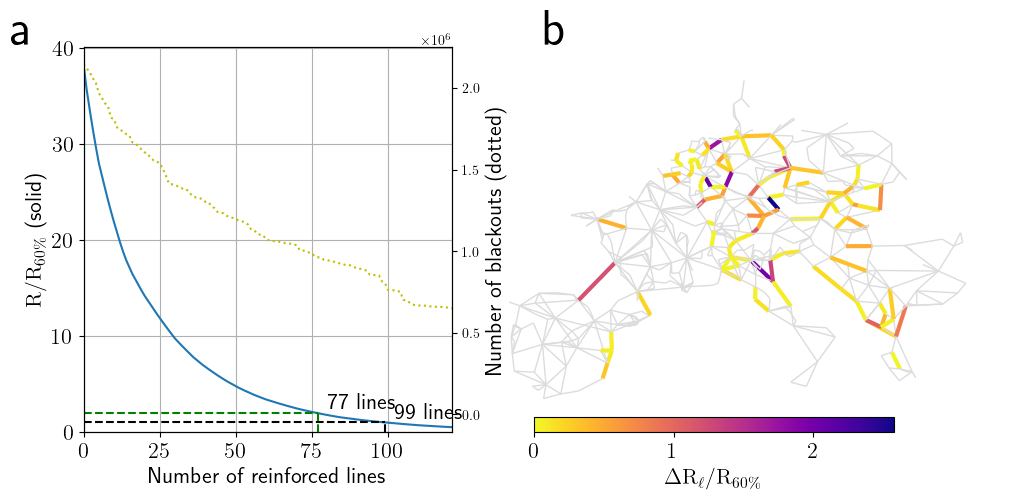

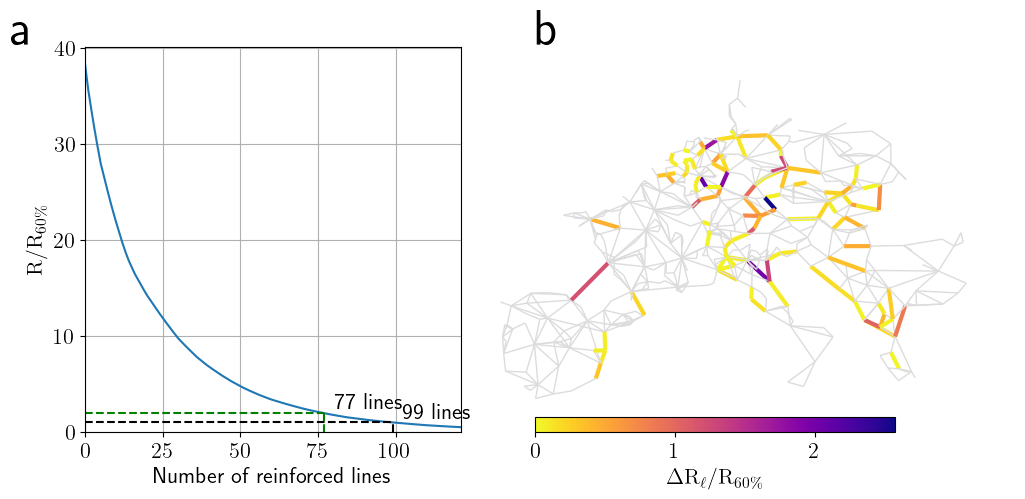

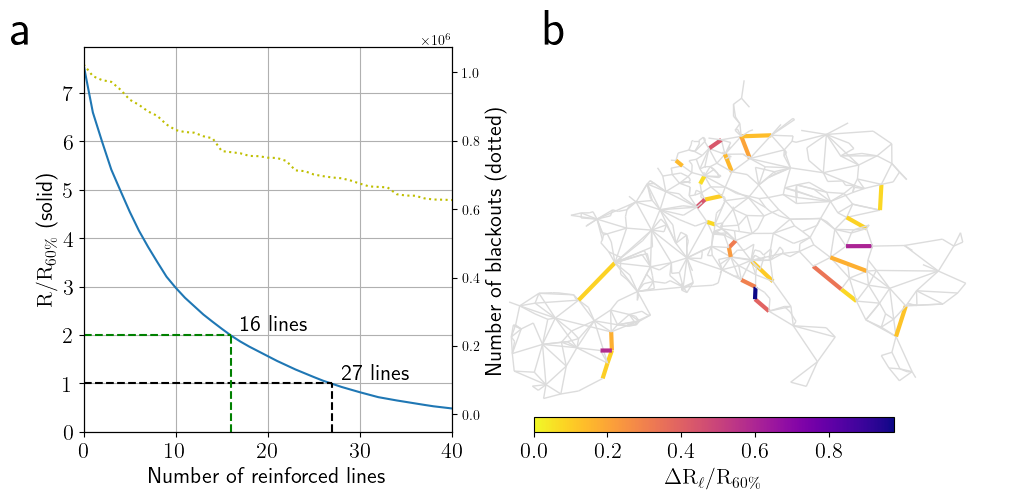

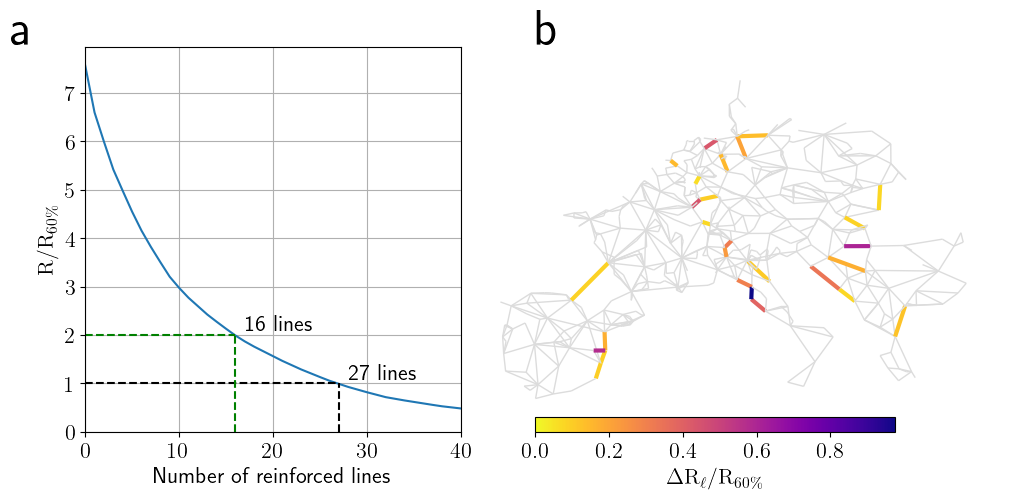

In [33]:
from utils.config import path_to_line_extension_mitigation_sclopf

co2l_ref=0.6
split_properties_reference = split_properties[split_properties.co2l == co2l_ref].copy()
lost_load_reference_lvl = split_properties_reference.lost_load_share_blackout.sum()

for co2l in [0.0, 0.1]:
    try:
        reinforced_lines, loss_with_mitigation, num_blackouts = pickle.load(open(path_to_line_extension_mitigation_sclopf + f"heuristic_loss_mitigation_Co2L{co2l}_n{n_nodes}.pkl", "rb"))
    except FileNotFoundError:
        split_significance = pd.read_csv(path_to_evaluation_results_sclopf + f"split_properties_Co2L{co2l}_n{n_nodes}.csv", index_col=0)
        remaining_splits = split_significance[split_significance.lost_load_share_blackout>0]
        remaining_splits = remaining_splits.loc[:, ["lost_load_share_blackout","init_failure_0", "init_failure_1"]]

        loss_with_mitigation = [split_significance.lost_load_share_blackout.sum()]
        reinforced_lines = []
        num_blackouts = [remaining_splits.shape[0]]

        while remaining_splits.shape[0]>0:
            trigger0 = remaining_splits.loc[:,["lost_load_share_blackout","init_failure_0"],].groupby("init_failure_0").sum()
            trigger1 = remaining_splits.loc[:,["lost_load_share_blackout","init_failure_1"],].groupby("init_failure_1").sum()
            trigger1.rename_axis("trigger", inplace=True)
            trigger0.rename_axis("trigger", inplace=True)
            loss_by_trigger = pd.Series(index=list(range(n_lines)), data=0)
            loss_by_trigger.rename_axis("trigger", inplace=True)
            loss_by_trigger = loss_by_trigger.add(trigger0.lost_load_share_blackout, fill_value=0)
            loss_by_trigger = loss_by_trigger.add(trigger1.lost_load_share_blackout, fill_value=0)

            trigger = loss_by_trigger.idxmax()
            remaining_splits = remaining_splits[(remaining_splits.init_failure_1!=trigger) & (remaining_splits.init_failure_0!=trigger)]
            loss_with_mitigation.append(remaining_splits.lost_load_share_blackout.sum())
            reinforced_lines.append(trigger)
            num_blackouts.append(remaining_splits.shape[0])

        with open(path_to_line_extension_mitigation_sclopf + f"heuristic_loss_mitigation_Co2L{co2l}_n{n_nodes}.pkl", "wb") as f:
            pickle.dump((reinforced_lines, loss_with_mitigation, num_blackouts), f)

    # use latexreinforced_lines_selected = np.array(reinforced_lines[:num_lines_to_reach_ref_loss]).astype(int)
        lines_not_extended = np.setdiff1d(np.arange(n_lines), reinforced_lines_selected)
        reinforced_lines_full = list(reinforced_lines_selected) + list(lines_not_extended)

    mpl.style.use('default')
    plt.rc('text', usetex=True)
    plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

    for plot_blackout_number in [True, False]:

        num_lines_to_reach_ref_loss = np.where(loss_with_mitigation < lost_load_reference_lvl)[0][0]
        num_lines_to_reach_double_ref_loss = np.where(loss_with_mitigation < 2*lost_load_reference_lvl)[0][0]

        # fig, (ax, ax_map) = plt.subplots(1,2, figsize=(12,5))
        fig = plt.figure(figsize=(12,5))
        
        # gs = GridSpec(1, 2, figure=f)
        if plot_blackout_number:
            wspace=0.02
        else:
            wspace=-0.02
        gs = GridSpec(1, 2, figure=f, width_ratios=[1.2,1.8], wspace=wspace)
        ax = fig.add_subplot(gs[0])
        ax_map = fig.add_subplot(gs[1])
        
        ax.plot(np.arange(len(loss_with_mitigation)),np.array(loss_with_mitigation)/lost_load_reference_lvl)

        if plot_blackout_number:
            # add second y axis
            ax2 = ax.twinx()
            ax2.plot(np.arange(len(num_blackouts)),num_blackouts, color='y', linestyle='dotted')
            ax2.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
            ax2.set_ylabel('Number of blackouts (dotted)', fontsize=16)
        
        right_xlim = np.where(loss_with_mitigation/lost_load_reference_lvl < 0.5)[0][0]
        ax.plot([0, num_lines_to_reach_ref_loss], [1,1], '--', c='k')
        ax.plot([num_lines_to_reach_ref_loss, num_lines_to_reach_ref_loss], [0,1], '--', c='k')
        ax.text(num_lines_to_reach_ref_loss + right_xlim/200*5, 1, f"{num_lines_to_reach_ref_loss} lines", verticalalignment='bottom', horizontalalignment='left', zorder=np.inf, fontsize=16)
        ax.plot([0, num_lines_to_reach_double_ref_loss], [2,2], '--', c='g')
        ax.plot([num_lines_to_reach_double_ref_loss, num_lines_to_reach_double_ref_loss], [0,2], '--', c='g')
        ax.text(num_lines_to_reach_double_ref_loss + right_xlim/200*5, 2, f"{num_lines_to_reach_double_ref_loss} lines", verticalalignment='bottom', horizontalalignment='left', zorder=np.inf, fontsize=16)
        ax.set_xlim(0,right_xlim)
        ax.set_ylim(bottom=00)
        # increase tick fontsize
        ax.tick_params(axis='both', which='major', labelsize=16)
        
        ax.set_xlabel('Number of reinforced lines')
        y_label = "$\\textrm{R}/\\textrm{R}_{\\textrm{co2refString}}$"
        y_label = y_label.replace("co2string", str(int(100 * co2l)) + "\%")
        y_label = y_label.replace("co2refString", str(int(100 * co2l_ref)) + "\%")
        if plot_blackout_number:
            y_label += " (solid)"
        ax.set_ylabel(y_label, fontsize=16)
        ax.grid()
        # increase xlabel fontsize
        ax.xaxis.label.set_size(16)

        fname = "loss_reduction_"
        if plot_blackout_number:
            fname += "blackouts_"
        fname += f"vs_reinforced_lines_CO2{co2l}.pdf"
        
        reinforced_lines_selected = reinforced_lines[:num_lines_to_reach_ref_loss]
        lines_not_extended = np.setdiff1d(np.arange(n_lines), reinforced_lines_selected)
        reinforced_lines_full = reinforced_lines_selected + list(lines_not_extended)
        mitigated_loss = np.array([loss_with_mitigation[i] - loss_with_mitigation[i+1] for i in range(len(loss_with_mitigation)-1)])
        mitigated_loss = np.concatenate((mitigated_loss,-np.ones(n_lines - len(mitigated_loss))))
        mitigated_loss_sorted = mitigated_loss[np.argsort(reinforced_lines_full)]
        mitigated_loss_selected = -np.ones(n_lines)
        # Convert reinforced_lines_selected to integer indices
        reinforced_lines_selected_int = np.array(reinforced_lines_selected).astype(int)
        mitigated_loss_selected[reinforced_lines_selected_int] = mitigated_loss[:num_lines_to_reach_ref_loss]/lost_load_reference_lvl

        width= 2*(mitigated_loss_selected>0).astype(int) + 1
        # cmap = "cividis_r"
        # cmap = plt.get_cmap('cividis_r')
        cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
        cmap.set_under('gainsboro', 1.0)

        nodes = nx.draw_networkx_nodes(nx_graph,
                                    pos=pos,
                                    ax=ax_map,
                                    node_color='black',
                                    node_size=0)

        edges = nx.draw_networkx_edges(nx_graph,
                                    pos=pos,
                                    ax=ax_map,
                                    # edge_color=mitigated_loss_selected/mitigated_loss_selected.max(),
                                    edge_color=mitigated_loss_selected,
                                    width=width,
                                    edge_cmap=cmap,
                                    edge_vmin=0,
                                    # edge_vmax=np.log10(vmax)
                                    )
        ax_map_legend = fig.add_axes([0.5, 0.11, 0.3, 0.03])
        y_label = "$\Delta \\textrm{R}_{{\\ell}}/\\textrm{R}_{\\textrm{co2refString}}$"
        y_label = y_label.replace("co2string", str(int(100 * co2l)) + "\%")
        y_label = y_label.replace("co2refString", str(int(100 * co2l_ref)) + "\%")
        cbar = plt.colorbar(edges, ax=ax_map, cax=ax_map_legend, label=y_label, shrink=0.5, orientation="horizontal")
        # increase cbar fontsize
        cbar.ax.tick_params(labelsize=16)
        # increase cbar label fontsize
        cbar.ax.set_xlabel(y_label, fontsize=16)
        
        ax_map.axis("off")
        
        ax.text(0 - 0.2, 1+0.04,
                "a",
                fontsize=36,
                weight='bold',
                verticalalignment='center',
                transform=ax.transAxes)
        
        ax_map.text(0 + 0.15, 1+0.04,
                "b",
                fontsize=36,
                weight='bold',
                verticalalignment='center',
                transform=ax_map.transAxes)

        plt.savefig(save_path+fname, bbox_inches='tight')

## line extension order

In [ ]:
# fig, ax = plt.subplots()

# reinforced_lines_selected = reinforced_lines[:num_lines_to_reach_ref_loss]
# lines_not_extended = np.setdiff1d(np.arange(n_lines), reinforced_lines_selected)
# reinforced_lines_full = reinforced_lines_selected + list(lines_not_extended)
# mitigated_loss = np.array([loss_with_mitigation[i] - loss_with_mitigation[i+1] for i in range(len(loss_with_mitigation)-1)])
# mitigated_loss = np.concatenate((mitigated_loss,-np.ones(n_lines - len(mitigated_loss))))
# mitigated_loss_sorted = mitigated_loss[np.argsort(reinforced_lines_full)]
# mitigated_loss_selected = -np.ones(n_lines)
# mitigated_loss_selected[reinforced_lines_selected] = mitigated_loss[:num_lines_to_reach_ref_loss]

# width= 2*(mitigated_loss_selected>0).astype(int) + 1
# # cmap = "cividis_r"
# # cmap = plt.get_cmap('cividis_r')
# cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
# cmap.set_under('gainsboro', 1.0)

# nodes = nx.draw_networkx_nodes(nx_graph,
#                             pos=pos,
#                             ax=ax,
#                             node_color='black',
#                             node_size=0)

# edges = nx.draw_networkx_edges(nx_graph,
#                             pos=pos,
#                             ax=ax,
#                             edge_color=mitigated_loss_selected/mitigated_loss_selected.max(),
#                             width=width,
#                             edge_cmap=cmap,
#                             edge_vmin=0,
#                             # edge_vmax=np.log10(vmax)
#                             )

# plt.colorbar(edges, ax=ax, label='Normalized mitigated loss [a.u.]', shrink=0.5)
# plt.axis("off")